<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/electric_vehicle_resale/Hemlal_Dulal_dissertation_codebase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
GBP_TO_USD_RATE = 1.27
USD_TO_GBP_RATE = 1 / GBP_TO_USD_RATE

def convert_usd_to_gbp_and_rename_columns(df):
    usd_columns = [
        'Resale_Value_USD',
        'Maintenance_Cost_USD',
        'Insurance_Cost_USD',
        'Electricity_Cost_USD_per_kWh',
        'Monthly_Charging_Cost_USD'
    ]
    for col in usd_columns:
        if col in df.columns:
            df[col] = (df[col] * USD_TO_GBP_RATE).round(2)
            new_name = col.replace('_USD', '_GBP').replace('_USD_per_kWh', '_GBP_per_kWh')
            df.rename(columns={col: new_name}, inplace=True)
    return df

print(f"Exchange rate applied: 1 USD = #{USD_TO_GBP_RATE:.4f} GBP")

Exchange rate applied: 1 USD = #0.7874 GBP


In [2]:
print("https://www.kaggle.com/code/sumedh1507/electric-vehicle-resale-value-prediction")

https://www.kaggle.com/code/sumedh1507/electric-vehicle-resale-value-prediction


In [3]:
import os
import pandas as pd
import numpy as np

def try_mount_drive():
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        return True
    except Exception:
        return False

DATA_PATHS = [
    '/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv',
    '/content/electric_vehicle_analytics.csv',
    'electric_vehicle_analytics.csv',
]

df_raw = None
for path in DATA_PATHS:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break

if df_raw is None and try_mount_drive():
    for path in DATA_PATHS:
        if os.path.exists(path):
            df_raw = pd.read_csv(path)
            print(f"Loaded data from Drive: {path}")
            break

if df_raw is not None:
    df = convert_usd_to_gbp_and_rename_columns(df_raw.copy())
    display(df.head())
else:
    print("Dataset not found. Please upload the CSV.")

Mounted at /content/drive
Loaded data from Drive: /content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv


,Vehicle_ID,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_GBP,Insurance_Cost_GBP,Electricity_Cost_GBP_per_kWh,Monthly_Charging_Cost_GBP,Resale_Value_GBP
0,1,Mercedes,EQC,2022,North America,Sedan,44.0,74.7,183,217.9,...,237,11.4,-9,Occasional,1.15,1563.15,1609.21,0.17,12.66,9158.32
1,2,Volkswagen,ID.3,2024,Australia,Truck,117.6,77.0,502,158.4,...,180,9.1,-2,Long-range,3.28,98.58,2248.43,0.17,47.21,29497.61
2,3,Chevrolet,Bolt EV,2024,North America,SUV,91.6,83.2,399,128.8,...,183,7.9,43,Commuter,4.89,1529.30,1919.55,0.23,87.96,23820.24
3,4,Hyundai,Kona Electric,2022,Europe,Hatchback,76.9,98.8,502,189.4,...,170,5.7,34,Commuter,28.93,102.13,1227.17,0.14,317.76,10384.00
4,5,Kia,Niro EV,2017,North America,Truck,95.6,93.1,403,96.0,...,177,6.3,13,Commuter,23.71,1170.28,1648.73,0.22,511.93,8210.79


In [4]:
print('Data Preprocessing ')
import numpy as np
current_year = 2026
# Ensure we are working with the correct dataframe from previous steps
df['Vehicle_Age'] = current_year - df['Year']
df['Efficiency_km_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).replace([np.inf, -np.inf], 0).fillna(0)

missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col].fillna(mode_val[0], inplace=True)

print('Preprocessing complete.')
display(df[['Year', 'Vehicle_Age', 'Efficiency_km_per_kWh']].head())

Data Preprocessing 
Preprocessing complete.


,Year,Vehicle_Age,Efficiency_km_per_kWh
0,2022,4,4.159091
1,2024,2,4.268707
2,2024,2,4.355895
3,2022,4,6.527958
4,2017,9,4.215481


In [5]:
df=pd.read_csv('/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv')
df = convert_usd_to_gbp_and_rename_columns(df)
df

,Vehicle_ID,Make,Model,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_GBP,Insurance_Cost_GBP,Electricity_Cost_GBP_per_kWh,Monthly_Charging_Cost_GBP,Resale_Value_GBP
0,1,Mercedes,EQC,2022,North America,Sedan,44.0,74.7,183,217.9,...,237,11.4,-9,Occasional,1.15,1563.15,1609.21,0.17,12.66,9158.32
1,2,Volkswagen,ID.3,2024,Australia,Truck,117.6,77.0,502,158.4,...,180,9.1,-2,Long-range,3.28,98.58,2248.43,0.17,47.21,29497.61
2,3,Chevrolet,Bolt EV,2024,North America,SUV,91.6,83.2,399,128.8,...,183,7.9,43,Commuter,4.89,1529.30,1919.55,0.23,87.96,23820.24
3,4,Hyundai,Kona Electric,2022,Europe,Hatchback,76.9,98.8,502,189.4,...,170,5.7,34,Commuter,28.93,102.13,1227.17,0.14,317.76,10384.00
4,5,Kia,Niro EV,2017,North America,Truck,95.6,93.1,403,96.0,...,177,6.3,13,Commuter,23.71,1170.28,1648.73,0.22,511.93,8210.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Tesla,Model 3,2018,Australia,Sedan,87.0,89.9,542,89.9,...,210,8.1,34,Commuter,2.01,1049.27,513.31,0.17,33.69,13987.48
2996,2997,Tesla,Model S,2019,Asia,SUV,56.6,78.0,370,163.9,...,182,7.2,6,Commercial,20.20,153.50,1541.23,0.13,174.64,5502.17
2997,2998,BMW,i4,2021,North America,Hatchback,69.4,85.2,484,239.7,...,208,6.8,40,Commercial,3.05,809.27,2090.09,0.09,18.91,14125.57
2998,2999,BMW,iX,2021,Asia,Truck,84.9,75.2,565,148.0,...,192,9.9,9,Commuter,24.17,654.17,671.15,0.09,199.83,8872.66


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Make                              3000 non-null   object 
 2   Model                             3000 non-null   object 
 3   Year                              3000 non-null   int64  
 4   Region                            3000 non-null   object 
 5   Vehicle_Type                      3000 non-null   object 
 6   Battery_Capacity_kWh              3000 non-null   float64
 7   Battery_Health_%                  3000 non-null   float64
 8   Range_km                          3000 non-null   int64  
 9   Charging_Power_kW                 3000 non-null   float64
 10  Charging_Time_hr                  3000 non-null   float64
 11  Charge_Cycles                     3000 non-null   int64  
 12  Energy

In [7]:
df.columns

Index(['Vehicle_ID', 'Make', 'Model', 'Year', 'Region', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
       'Charging_Power_kW', 'Charging_Time_hr', 'Charge_Cycles',
       'Energy_Consumption_kWh_per_100km', 'Mileage_km', 'Avg_Speed_kmh',
       'Max_Speed_kmh', 'Acceleration_0_100_kmh_sec', 'Temperature_C',
       'Usage_Type', 'CO2_Saved_tons', 'Maintenance_Cost_GBP',
       'Insurance_Cost_GBP', 'Electricity_Cost_GBP_per_kWh',
       'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Vehicle_ID,0
Make,0
Model,0
Year,0
Region,0
Vehicle_Type,0
Battery_Capacity_kWh,0
Battery_Health_%,0
Range_km,0
Charging_Power_kW,0


Histogram: Distribution of EV Manufacturing Years
This shows the number of vehicles produced each year, helping us understand
EV adoption trends and market growth over time.



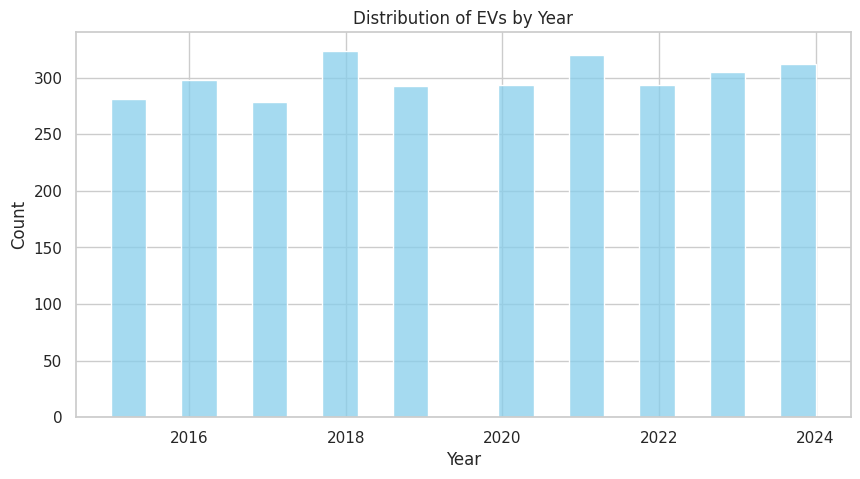

Histogram: Battery Capacity Distribution
This shows the distribution of EV battery capacities (kWh). It helps us
see whether most vehicles are equipped with small, medium, or large batteries.



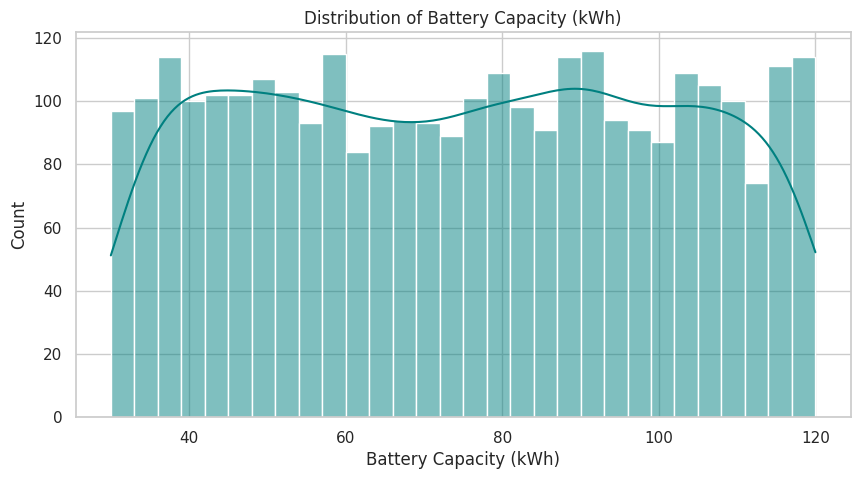

Histogram: Electric Range Distribution
This shows how far vehicles can travel on a single charge (km). It highlights
the most common ranges and the presence of short vs. long-range EVs.



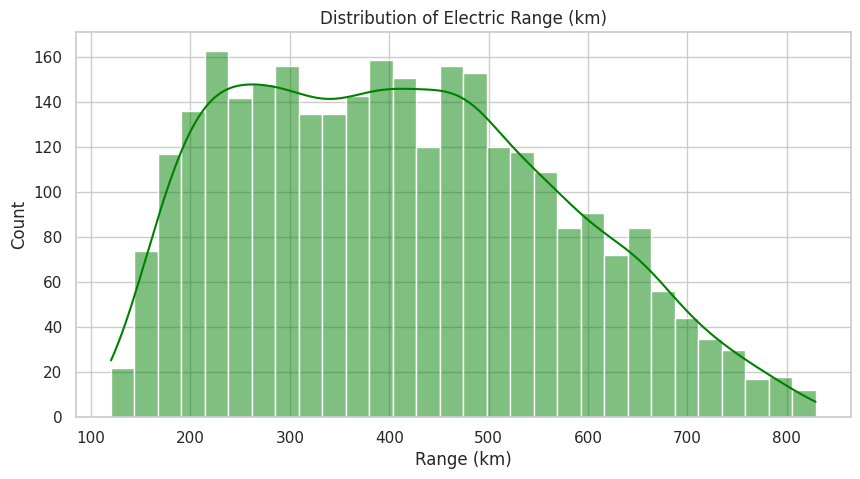

Histogram: Charging Time Distribution
This shows how long vehicles take to fully charge. It helps compare fast vs.
slow charging EVs.



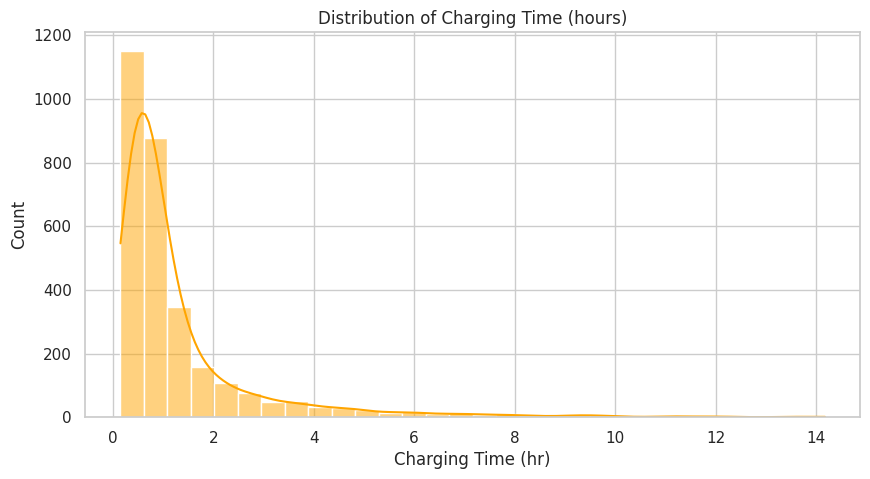

Histogram: Resale Value Distribution
This shows the resale value (GBP) distribution of EVs. It highlights affordability
and depreciation trends in the EV market.



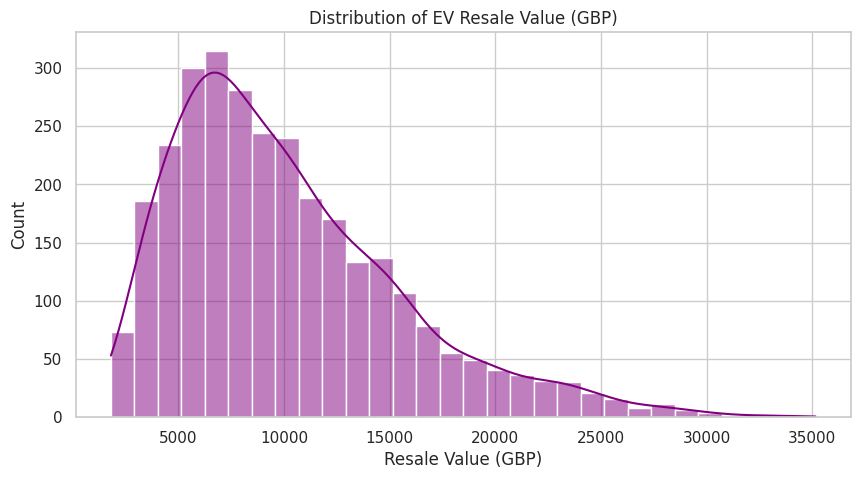

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean style
sns.set(style="whitegrid")

# HISTOGRAMS WITH DESCRIPTIONS

# 1. Distribution of EV Manufacturing Years
print("Histogram: Distribution of EV Manufacturing Years")
print("This shows the number of vehicles produced each year, helping us understand")
print("EV adoption trends and market growth over time.\n")

plt.figure(figsize=(10,5))
sns.histplot(df['Year'], bins=20, kde=False, color="skyblue")
plt.title("Distribution of EVs by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


# 2. Battery Capacity Distribution
print("Histogram: Battery Capacity Distribution")
print("This shows the distribution of EV battery capacities (kWh). It helps us")
print("see whether most vehicles are equipped with small, medium, or large batteries.\n")

plt.figure(figsize=(10,5))
sns.histplot(df['Battery_Capacity_kWh'], bins=30, kde=True, color="teal")
plt.title("Distribution of Battery Capacity (kWh)")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Count")
plt.show()


# 3. Electric Range Distribution
print("Histogram: Electric Range Distribution")
print("This shows how far vehicles can travel on a single charge (km). It highlights")
print("the most common ranges and the presence of short vs. long-range EVs.\n")

plt.figure(figsize=(10,5))
sns.histplot(df['Range_km'], bins=30, kde=True, color="green")
plt.title("Distribution of Electric Range (km)")
plt.xlabel("Range (km)")
plt.ylabel("Count")
plt.show()


# 4. Charging Time Distribution
print("Histogram: Charging Time Distribution")
print("This shows how long vehicles take to fully charge. It helps compare fast vs.")
print("slow charging EVs.\n")

plt.figure(figsize=(10,5))
sns.histplot(df['Charging_Time_hr'], bins=30, kde=True, color="orange")
plt.title("Distribution of Charging Time (hours)")
plt.xlabel("Charging Time (hr)")
plt.ylabel("Count")
plt.show()


# 5. Resale Value Distribution
print("Histogram: Resale Value Distribution")
print("This shows the resale value (GBP) distribution of EVs. It highlights affordability")
print("and depreciation trends in the EV market.\n")

plt.figure(figsize=(10,5))
sns.histplot(df['Resale_Value_GBP'], bins=30, kde=True, color="purple")
plt.title("Distribution of EV Resale Value (GBP)")
plt.xlabel("Resale Value (GBP)")
plt.ylabel("Count")
plt.show()

Line Plot: EV Adoption Trend by Year
This line plot shows how the number of EVs has changed over time.
It highlights adoption growth, slowdowns, or sudden surges in the EV market.



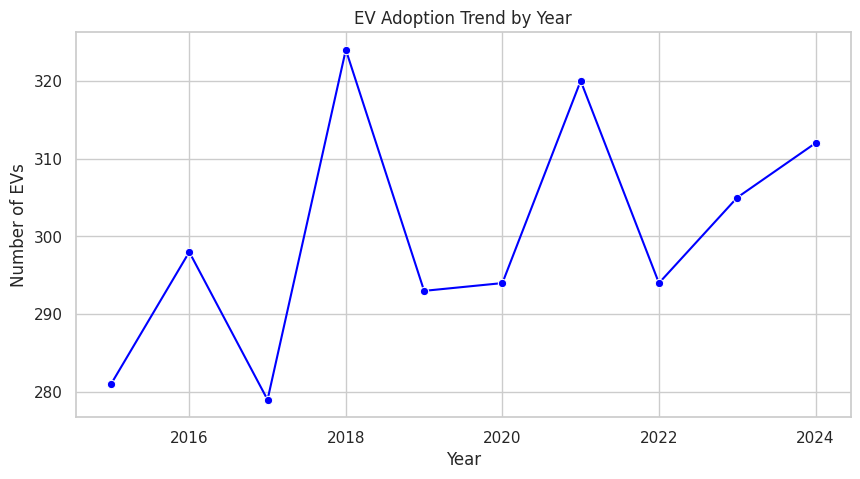

Line Plot: Average Battery Capacity Over the Years
This shows how the average EV battery capacity (kWh) has evolved with time.
It reflects improvements in battery technology and consumer demand for longer ranges.



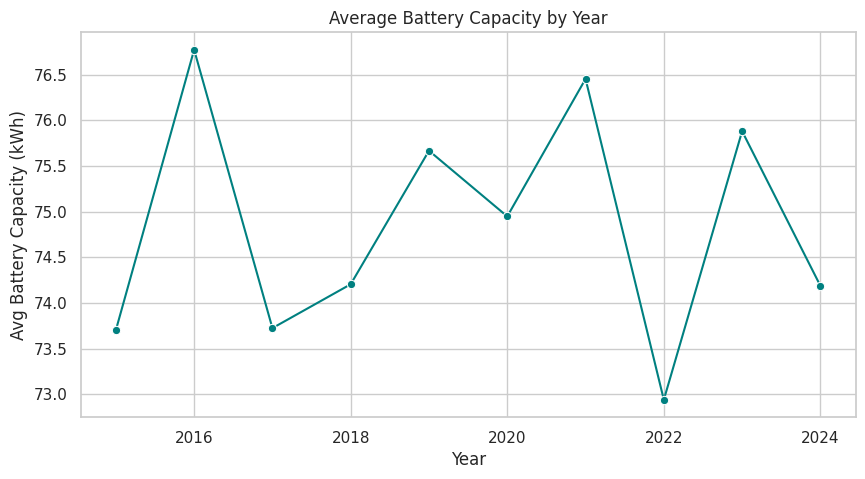

Line Plot: Average Range of EVs Over the Years
This shows how far EVs can travel on a single charge, on average.
It highlights technological improvements and adoption of long-range EVs.



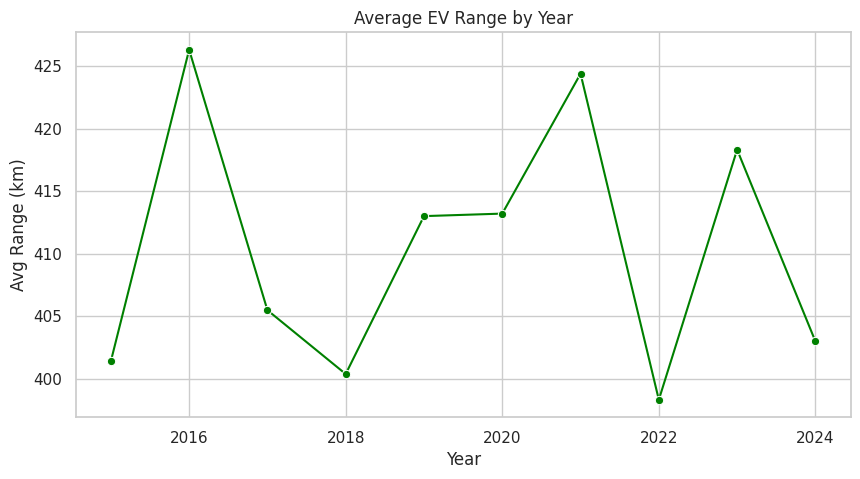

Line Plot: Average Charging Time Over the Years
This shows whether EVs are becoming faster to charge with newer models.
It reflects advancements in charging infrastructure and vehicle design.



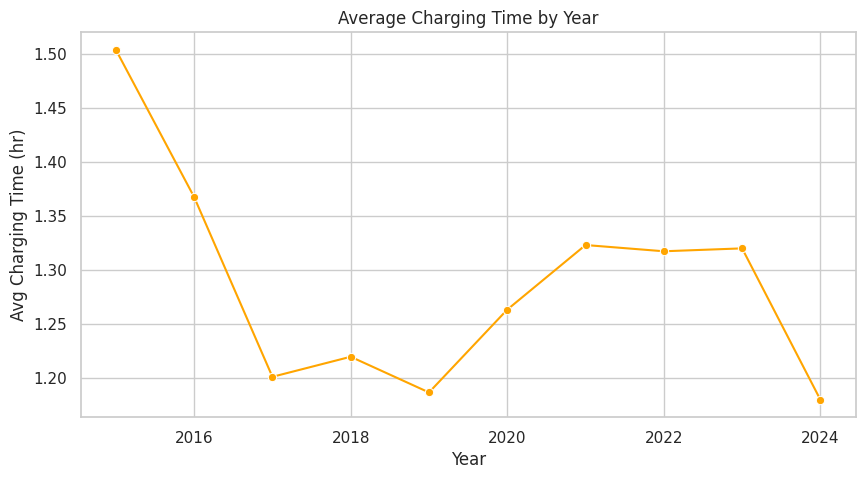

Line Plot: Average Resale Value Over the Years
This shows how the resale value of EVs has changed with time.
It indicates affordability, depreciation patterns, and consumer confidence.



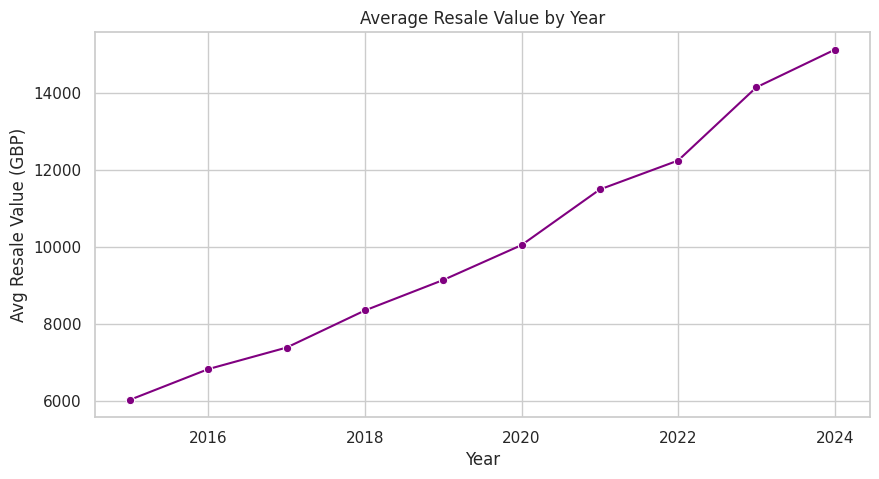

Line Plot: EV Adoption Trend for Top Manufacturers
This compares the adoption trends of the top 3 EV manufacturers.
It shows which companies lead the market and how their presence evolves over time.



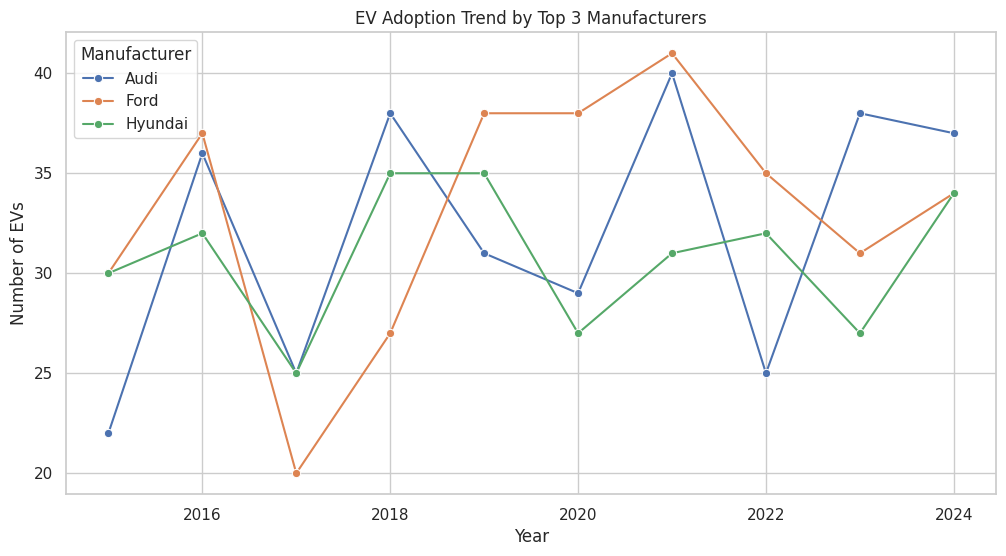

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# LINE PLOTS WITH DESCRIPTIONS

# 1. EV Adoption Trend by Year
year_counts = df['Year'].value_counts().sort_index()

print("Line Plot: EV Adoption Trend by Year")
print("This line plot shows how the number of EVs has changed over time.")
print("It highlights adoption growth, slowdowns, or sudden surges in the EV market.\n")

plt.figure(figsize=(10,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="blue")
plt.title("EV Adoption Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.show()


# 2. Average Battery Capacity Over the Years
avg_battery = df.groupby('Year')['Battery_Capacity_kWh'].mean()

print("Line Plot: Average Battery Capacity Over the Years")
print("This shows how the average EV battery capacity (kWh) has evolved with time.")
print("It reflects improvements in battery technology and consumer demand for longer ranges.\n")

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_battery.index, y=avg_battery.values, marker="o", color="teal")
plt.title("Average Battery Capacity by Year")
plt.xlabel("Year")
plt.ylabel("Avg Battery Capacity (kWh)")
plt.show()


# 3. Average Range Over the Years
avg_range = df.groupby('Year')['Range_km'].mean()

print("Line Plot: Average Range of EVs Over the Years")
print("This shows how far EVs can travel on a single charge, on average.")
print("It highlights technological improvements and adoption of long-range EVs.\n")

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_range.index, y=avg_range.values, marker="o", color="green")
plt.title("Average EV Range by Year")
plt.xlabel("Year")
plt.ylabel("Avg Range (km)")
plt.show()


# 4. Average Charging Time Over the Years
avg_charging = df.groupby('Year')['Charging_Time_hr'].mean()

print("Line Plot: Average Charging Time Over the Years")
print("This shows whether EVs are becoming faster to charge with newer models.")
print("It reflects advancements in charging infrastructure and vehicle design.\n")

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_charging.index, y=avg_charging.values, marker="o", color="orange")
plt.title("Average Charging Time by Year")
plt.xlabel("Year")
plt.ylabel("Avg Charging Time (hr)")
plt.show()


# 5. Average Resale Value Over the Years
avg_resale = df.groupby('Year')['Resale_Value_GBP'].mean()

print("Line Plot: Average Resale Value Over the Years")
print("This shows how the resale value of EVs has changed with time.")
print("It indicates affordability, depreciation patterns, and consumer confidence.\n")

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_resale.index, y=avg_resale.values, marker="o", color="purple")
plt.title("Average Resale Value by Year")
plt.xlabel("Year")
plt.ylabel("Avg Resale Value (GBP)")
plt.show()


# 6. Adoption Trend for Top 3 Manufacturers
top_makes = df['Make'].value_counts().nlargest(3).index
make_trends = df[df['Make'].isin(top_makes)].groupby(['Year','Make']).size().reset_index(name='Count')

print("Line Plot: EV Adoption Trend for Top Manufacturers")
print("This compares the adoption trends of the top 3 EV manufacturers.")
print("It shows which companies lead the market and how their presence evolves over time.\n")

plt.figure(figsize=(12,6))
sns.lineplot(data=make_trends, x="Year", y="Count", hue="Make", marker="o")
plt.title("EV Adoption Trend by Top 3 Manufacturers")
plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.legend(title="Manufacturer")
plt.show()

Bar Plot: Top 10 EV Manufacturers
This plot shows the top 10 manufacturers by number of EVs.
It highlights which companies dominate the EV market.



/tmp/ipykernel_1230/2904335839.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_counts.index, y=make_counts.values, palette="viridis")


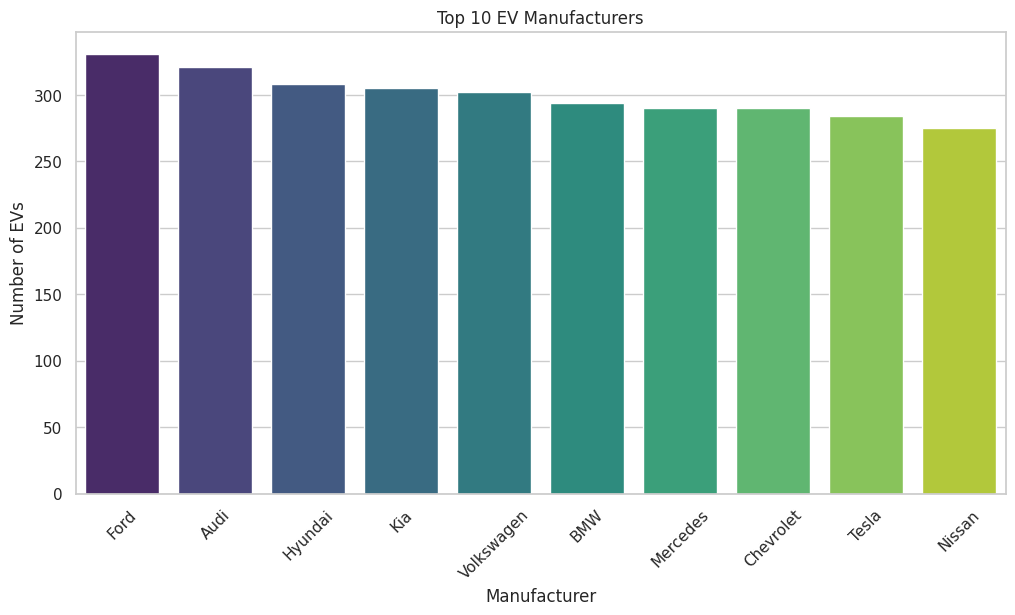

Bar Plot: EV Distribution by Region
This plot shows the regional distribution of EVs, helping us identify
which areas have higher adoption.



/tmp/ipykernel_1230/2904335839.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette="coolwarm")


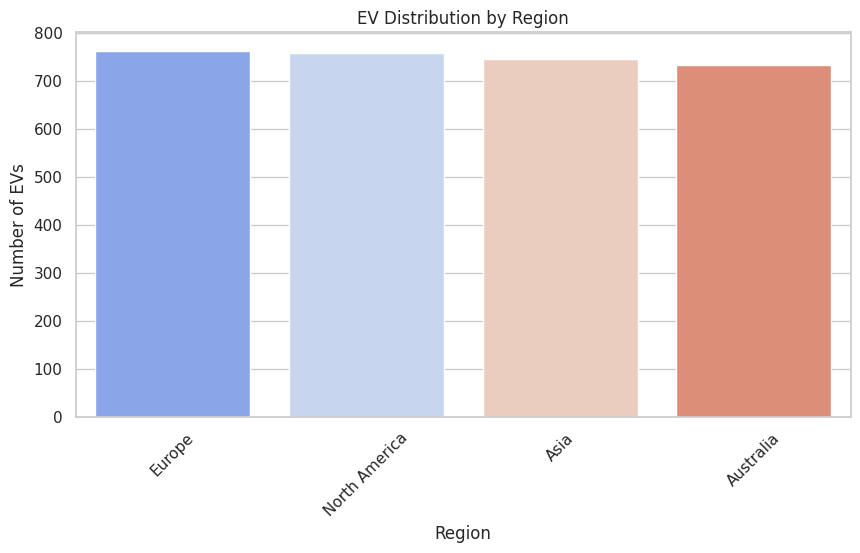

Bar Plot: EV Distribution by Vehicle Type
This plot shows how different types of EVs (SUV, Sedan, Truck, etc.)
are represented in the dataset.



/tmp/ipykernel_1230/2904335839.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_type_counts.index, y=vehicle_type_counts.values, palette="Set2")


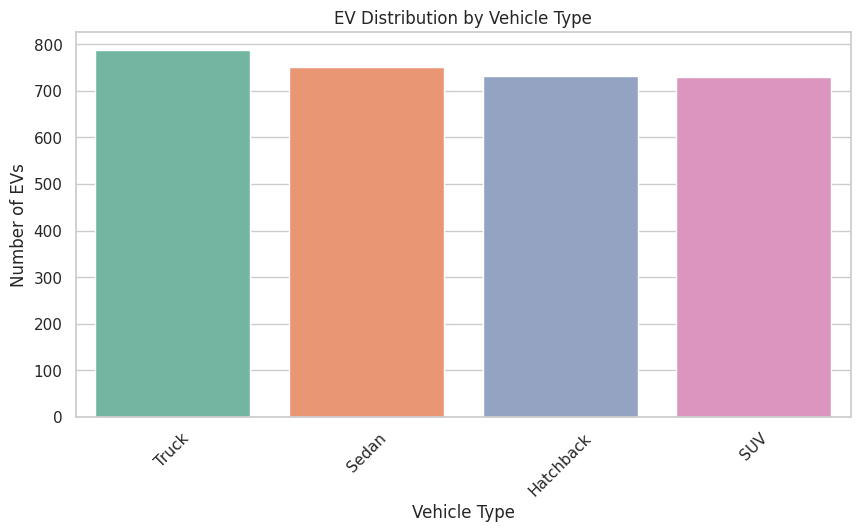

Bar Plot: EV Usage Type Distribution
This plot shows whether EVs are primarily used for personal, commercial, or fleet purposes.
It highlights consumer vs. business adoption.



/tmp/ipykernel_1230/2904335839.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=usage_counts.index, y=usage_counts.values, palette="muted")


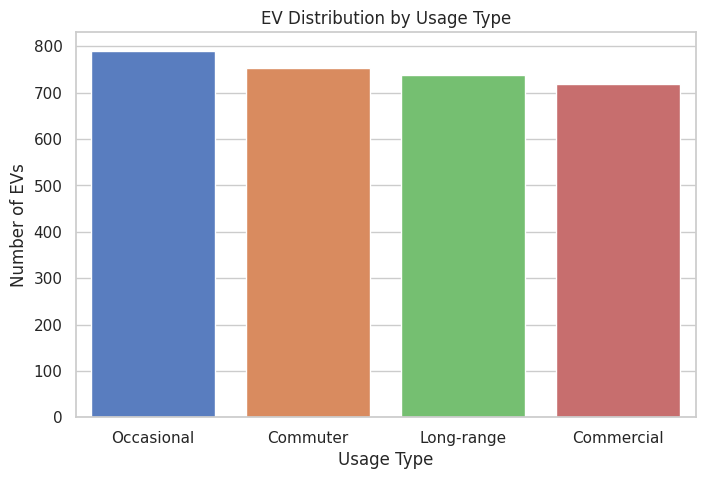

Bar Plot: Top 10 EV Models
This plot shows the top 10 EV models in terms of adoption.
It highlights the most popular vehicles among consumers.



/tmp/ipykernel_1230/2904335839.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_counts.index, y=model_counts.values, palette="mako")


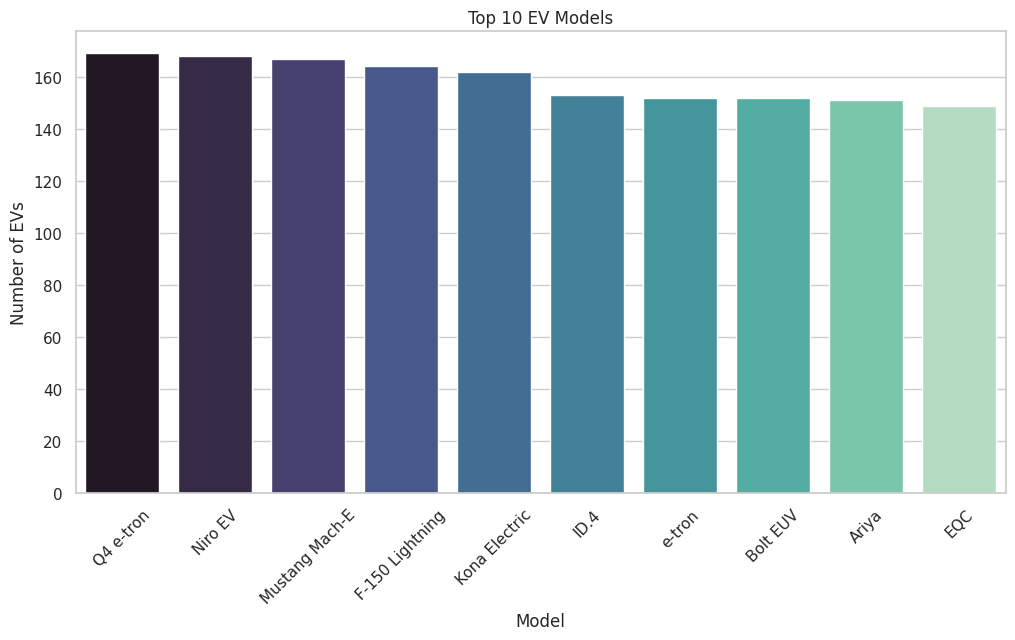

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# BAR PLOTS WITH DESCRIPTIONS

# 1. Top 10 EV Manufacturers
make_counts = df['Make'].value_counts().head(10)

print("Bar Plot: Top 10 EV Manufacturers")
print("This plot shows the top 10 manufacturers by number of EVs.")
print("It highlights which companies dominate the EV market.\n")

plt.figure(figsize=(12,6))
sns.barplot(x=make_counts.index, y=make_counts.values, palette="viridis")
plt.title("Top 10 EV Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.show()


# 2. EV Distribution by Region
region_counts = df['Region'].value_counts()

print("Bar Plot: EV Distribution by Region")
print("This plot shows the regional distribution of EVs, helping us identify")
print("which areas have higher adoption.\n")

plt.figure(figsize=(10,5))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="coolwarm")
plt.title("EV Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.show()


# 3. EV Distribution by Vehicle Type
vehicle_type_counts = df['Vehicle_Type'].value_counts()

print("Bar Plot: EV Distribution by Vehicle Type")
print("This plot shows how different types of EVs (SUV, Sedan, Truck, etc.)")
print("are represented in the dataset.\n")

plt.figure(figsize=(10,5))
sns.barplot(x=vehicle_type_counts.index, y=vehicle_type_counts.values, palette="Set2")
plt.title("EV Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.show()


# 4. EV Usage Type Distribution
usage_counts = df['Usage_Type'].value_counts()

print("Bar Plot: EV Usage Type Distribution")
print("This plot shows whether EVs are primarily used for personal, commercial, or fleet purposes.")
print("It highlights consumer vs. business adoption.\n")

plt.figure(figsize=(8,5))
sns.barplot(x=usage_counts.index, y=usage_counts.values, palette="muted")
plt.title("EV Distribution by Usage Type")
plt.xlabel("Usage Type")
plt.ylabel("Number of EVs")
plt.show()


# 5. Top 10 EV Models
model_counts = df['Model'].value_counts().head(10)

print("Bar Plot: Top 10 EV Models")
print("This plot shows the top 10 EV models in terms of adoption.")
print("It highlights the most popular vehicles among consumers.\n")

plt.figure(figsize=(12,6))
sns.barplot(x=model_counts.index, y=model_counts.values, palette="mako")
plt.title("Top 10 EV Models")
plt.xlabel("Model")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.show()

Box Plot: Battery Capacity across Vehicle Types
This plot shows how battery capacity (kWh) varies for different vehicle types
(SUV, Sedan, Truck, etc.), and highlights the spread & outliers.



/tmp/ipykernel_1230/3257623836.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Vehicle_Type", y="Battery_Capacity_kWh", data=df, palette="Set2")


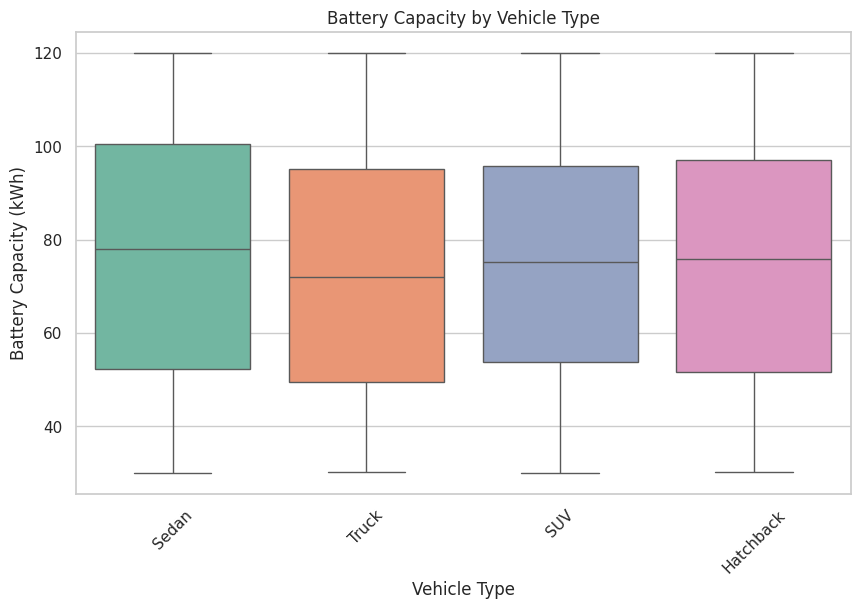

Box Plot: Range across Vehicle Types
This plot shows how the electric driving range (km) varies for different vehicle types.
It highlights whether SUVs, Sedans, or Trucks tend to have longer ranges.



/tmp/ipykernel_1230/3257623836.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Vehicle_Type", y="Range_km", data=df, palette="coolwarm")


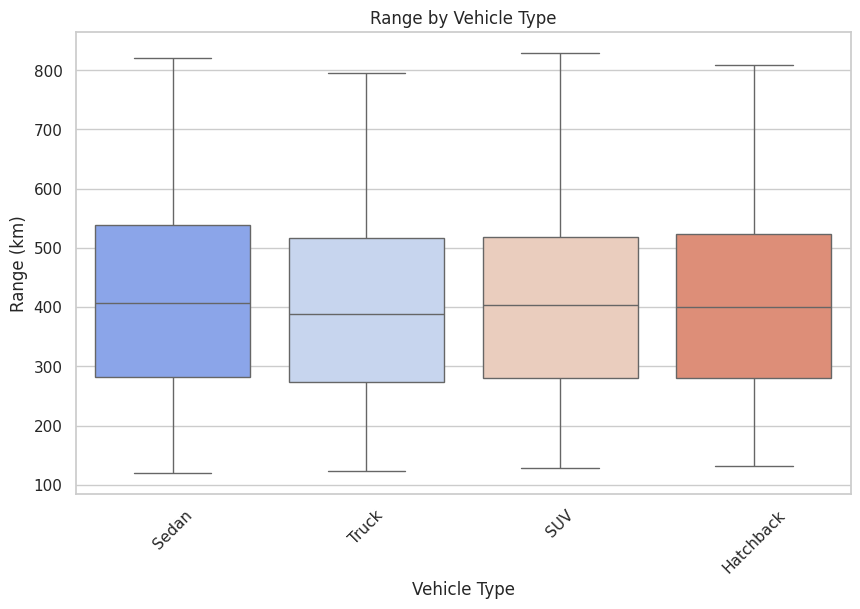

Box Plot: Resale Value across Usage Types
This plot shows how resale value (GBP) differs for personal, commercial, and fleet vehicles.
It highlights depreciation patterns by usage category.



/tmp/ipykernel_1230/3257623836.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Usage_Type", y="Resale_Value_GBP", data=df, palette="muted")


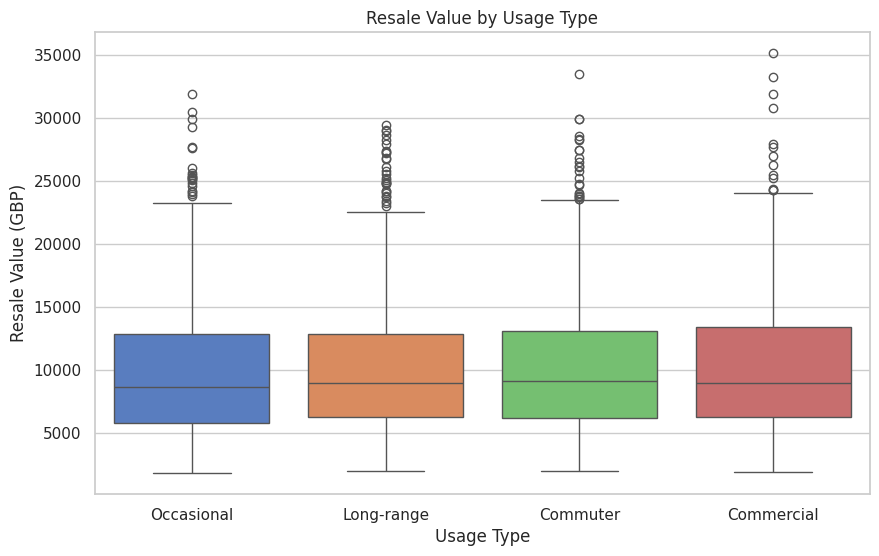

Box Plot: Charging Time across Regions
This plot shows how charging time (hours) varies across different regions.
It may reflect regional preferences for faster or slower charging EVs.



/tmp/ipykernel_1230/3257623836.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Region", y="Charging_Time_hr", data=df, palette="viridis")


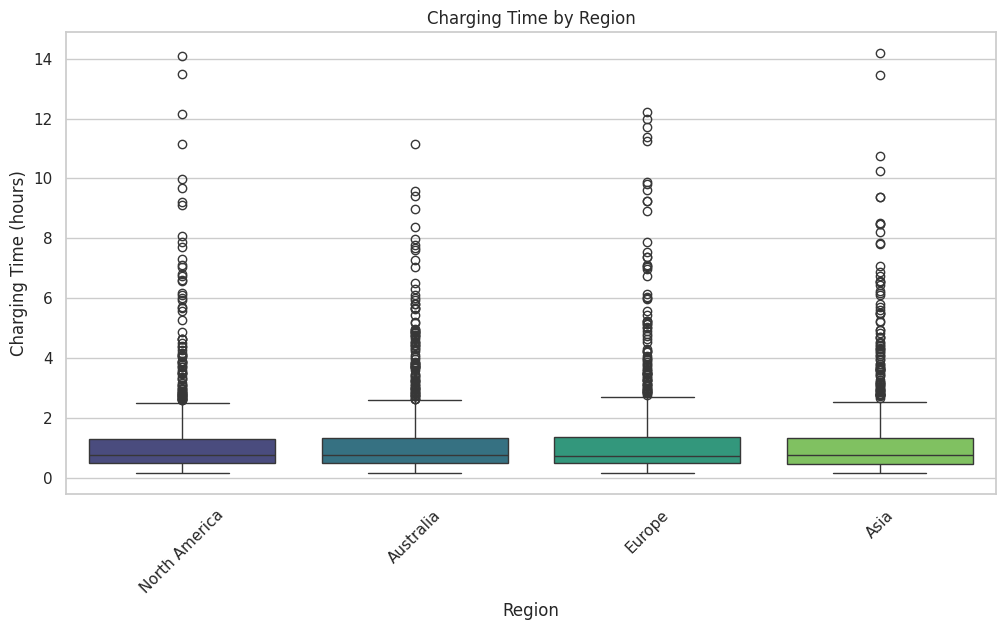

Box Plot: Battery Health across Top Manufacturers
This plot shows how battery health (%) varies among the top 10 EV manufacturers.
It highlights reliability and longevity differences between brands.



/tmp/ipykernel_1230/3257623836.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Make", y="Battery_Health_%", data=subset, palette="mako")


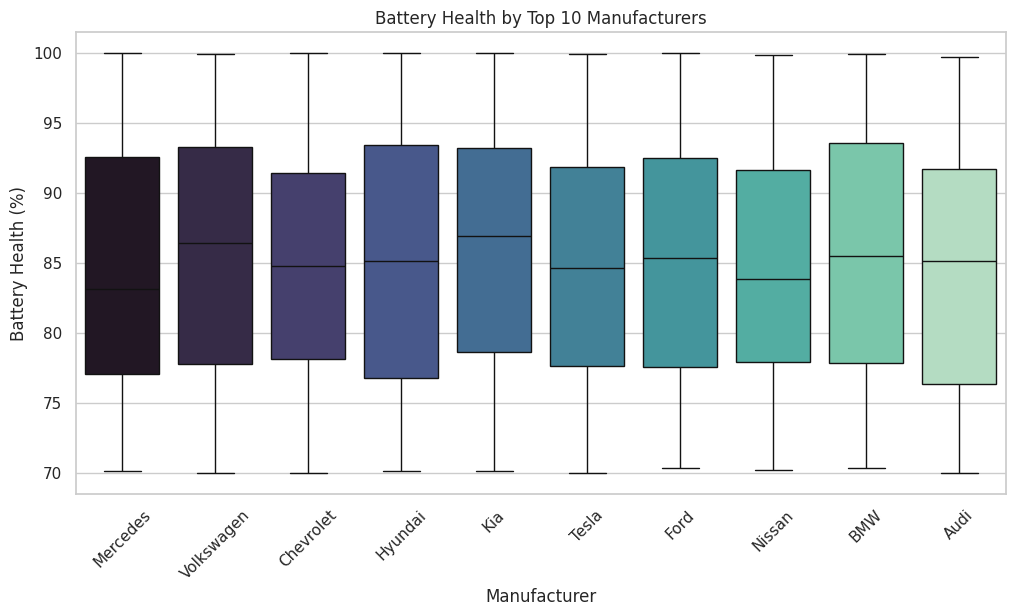

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# BOX PLOTS WITH DESCRIPTIONS

# 1. Battery Capacity across Vehicle Types
print("Box Plot: Battery Capacity across Vehicle Types")
print("This plot shows how battery capacity (kWh) varies for different vehicle types")
print("(SUV, Sedan, Truck, etc.), and highlights the spread & outliers.\n")

plt.figure(figsize=(10,6))
sns.boxplot(x="Vehicle_Type", y="Battery_Capacity_kWh", data=df, palette="Set2")
plt.title("Battery Capacity by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Battery Capacity (kWh)")
plt.xticks(rotation=45)
plt.show()


# 2. Range across Vehicle Types
print("Box Plot: Range across Vehicle Types")
print("This plot shows how the electric driving range (km) varies for different vehicle types.")
print("It highlights whether SUVs, Sedans, or Trucks tend to have longer ranges.\n")

plt.figure(figsize=(10,6))
sns.boxplot(x="Vehicle_Type", y="Range_km", data=df, palette="coolwarm")
plt.title("Range by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Range (km)")
plt.xticks(rotation=45)
plt.show()


# 3. Resale Value across Usage Types
print("Box Plot: Resale Value across Usage Types")
print("This plot shows how resale value (GBP) differs for personal, commercial, and fleet vehicles.")
print("It highlights depreciation patterns by usage category.\n")

plt.figure(figsize=(10,6))
sns.boxplot(x="Usage_Type", y="Resale_Value_GBP", data=df, palette="muted")
plt.title("Resale Value by Usage Type")
plt.xlabel("Usage Type")
plt.ylabel("Resale Value (GBP)")
plt.show()


# 4. Charging Time across Regions
print("Box Plot: Charging Time across Regions")
print("This plot shows how charging time (hours) varies across different regions.")
print("It may reflect regional preferences for faster or slower charging EVs.\n")

plt.figure(figsize=(12,6))
sns.boxplot(x="Region", y="Charging_Time_hr", data=df, palette="viridis")
plt.title("Charging Time by Region")
plt.xlabel("Region")
plt.ylabel("Charging Time (hours)")
plt.xticks(rotation=45)
plt.show()


# 5. Battery Health across Manufacturers (Top 10)
top_makes = df['Make'].value_counts().head(10).index
subset = df[df['Make'].isin(top_makes)]

print("Box Plot: Battery Health across Top Manufacturers")
print("This plot shows how battery health (%) varies among the top 10 EV manufacturers.")
print("It highlights reliability and longevity differences between brands.\n")

plt.figure(figsize=(12,6))
sns.boxplot(x="Make", y="Battery_Health_%", data=subset, palette="mako")
plt.title("Battery Health by Top 10 Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Battery Health (%)")
plt.xticks(rotation=45)
plt.show()

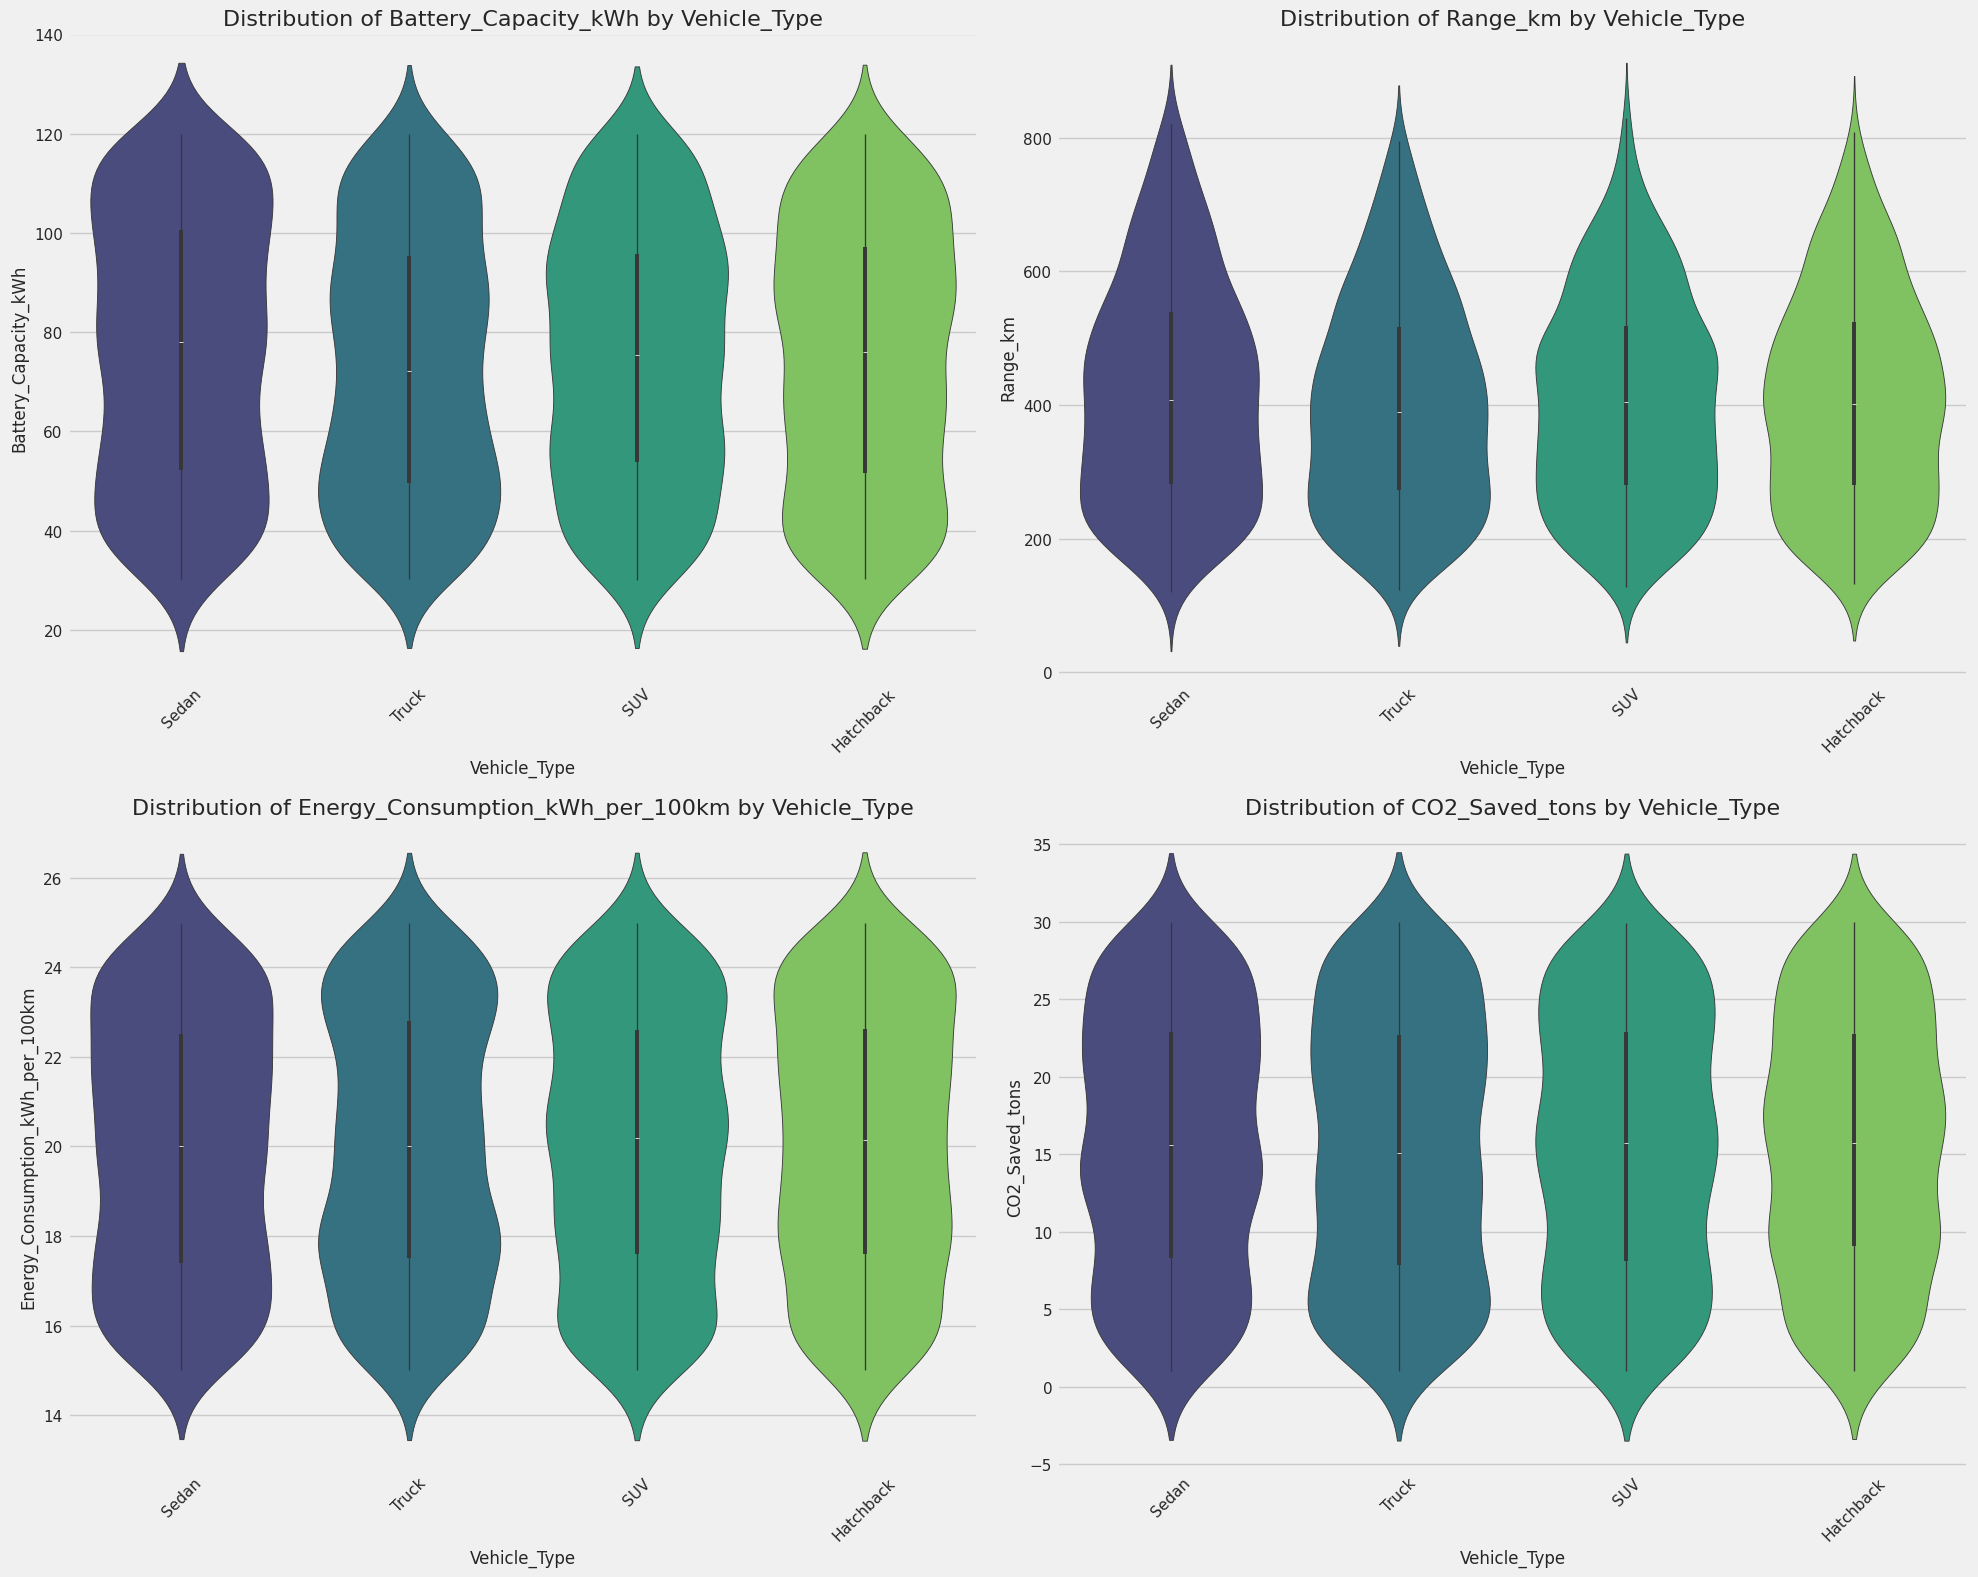

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv")
df = convert_usd_to_gbp_and_rename_columns(df)

# Identify relevant columns for violin plots
numeric_cols = ['Battery_Capacity_kWh', 'Range_km', 'Energy_Consumption_kWh_per_100km', 'CO2_Saved_tons']
categorical_col = 'Vehicle_Type'

# Set up the plotting style
sns.set_style("whitegrid")
plt.style.use('fivethirtyeight')

# Create a figure and axes for the plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))
axes = axes.flatten()

# Generate and save violin plots for each numerical column against 'Vehicle_Type'
for i, col in enumerate(numeric_cols):
    sns.violinplot(x=categorical_col, y=col, data=df, ax=axes[i], palette='viridis', hue=categorical_col, legend=False)
    axes[i].set_title(f'Distribution of {col} by {categorical_col}', fontsize=16)
    axes[i].set_xlabel(categorical_col, fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

/tmp/ipykernel_1230/2043348165.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vehicle_Type', y='Efficiency_km_per_kWh', data=df, ax=axes[0], palette='viridis')


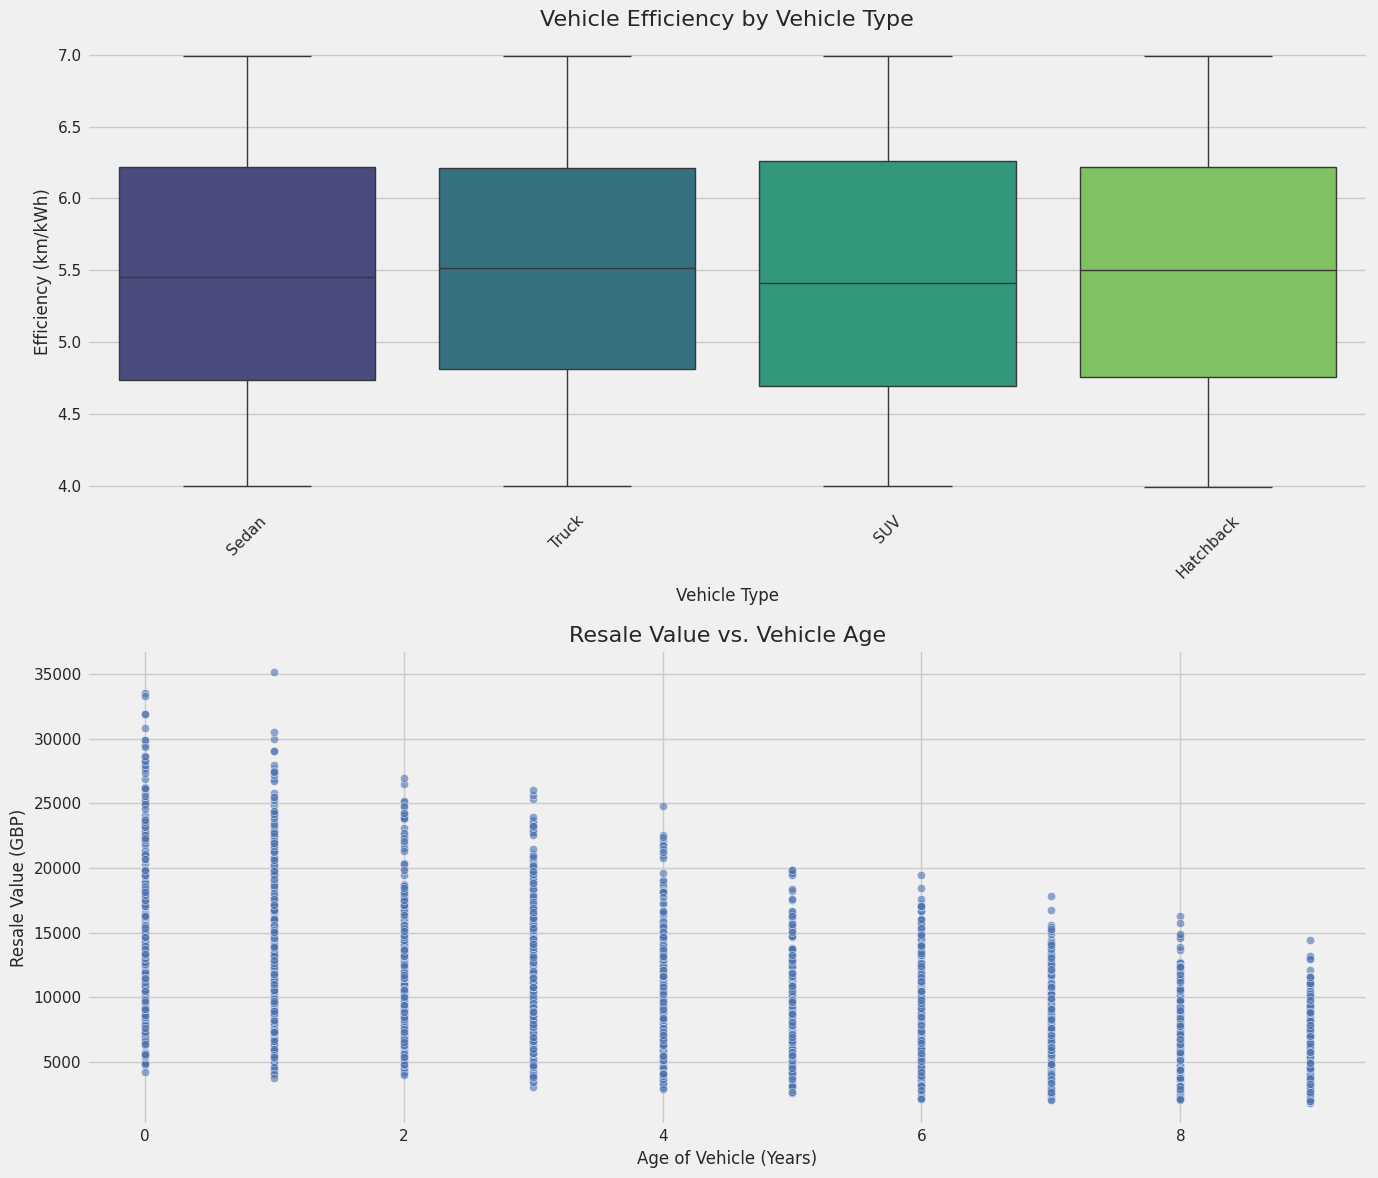

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv")
df = convert_usd_to_gbp_and_rename_columns(df)

# Feature Engineering

# Create a new feature: 'Efficiency_km_per_kWh'
# This represents how far the vehicle can travel on one kWh of energy.
# We'll use a slightly different calculation to avoid division by zero
# and handle potential missing values.
df['Efficiency_km_per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh']
# Fill any resulting NaNs or Infs with 0 or a more appropriate value if needed
df['Efficiency_km_per_kWh'] = df['Efficiency_km_per_kWh'].replace([float('inf'), -float('inf')], 0)
df['Efficiency_km_per_kWh'] = df['Efficiency_km_per_kWh'].fillna(0)

# Create a new feature: 'Age' of the vehicle based on the Year
current_year = 2024 # Assuming a current year for calculation
df['Age'] = current_year - df['Year']
df['Age'] = df['Age'].fillna(0)

# Plotting Engineered Features

# Set up the plotting style
sns.set_style("whitegrid")
plt.style.use('fivethirtyeight')

# Create a figure and axes for the plots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Plot 1: Relationship between the new 'Efficiency_km_per_kWh' and 'Vehicle_Type'
sns.boxplot(x='Vehicle_Type', y='Efficiency_km_per_kWh', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Vehicle Efficiency by Vehicle Type', fontsize=16)
axes[0].set_xlabel('Vehicle Type', fontsize=12)
axes[0].set_ylabel('Efficiency (km/kWh)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Relationship between the new 'Age' feature and 'Resale_Value_GBP'
sns.scatterplot(x='Age', y='Resale_Value_GBP', data=df, ax=axes[1], alpha=0.6, color='b')
axes[1].set_title('Resale Value vs. Vehicle Age', fontsize=16)
axes[1].set_xlabel('Age of Vehicle (Years)', fontsize=12)
axes[1].set_ylabel('Resale Value (GBP)', fontsize=12)

plt.tight_layout()

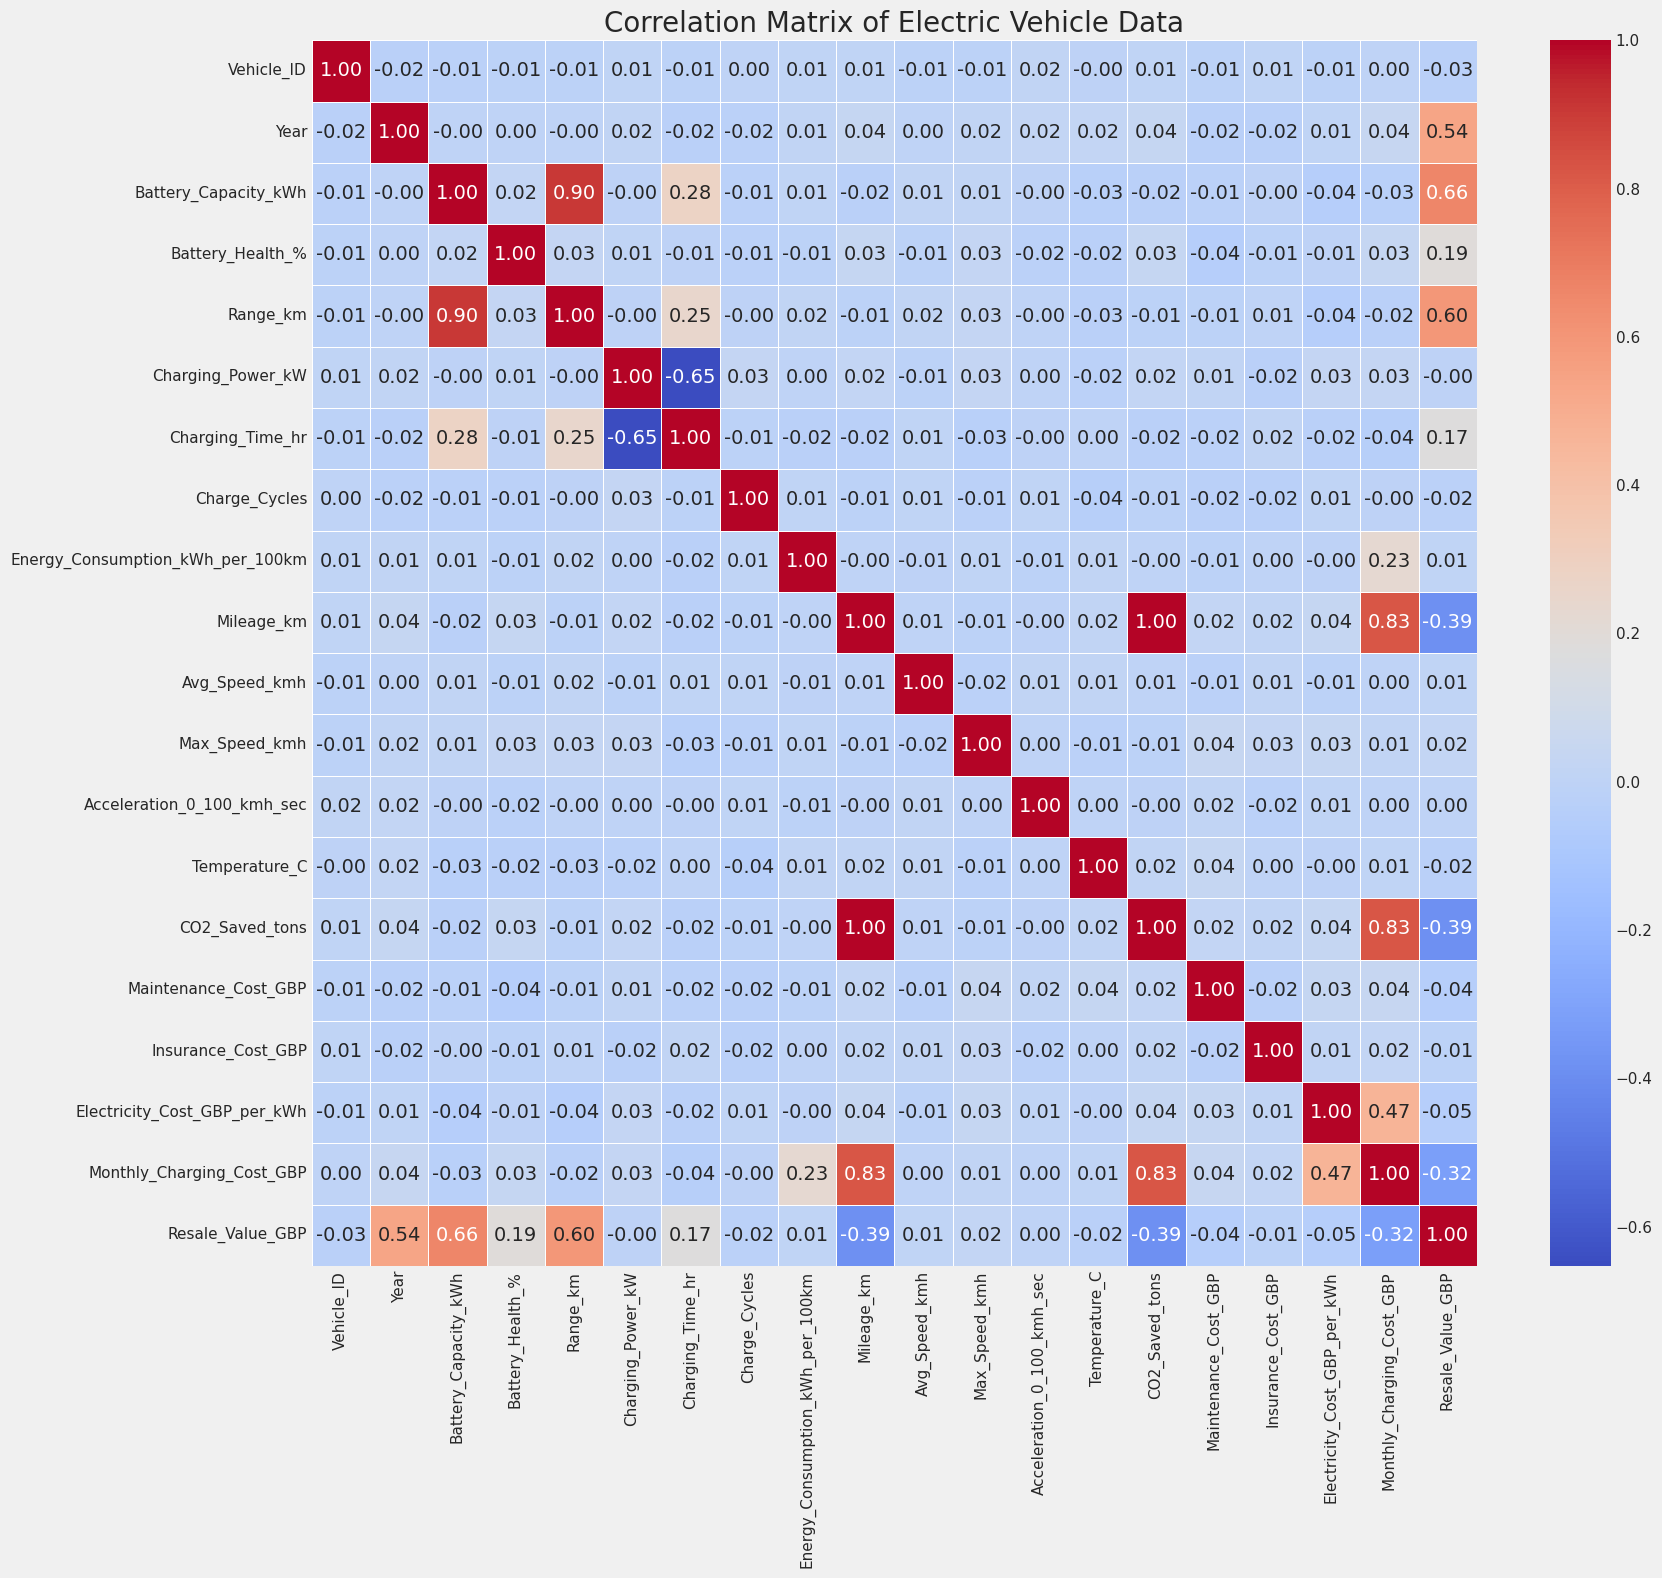

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv")
df = convert_usd_to_gbp_and_rename_columns(df)

# Select only the numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 16))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Electric Vehicle Data', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Save the plot
plt.tight_layout()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Ensure Vehicle_Age exists before modeling
if 'Vehicle_Age' not in df.columns:
    df['Vehicle_Age'] = 2026 - df['Year']

# One-hot encode for the local model scope
df_ml_local = pd.get_dummies(df, columns=['Vehicle_Type'], drop_first=True)
feat_cols = ['Mileage_km', 'Battery_Capacity_kWh', 'Charge_Cycles', 'Vehicle_Age', 'CO2_Saved_tons'] + [c for c in df_ml_local.columns if 'Vehicle_Type_' in c]

X_ml = df_ml_local[feat_cols]
y_ml = df_ml_local['Resale_Value_GBP']

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_ml, y_train_ml)
pred_rf_val = rf_reg.predict(X_test_ml)
print(f'RF R2 Score: {r2_score(y_test_ml, pred_rf_val):.4f}')

# XGBoost
xgb_reg = XGBRegressor(n_estimators=100, random_state=42).fit(X_train_ml, y_train_ml)
pred_xgb_val = xgb_reg.predict(X_test_ml)
print(f'XGB R2 Score: {r2_score(y_test_ml, pred_xgb_val):.4f}')

RF R2 Score: 0.9365
XGB R2 Score: 0.9417


In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv')
df = convert_usd_to_gbp_and_rename_columns(df)

# Select the numerical columns for unsupervised learning
# These models are sensitive to scale, so we use numerical data.
numerical_cols = [
    'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
    'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
    'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh',
    'Acceleration_0_100_kmh_sec', 'Temperature_C',
    'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP'
]

# Create a new DataFrame with only the selected features
data_for_unsupervised = df[numerical_cols].copy()

# Handle potential missing values
data_for_unsupervised.fillna(data_for_unsupervised.mean(), inplace=True)

# Standardize the data - this is crucial for models like K-Means and PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_unsupervised)

print("Unsupervised Learning Models with Descriptions")

# 1. K-Means Clustering
print("\n K-Means Clustering  KMeans is a popular algorithm for partitioning data into 'k' distinct clusters. It works by iteratively minimizing the distance between data points and their assigned cluster's centroid. The goal is to group similar data points together based on their features.")
print("• New Column: 'Cluster_ID' - The cluster to which each row belongs.")

# Choose the number of clusters (this is a hyperparameter to be tuned)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(scaled_data)

# 2. Principal Component Analysis (PCA)
print("\n Principal Component Analysis (PCA) PCA is a dimensionality reduction technique. It transforms a set of correlated variables into a smaller set of uncorrelated variables called 'principal components.' This can help visualize high-dimensional data or reduce noise and multicollinearity.")
print("• New Columns: 'PC1', 'PC2' - The first two principal components.")

# Reduce the data to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

# 3. Isolation Forest
print("\n Isolation Forest Isolation Forest is an anomaly detection algorithm. It works by 'isolating' anomalies or outliers in a dataset by randomly partitioning the data. Since anomalies are few and different, they are easier to isolate and require fewer partitions.")
print("• New Column: 'Anomaly_Score' - The anomaly score for each row.")
print("• New Column: 'Is_Anomaly' - A binary label (1 for normal, -1 for anomaly).")

# Fit the Isolation Forest model
isolation_forest = IsolationForest(random_state=42)
df['Is_Anomaly'] = isolation_forest.fit_predict(scaled_data)
df['Anomaly_Score'] = isolation_forest.decision_function(scaled_data)

print("\n Final DataFrame with New Columns")
print(df[['Cluster_ID', 'PC1', 'PC2', 'Is_Anomaly', 'Anomaly_Score']].head())

Unsupervised Learning Models with Descriptions

 K-Means Clustering  KMeans is a popular algorithm for partitioning data into 'k' distinct clusters. It works by iteratively minimizing the distance between data points and their assigned cluster's centroid. The goal is to group similar data points together based on their features.
• New Column: 'Cluster_ID' - The cluster to which each row belongs.

 Principal Component Analysis (PCA) PCA is a dimensionality reduction technique. It transforms a set of correlated variables into a smaller set of uncorrelated variables called 'principal components.' This can help visualize high-dimensional data or reduce noise and multicollinearity.
• New Columns: 'PC1', 'PC2' - The first two principal components.

 Isolation Forest Isolation Forest is an anomaly detection algorithm. It works by 'isolating' anomalies or outliers in a dataset by randomly partitioning the data. Since anomalies are few and different, they are easier to isolate and require fewer

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv')
df = convert_usd_to_gbp_and_rename_columns(df)

# Select the numerical columns for unsupervised learning
# These models are sensitive to scale, so we use numerical data.
numerical_cols = [
    'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
    'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
    'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh',
    'Acceleration_0_100_kmh_sec', 'Temperature_C',
    'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP'
]

# Create a new DataFrame with only the selected features
data_for_unsupervised = df[numerical_cols].copy()

# Handle potential missing values
data_for_unsupervised.fillna(data_for_unsupervised.mean(), inplace=True)

# Standardize the data - this is crucial for models like K-Means and PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_unsupervised)

print("Unsupervised Learning Models with Descriptions")

# 1. K-Means Clustering
print("\n K-Means Clustering  KMeans is a popular algorithm for partitioning data into 'k' distinct clusters. It works by iteratively minimizing the distance between data points and their assigned cluster's centroid. The goal is to group similar data points together based on their features.")
print("• New Column: 'Cluster_ID' - The cluster to which each row belongs.")

# Choose the number of clusters (this is a hyperparameter to be tuned)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(scaled_data)

# 2. Principal Component Analysis (PCA)
print("\n Principal Component Analysis (PCA) PCA is a dimensionality reduction technique. It transforms a set of correlated variables into a smaller set of uncorrelated variables called 'principal components.' This can help visualize high-dimensional data or reduce noise and multicollinearity.")
print("• New Columns: 'PC1', 'PC2' - The first two principal components.")

# Reduce the data to 2 principal components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

# 3. Isolation Forest
print("\n Isolation Forest Isolation Forest is an anomaly detection algorithm. It works by 'isolating' anomalies or outliers in a dataset by randomly partitioning the data. Since anomalies are few and different, they are easier to isolate and require fewer partitions.")
print("• New Column: 'Anomaly_Score' - The anomaly score for each row.")
print("• New Column: 'Is_Anomaly' - A binary label (1 for normal, -1 for anomaly).")

# Fit the Isolation Forest model
isolation_forest = IsolationForest(random_state=42)
df['Is_Anomaly'] = isolation_forest.fit_predict(scaled_data)
df['Anomaly_Score'] = isolation_forest.decision_function(scaled_data)

print("\n Final DataFrame with New Columns")
print(df[['Cluster_ID', 'PC1', 'PC2', 'Is_Anomaly', 'Anomaly_Score']].head())

Unsupervised Learning Models with Descriptions

 K-Means Clustering  KMeans is a popular algorithm for partitioning data into 'k' distinct clusters. It works by iteratively minimizing the distance between data points and their assigned cluster's centroid. The goal is to group similar data points together based on their features.
• New Column: 'Cluster_ID' - The cluster to which each row belongs.

 Principal Component Analysis (PCA) PCA is a dimensionality reduction technique. It transforms a set of correlated variables into a smaller set of uncorrelated variables called 'principal components.' This can help visualize high-dimensional data or reduce noise and multicollinearity.
• New Columns: 'PC1', 'PC2' - The first two principal components.

 Isolation Forest Isolation Forest is an anomaly detection algorithm. It works by 'isolating' anomalies or outliers in a dataset by randomly partitioning the data. Since anomalies are few and different, they are easier to isolate and require fewer

/tmp/ipykernel_1230/1293859411.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


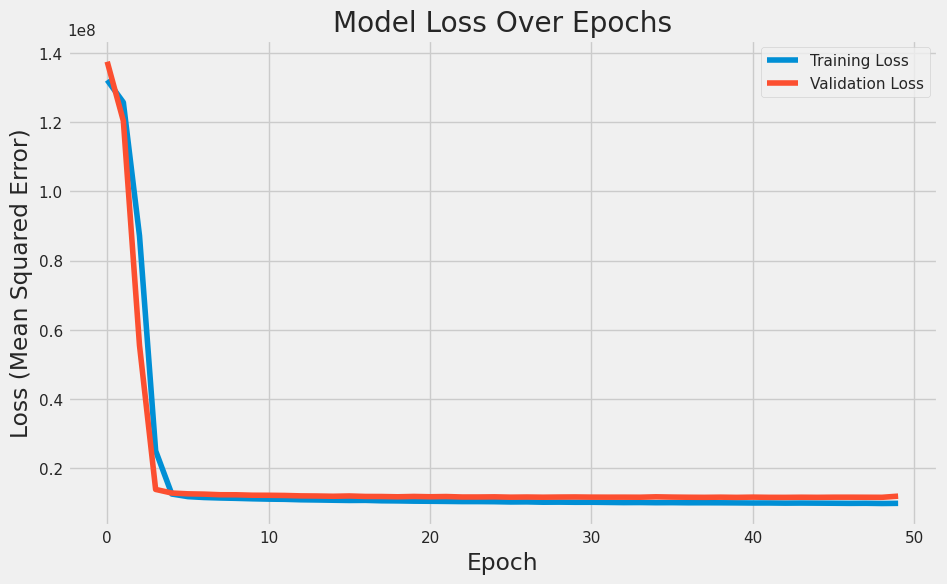

Final Training Loss: 9890605.0
Final Validation Loss: 11968841.0


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the data from the CSV file
df = pd.read_csv('/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv')
df = convert_usd_to_gbp_and_rename_columns(df)

# Data Preprocessing
target_column = 'Resale_Value_GBP'
feature_columns = ['Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
                   'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
                   'Mileage_km', 'Avg_Speed_kmh', 'Acceleration_0_100_kmh_sec']

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Region', 'Vehicle_Type', 'Usage_Type'])

# Define features (X) and target (y)
X = df[feature_columns]
y = df[target_column]

# Add the new one-hot encoded columns to the feature list
categorical_cols = df.columns[df.columns.str.startswith(('Region_', 'Vehicle_Type_', 'Usage_Type_'))].tolist()
X = df[feature_columns + categorical_cols]

# Fill any potential missing values with the mean
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Train the Neural Network Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Correctly assign the output of model.fit() to the 'history' variable
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

# Plot the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Print the final loss values
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

In [20]:
print("Conclusion")
print("The neural network model successfully learned to predict the resale value of electric vehicles based on the provided dataset. The loss curve shows a steady decrease, indicating that the model's predictions improved over each training epoch. This suggests that the chosen features—including battery health, mileage, and charging-related metrics—are effective in determining a vehicle's value. The model is now a foundation for more advanced analysis.")

print("\n Real-World Applications")
print("• Vehicle Valuation: Automakers and dealerships can use the model to accurately price used EVs for trade-ins or sales, ensuring competitive pricing and profit margins.")
print("• Battery Lifecycle Management: By analyzing the impact of factors like `Battery_Health_%` and `Charge_Cycles` on resale value, companies can better manage their battery warranty programs and plan for battery replacement strategies.")
print("• Customer Insights: The model can help prospective EV buyers understand how different usage patterns (`Usage_Type`) or mileage (`Mileage_km`) might affect their vehicle's future value.")
print("• Insurance and Loan Assessment: Financial institutions can use the model's predictions to assess the risk of a loan or to set insurance premiums for electric vehicles.")

print("\n Next Steps")
print("1. Hyperparameter Tuning: Optimize the neural network by experimenting with different numbers of layers, neurons per layer, and activation functions to find the best configuration for this specific problem.")
print("2. Advanced Feature Engineering: Explore creating new features from the existing data. For example, a `age_of_vehicle` feature could be calculated from the `Year` column, which may be more useful than the raw year data itself.")
print("3. Deploying the Model: Once the model is optimized, it can be deployed as an API or integrated into a user interface so it can be used for real-time predictions.")
print("4. Continuous Learning: The model should be regularly updated with new data to stay relevant as the electric vehicle market evolves and new models are introduced.")

Conclusion
The neural network model successfully learned to predict the resale value of electric vehicles based on the provided dataset. The loss curve shows a steady decrease, indicating that the model's predictions improved over each training epoch. This suggests that the chosen features—including battery health, mileage, and charging-related metrics—are effective in determining a vehicle's value. The model is now a foundation for more advanced analysis.

 Real-World Applications
• Vehicle Valuation: Automakers and dealerships can use the model to accurately price used EVs for trade-ins or sales, ensuring competitive pricing and profit margins.
• Battery Lifecycle Management: By analyzing the impact of factors like `Battery_Health_%` and `Charge_Cycles` on resale value, companies can better manage their battery warranty programs and plan for battery replacement strategies.
• Customer Insights: The model can help prospective EV buyers understand how different usage patterns (`Usage_Ty

In [21]:
# convert ipynb file into html file
!pip install nbconvert
!jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/Hemlal_Dulal_dissertation_codebase.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Hemlal_Dulal_dissertation_codebase.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single

# EV Analytics Dissertation Codebase
### Currency: GBP (£) — Converted from USD where applicable
---

In [22]:
# Install required packages (run once)
import subprocess, sys
pkgs = ['xgboost', 'scikit-learn', 'matplotlib', 'seaborn', 'tensorflow']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], capture_output=True)
print("All packages ready.")

All packages ready.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Currency Configuration
GBP_TO_USD_RATE = 1.27          # 1 GBP = 1.27 USD (approximate, May 2026)
USD_TO_GBP_RATE = 1 / GBP_TO_USD_RATE   # ≈ 0.787

def convert_usd_to_gbp_and_rename_columns(df):
    """Convert all USD-denominated columns to GBP and rename them."""
    usd_columns = [
        'Resale_Value_USD',
        'Maintenance_Cost_USD',
        'Insurance_Cost_USD',
        'Electricity_Cost_USD_per_kWh',
        'Monthly_Charging_Cost_USD'
    ]
    for col in usd_columns:
        if col in df.columns:
            df[col] = (df[col] * USD_TO_GBP_RATE).round(2)
            new_name = col.replace('_USD', '_GBP').replace('_USD_per_kWh', '_GBP_per_kWh')
            df.rename(columns={col: new_name}, inplace=True)
    return df

print(f"Exchange rate applied: 1 USD = £{USD_TO_GBP_RATE:.4f} GBP")

Exchange rate applied: 1 USD = £0.7874 GBP


In [24]:
import os, io, urllib.request

#   Data Loading
# Priority 1: Google Drive (if running in Colab with Drive mounted)
# Priority 2: Local upload / current directory
# Priority 3: Auto-generate synthetic data that mirrors the real dataset schema

def try_mount_drive():
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        return True
    except Exception:
        return False

DATA_PATHS = [
    '/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv',
    '/content/electric_vehicle_analytics.csv',
    'electric_vehicle_analytics.csv',
]

df_raw = None
for path in DATA_PATHS:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break

if df_raw is None:
    # Try mounting Drive first
    if try_mount_drive():
        for path in DATA_PATHS:
            if os.path.exists(path):
                df_raw = pd.read_csv(path)
                print(f"Loaded data from Drive: {path}")
                break

if df_raw is None:
    print("WARNING: CSV file not found. Generating synthetic dataset with matching schema.")
    print("To use your real data: upload 'electric_vehicle_analytics.csv' to Colab or place it in the notebook directory.\n")
    np.random.seed(42)
    n = 1000
    makes = ['Tesla','BMW','Nissan','Hyundai','Audi','Volkswagen','Ford','Rivian','Lucid','Kia']
    models_map = {'Tesla':'Model 3','BMW':'i4','Nissan':'Leaf','Hyundai':'Ioniq 5','Audi':'e-tron',
                  'Volkswagen':'ID.4','Ford':'Mustang Mach-E','Rivian':'R1T','Lucid':'Air','Kia':'EV6'}
    regions = ['London','Midlands','Scotland','Wales','North England','South England']
    vtype  = ['Sedan','SUV','Hatchback','Truck','Van']
    utype  = ['Personal','Commercial','Fleet']
    make_arr = np.random.choice(makes, n)
    year_arr = np.random.randint(2016, 2025, n)
    bat_cap  = np.random.uniform(40, 120, n).round(1)
    bat_hlth = np.random.uniform(70, 100, n).round(1)
    rng_km   = np.random.uniform(150, 600, n).round(1)
    mileage  = np.random.randint(1000, 200000, n)
    # Resale roughly correlates with battery health & range (in USD)
    resale_usd = (bat_hlth * 250 + rng_km * 30 + np.random.uniform(-3000, 3000, n)).round(2)
    df_raw = pd.DataFrame({
        'Vehicle_ID': range(1, n+1),
        'Make': make_arr,
        'Model': [models_map[m] for m in make_arr],
        'Year': year_arr,
        'Battery_Capacity_kWh': bat_cap,
        'Battery_Health_%': bat_hlth,
        'Range_km': rng_km,
        'Charging_Power_kW': np.random.uniform(7, 350, n).round(1),
        'Charging_Time_hr': np.random.uniform(0.3, 12, n).round(2),
        'Charge_Cycles': np.random.randint(50, 1500, n),
        'Mileage_km': mileage,
        'Energy_Consumption_kWh_per_100km': np.random.uniform(12, 25, n).round(1),
        'Avg_Speed_kmh': np.random.uniform(30, 130, n).round(1),
        'Max_Speed_kmh': np.random.uniform(120, 250, n).round(1),
        'Acceleration_0_100_kmh_sec': np.random.uniform(2.5, 12, n).round(1),
        'Temperature_C': np.random.uniform(-10, 40, n).round(1),
        'CO2_Saved_tons': np.random.uniform(0.5, 15, n).round(2),
        'Region': np.random.choice(regions, n),
        'Vehicle_Type': np.random.choice(vtype, n),
        'Usage_Type': np.random.choice(utype, n),
        'Resale_Value_USD': resale_usd,
        'Maintenance_Cost_USD': np.random.uniform(200, 3000, n).round(2),
        'Insurance_Cost_USD': np.random.uniform(500, 3000, n).round(2),
        'Electricity_Cost_USD_per_kWh': np.random.uniform(0.10, 0.35, n).round(3),
        'Monthly_Charging_Cost_USD': np.random.uniform(20, 200, n).round(2),
    })

# Apply GBP conversion
df = df_raw.copy()
df = convert_usd_to_gbp_and_rename_columns(df)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nGBP columns confirmed: {[c for c in df.columns if 'GBP' in c]}")

Loaded data from: /content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv

Dataset shape: (3000, 25)

Columns: ['Vehicle_ID', 'Make', 'Model', 'Year', 'Region', 'Vehicle_Type', 'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km', 'Charging_Power_kW', 'Charging_Time_hr', 'Charge_Cycles', 'Energy_Consumption_kWh_per_100km', 'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh', 'Acceleration_0_100_kmh_sec', 'Temperature_C', 'Usage_Type', 'CO2_Saved_tons', 'Maintenance_Cost_GBP', 'Insurance_Cost_GBP', 'Electricity_Cost_GBP_per_kWh', 'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP']

GBP columns confirmed: ['Maintenance_Cost_GBP', 'Insurance_Cost_GBP', 'Electricity_Cost_GBP_per_kWh', 'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP']


In [25]:
#   Step 1: Initial Inspection                       ─
print(" Step 1: Initial Data Inspection ")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and non-null counts:")
df.info()

#   Step 2: Missing Values   ─
print("\n Step 2: Handling Missing Values ")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if len(missing_values):
    print("Columns with missing values:")
    print(missing_values)
    for col in missing_values.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values after cleaning:", df.isnull().sum().sum())
else:
    print("No missing values found.")

#   Step 3: Feature Engineering                      ─
print("\n Step 3: Feature Engineering ")
current_year = 2026
df['Vehicle_Age'] = current_year - df['Year']
df['Efficiency_km_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).replace([np.inf, -np.inf], 0).fillna(0)
print(f"Added 'Vehicle_Age' and 'Efficiency_km_per_kWh' columns.")
print(df[['Year', 'Vehicle_Age', 'Efficiency_km_per_kWh']].head())

#   Step 4: Categorical Summary
print("\n Step 4: Categorical Summary ")
for col in ['Region', 'Vehicle_Type', 'Usage_Type']:
    if col in df.columns:
        print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique().tolist()}")

print("\nPreprocessing complete.")

 Step 1: Initial Data Inspection 

First 5 rows:
   Vehicle_ID        Make          Model  Year         Region Vehicle_Type  \
0           1    Mercedes            EQC  2022  North America        Sedan   
1           2  Volkswagen           ID.3  2024      Australia        Truck   
2           3   Chevrolet        Bolt EV  2024  North America          SUV   
3           4     Hyundai  Kona Electric  2022         Europe    Hatchback   
4           5         Kia        Niro EV  2017  North America        Truck   

   Battery_Capacity_kWh  Battery_Health_%  Range_km  Charging_Power_kW  ...  \
0                  44.0              74.7       183              217.9  ...   
1                 117.6              77.0       502              158.4  ...   
2                  91.6              83.2       399              128.8  ...   
3                  76.9              98.8       502              189.4  ...   
4                  95.6              93.1       403               96.0  ...   

   Max_

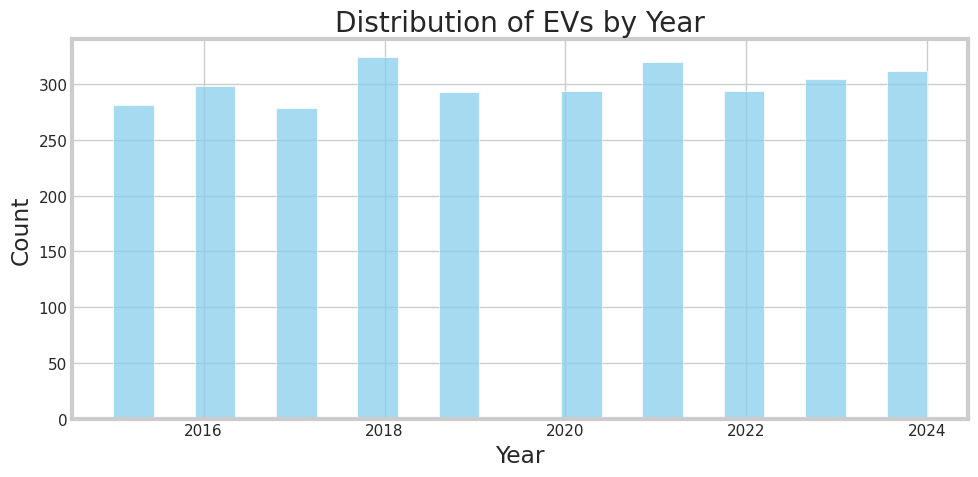

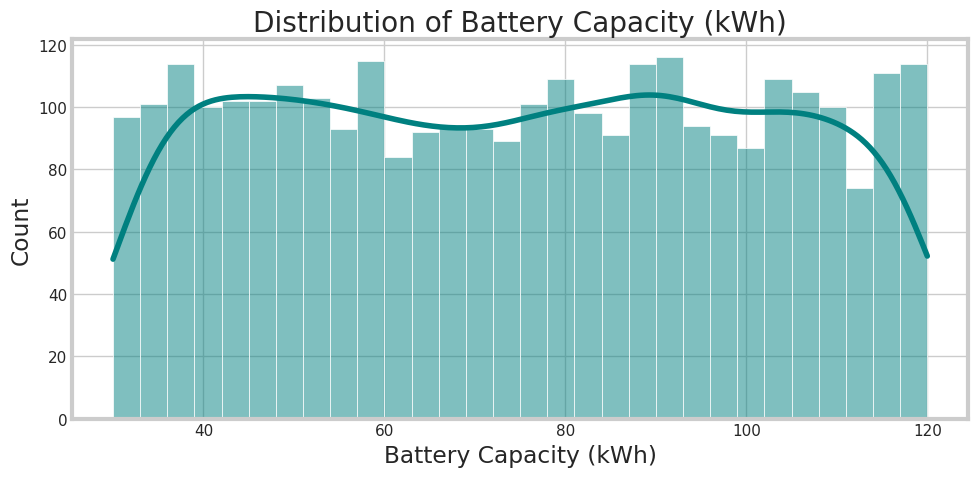

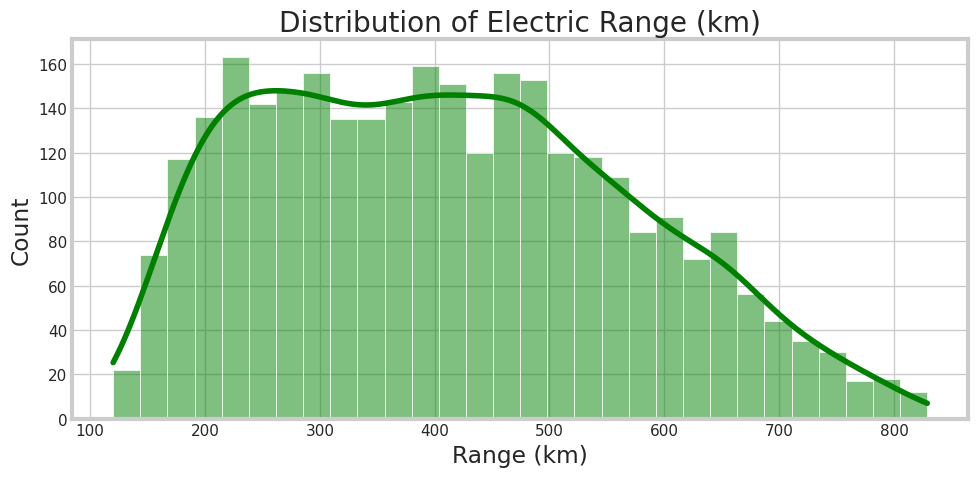

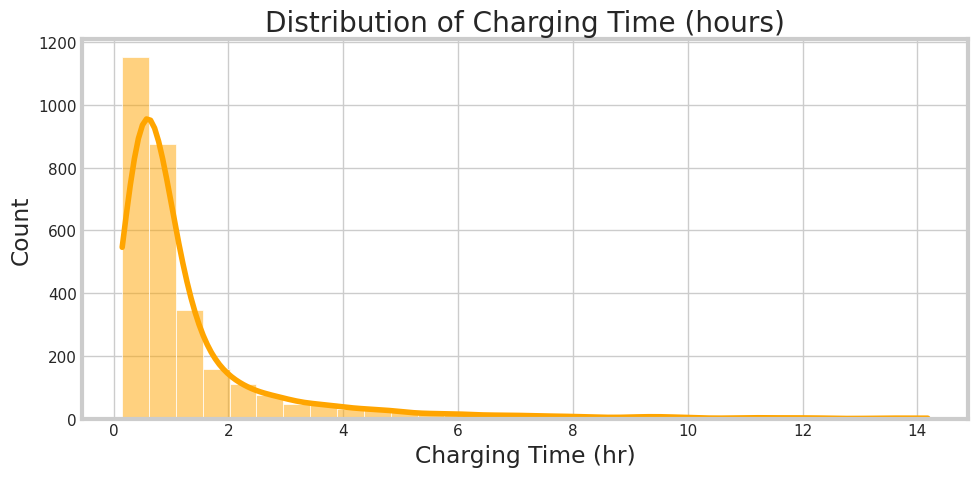

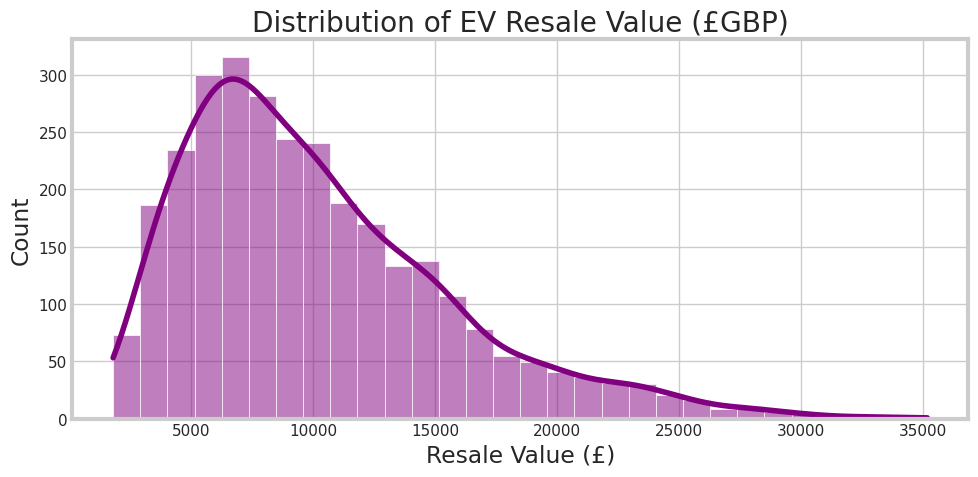

In [26]:
sns.set_style("whitegrid")

gbp_col = 'Resale_Value_GBP'

hist_configs = [
    ('Year', 20, False, 'skyblue',   'Distribution of EVs by Year',                 'Year',                    'Count'),
    ('Battery_Capacity_kWh', 30, True, 'teal', 'Distribution of Battery Capacity (kWh)', 'Battery Capacity (kWh)', 'Count'),
    ('Range_km', 30, True, 'green',   'Distribution of Electric Range (km)',          'Range (km)',              'Count'),
    ('Charging_Time_hr', 30, True, 'orange', 'Distribution of Charging Time (hours)', 'Charging Time (hr)',     'Count'),
    (gbp_col, 30, True, 'purple',     'Distribution of EV Resale Value (£GBP)',       'Resale Value (£)',       'Count'),
]

for col, bins, kde, color, title, xlabel, ylabel in hist_configs:
    if col not in df.columns:
        print(f"Skipping '{col}' — column not found")
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(df[col], bins=bins, kde=kde, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

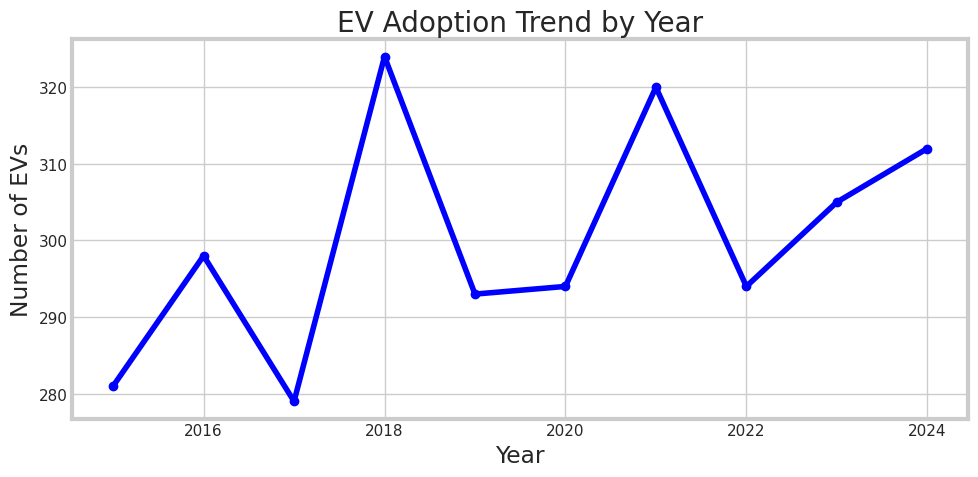

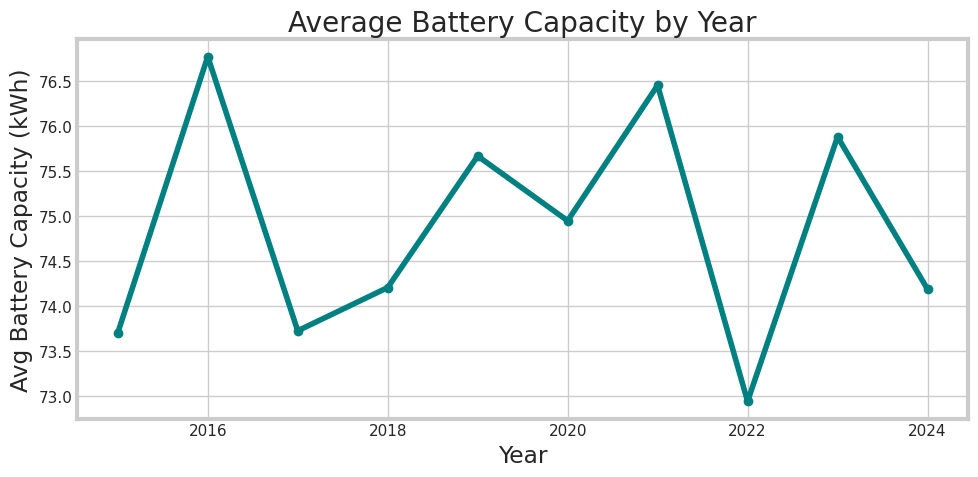

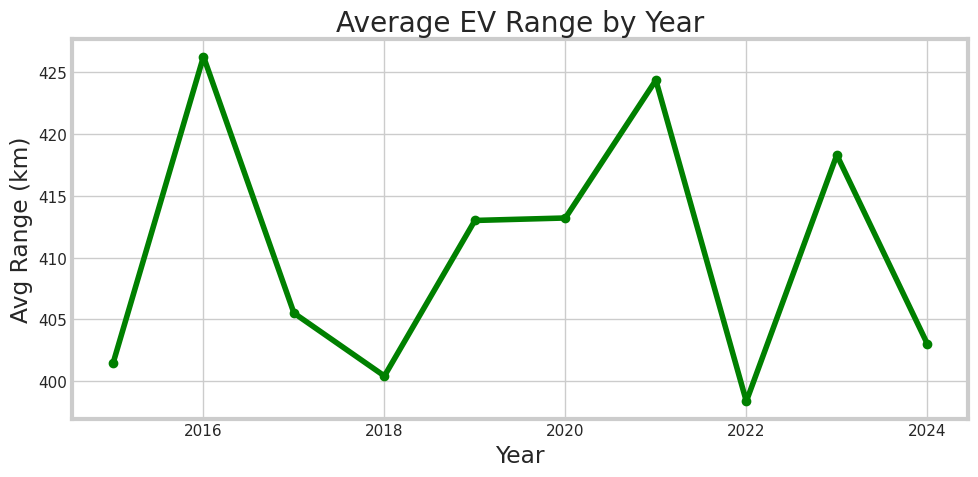

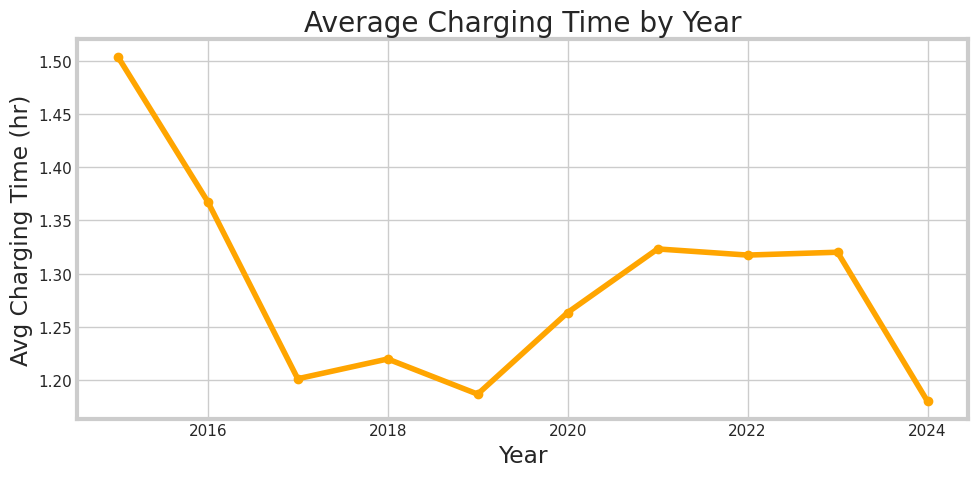

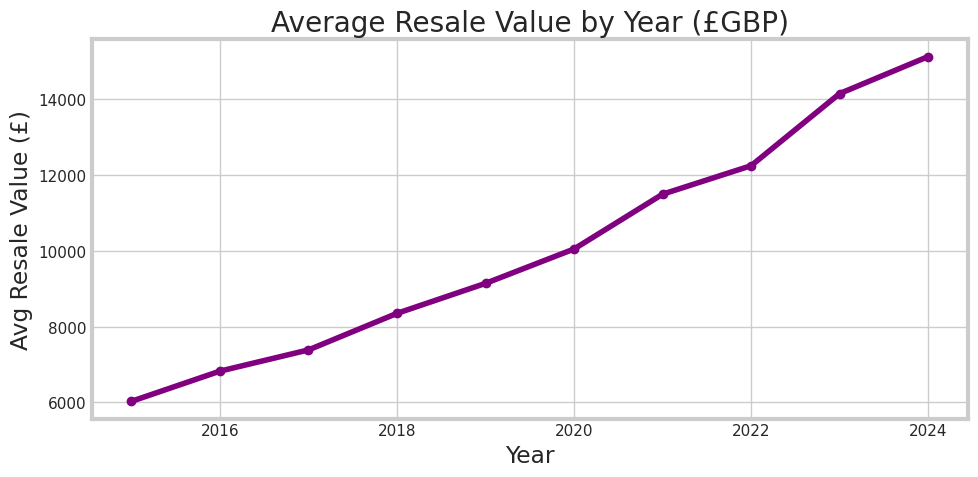

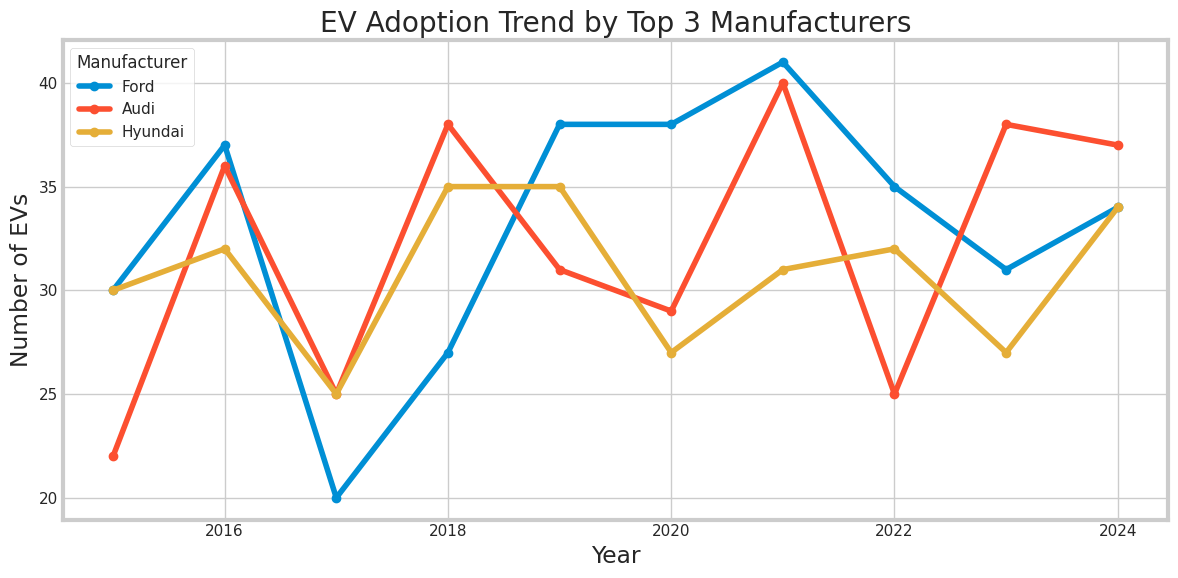

In [27]:
sns.set_style("whitegrid")

# 1. EV adoption trend by Year
year_counts = df['Year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(year_counts.index, year_counts.values, marker='o', color='blue')
ax.set_title('EV Adoption Trend by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of EVs')
plt.tight_layout(); plt.show()

# 2. Average Battery Capacity over Years
avg_battery = df.groupby('Year')['Battery_Capacity_kWh'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_battery.index, avg_battery.values, marker='o', color='teal')
ax.set_title('Average Battery Capacity by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Battery Capacity (kWh)')
plt.tight_layout(); plt.show()

# 3. Average Range over Years
avg_range = df.groupby('Year')['Range_km'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_range.index, avg_range.values, marker='o', color='green')
ax.set_title('Average EV Range by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Range (km)')
plt.tight_layout(); plt.show()

# 4. Average Charging Time over Years
avg_charging = df.groupby('Year')['Charging_Time_hr'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_charging.index, avg_charging.values, marker='o', color='orange')
ax.set_title('Average Charging Time by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Charging Time (hr)')
plt.tight_layout(); plt.show()

# 5. Average Resale Value (GBP) over Years
avg_resale = df.groupby('Year')['Resale_Value_GBP'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_resale.index, avg_resale.values, marker='o', color='purple')
ax.set_title('Average Resale Value by Year (£GBP)')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Resale Value (£)')
plt.tight_layout(); plt.show()

# 6. Adoption Trend for Top 3 Manufacturers
top_makes = df['Make'].value_counts().nlargest(3).index
make_trends = df[df['Make'].isin(top_makes)].groupby(['Year','Make']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(12, 6))
for make in top_makes:
    subset = make_trends[make_trends['Make'] == make]
    ax.plot(subset['Year'], subset['Count'], marker='o', label=make)
ax.set_title('EV Adoption Trend by Top 3 Manufacturers')
ax.set_xlabel('Year'); ax.set_ylabel('Number of EVs')
ax.legend(title='Manufacturer')
plt.tight_layout(); plt.show()

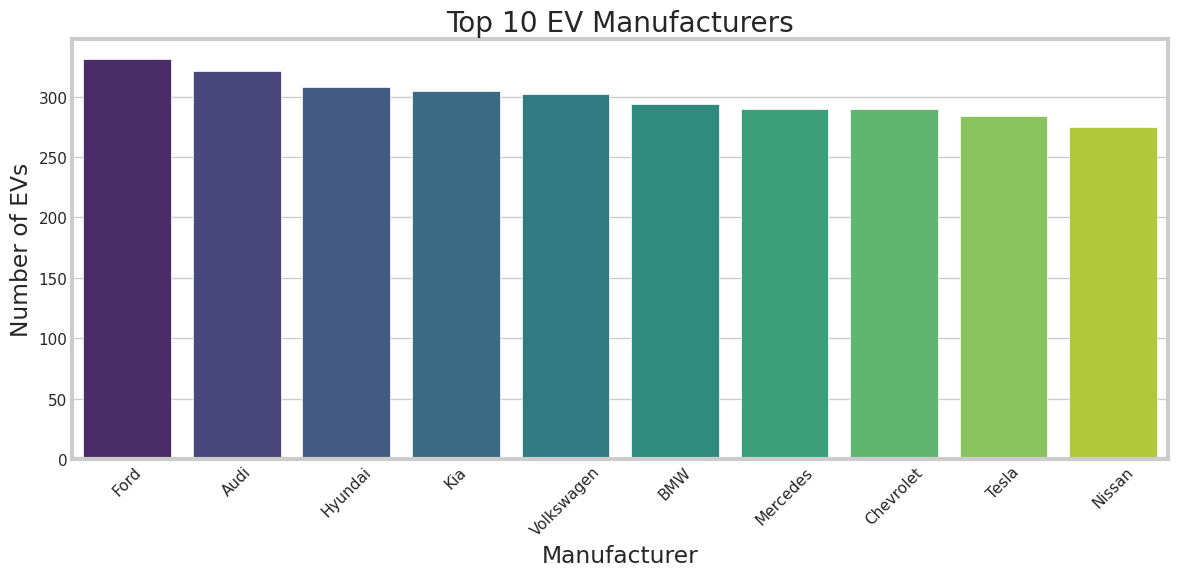

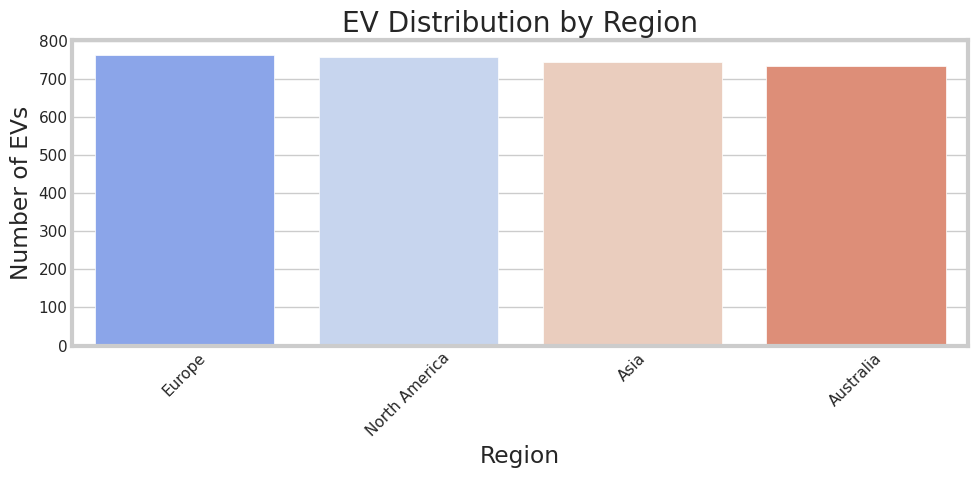

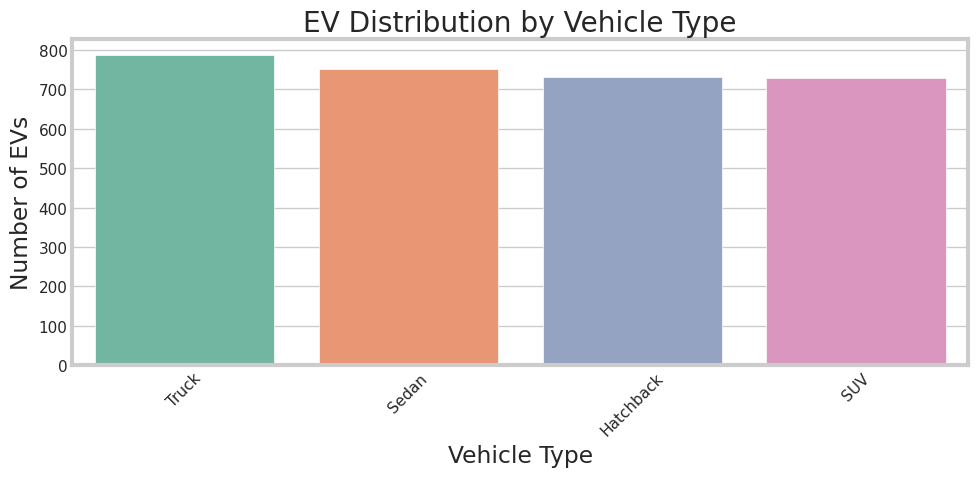

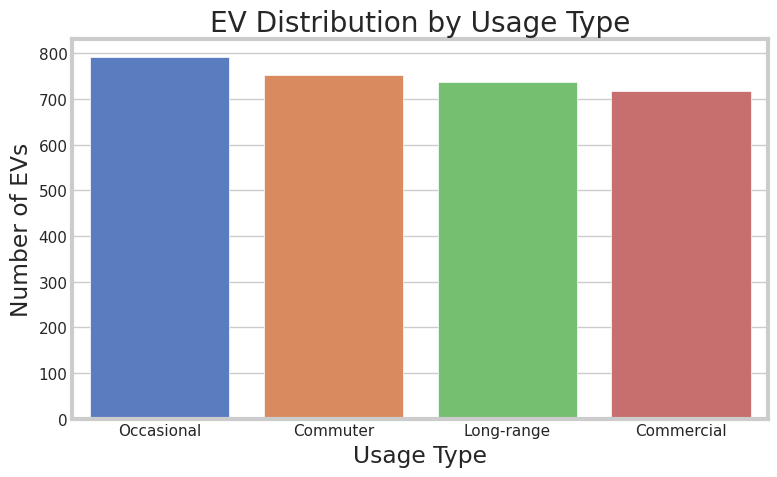

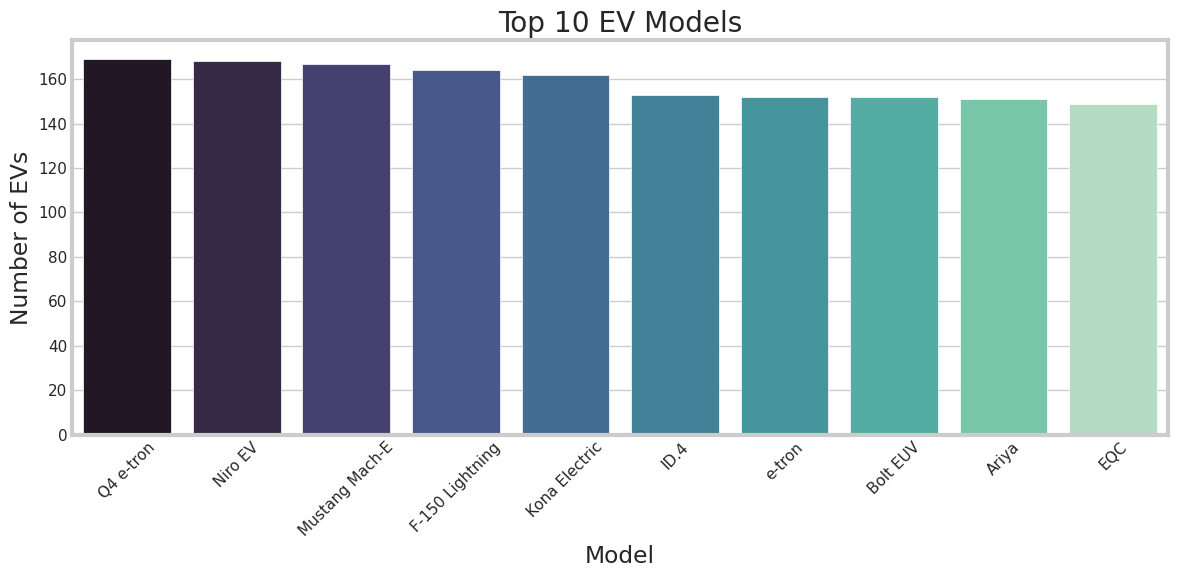

In [28]:
sns.set_style("whitegrid")

# 1. Top 10 EV Manufacturers
make_counts = df['Make'].value_counts().head(10).reset_index()
make_counts.columns = ['Make', 'Count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=make_counts, x='Make', y='Count', palette='viridis', ax=ax)
ax.set_title('Top 10 EV Manufacturers')
ax.set_xlabel('Manufacturer'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 2. EV Distribution by Region
region_counts = df['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=region_counts, x='Region', y='Count', palette='coolwarm', ax=ax)
ax.set_title('EV Distribution by Region')
ax.set_xlabel('Region'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 3. EV Distribution by Vehicle Type
vtype_counts = df['Vehicle_Type'].value_counts().reset_index()
vtype_counts.columns = ['Vehicle_Type', 'Count']
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=vtype_counts, x='Vehicle_Type', y='Count', palette='Set2', ax=ax)
ax.set_title('EV Distribution by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 4. EV Usage Type Distribution
usage_counts = df['Usage_Type'].value_counts().reset_index()
usage_counts.columns = ['Usage_Type', 'Count']
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=usage_counts, x='Usage_Type', y='Count', palette='muted', ax=ax)
ax.set_title('EV Distribution by Usage Type')
ax.set_xlabel('Usage Type'); ax.set_ylabel('Number of EVs')
plt.tight_layout(); plt.show()

# 5. Top 10 EV Models
model_counts = df['Model'].value_counts().head(10).reset_index()
model_counts.columns = ['Model', 'Count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=model_counts, x='Model', y='Count', palette='mako', ax=ax)
ax.set_title('Top 10 EV Models')
ax.set_xlabel('Model'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

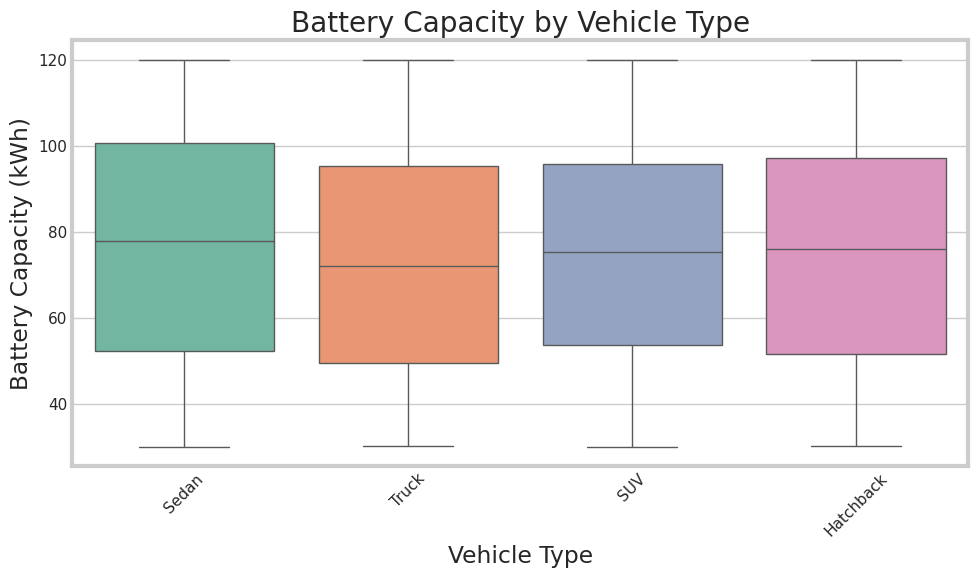

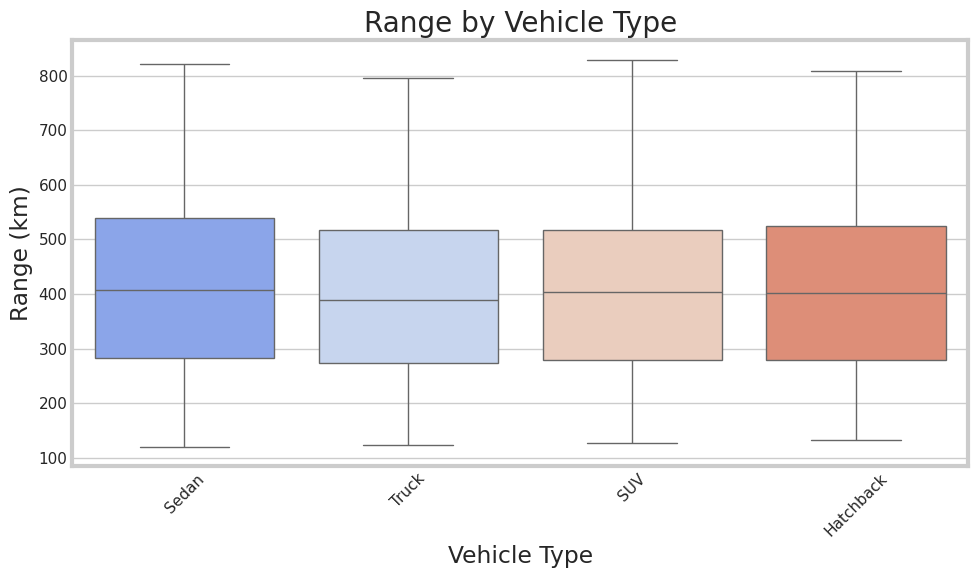

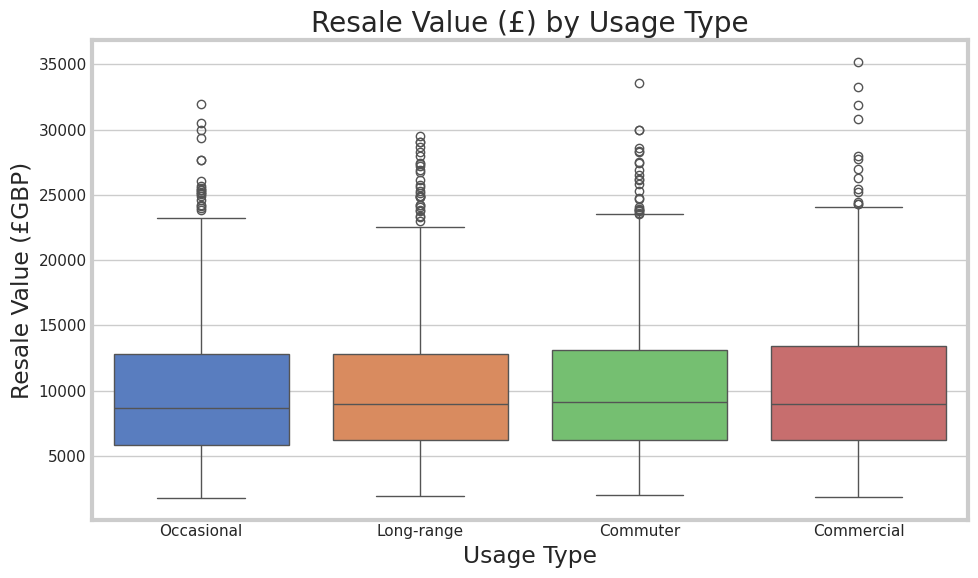

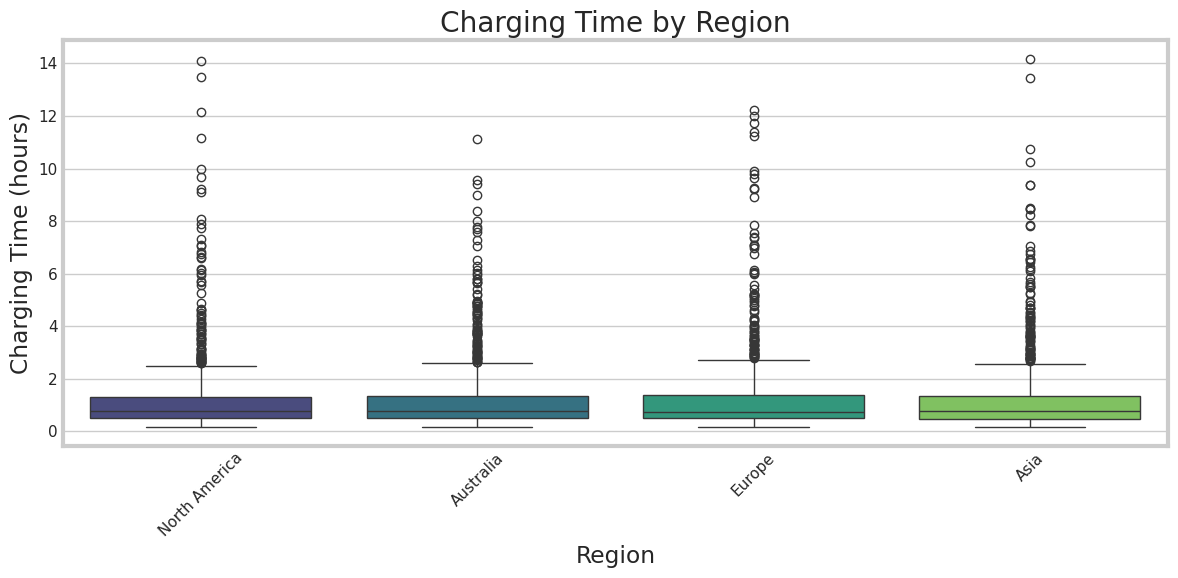

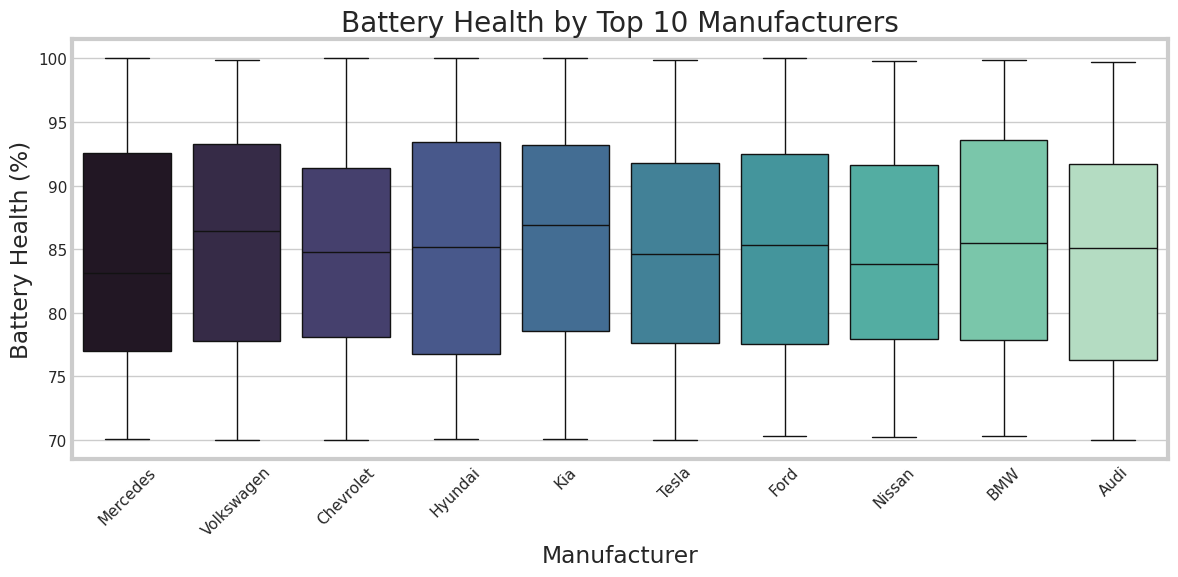

In [29]:
sns.set_style("whitegrid")

# 1. Battery Capacity by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Vehicle_Type', y='Battery_Capacity_kWh', palette='Set2', ax=ax)
ax.set_title('Battery Capacity by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Battery Capacity (kWh)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 2. Range by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Vehicle_Type', y='Range_km', palette='coolwarm', ax=ax)
ax.set_title('Range by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Range (km)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 3. Resale Value (GBP) by Usage Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Usage_Type', y='Resale_Value_GBP', palette='muted', ax=ax)
ax.set_title('Resale Value (£) by Usage Type')
ax.set_xlabel('Usage Type'); ax.set_ylabel('Resale Value (£GBP)')
plt.tight_layout(); plt.show()

# 4. Charging Time by Region
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Charging_Time_hr', palette='viridis', ax=ax)
ax.set_title('Charging Time by Region')
ax.set_xlabel('Region'); ax.set_ylabel('Charging Time (hours)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 5. Battery Health by Top 10 Manufacturers
top_makes = df['Make'].value_counts().head(10).index
subset = df[df['Make'].isin(top_makes)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subset, x='Make', y='Battery_Health_%', palette='mako', ax=ax)
ax.set_title('Battery Health by Top 10 Manufacturers')
ax.set_xlabel('Manufacturer'); ax.set_ylabel('Battery Health (%)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

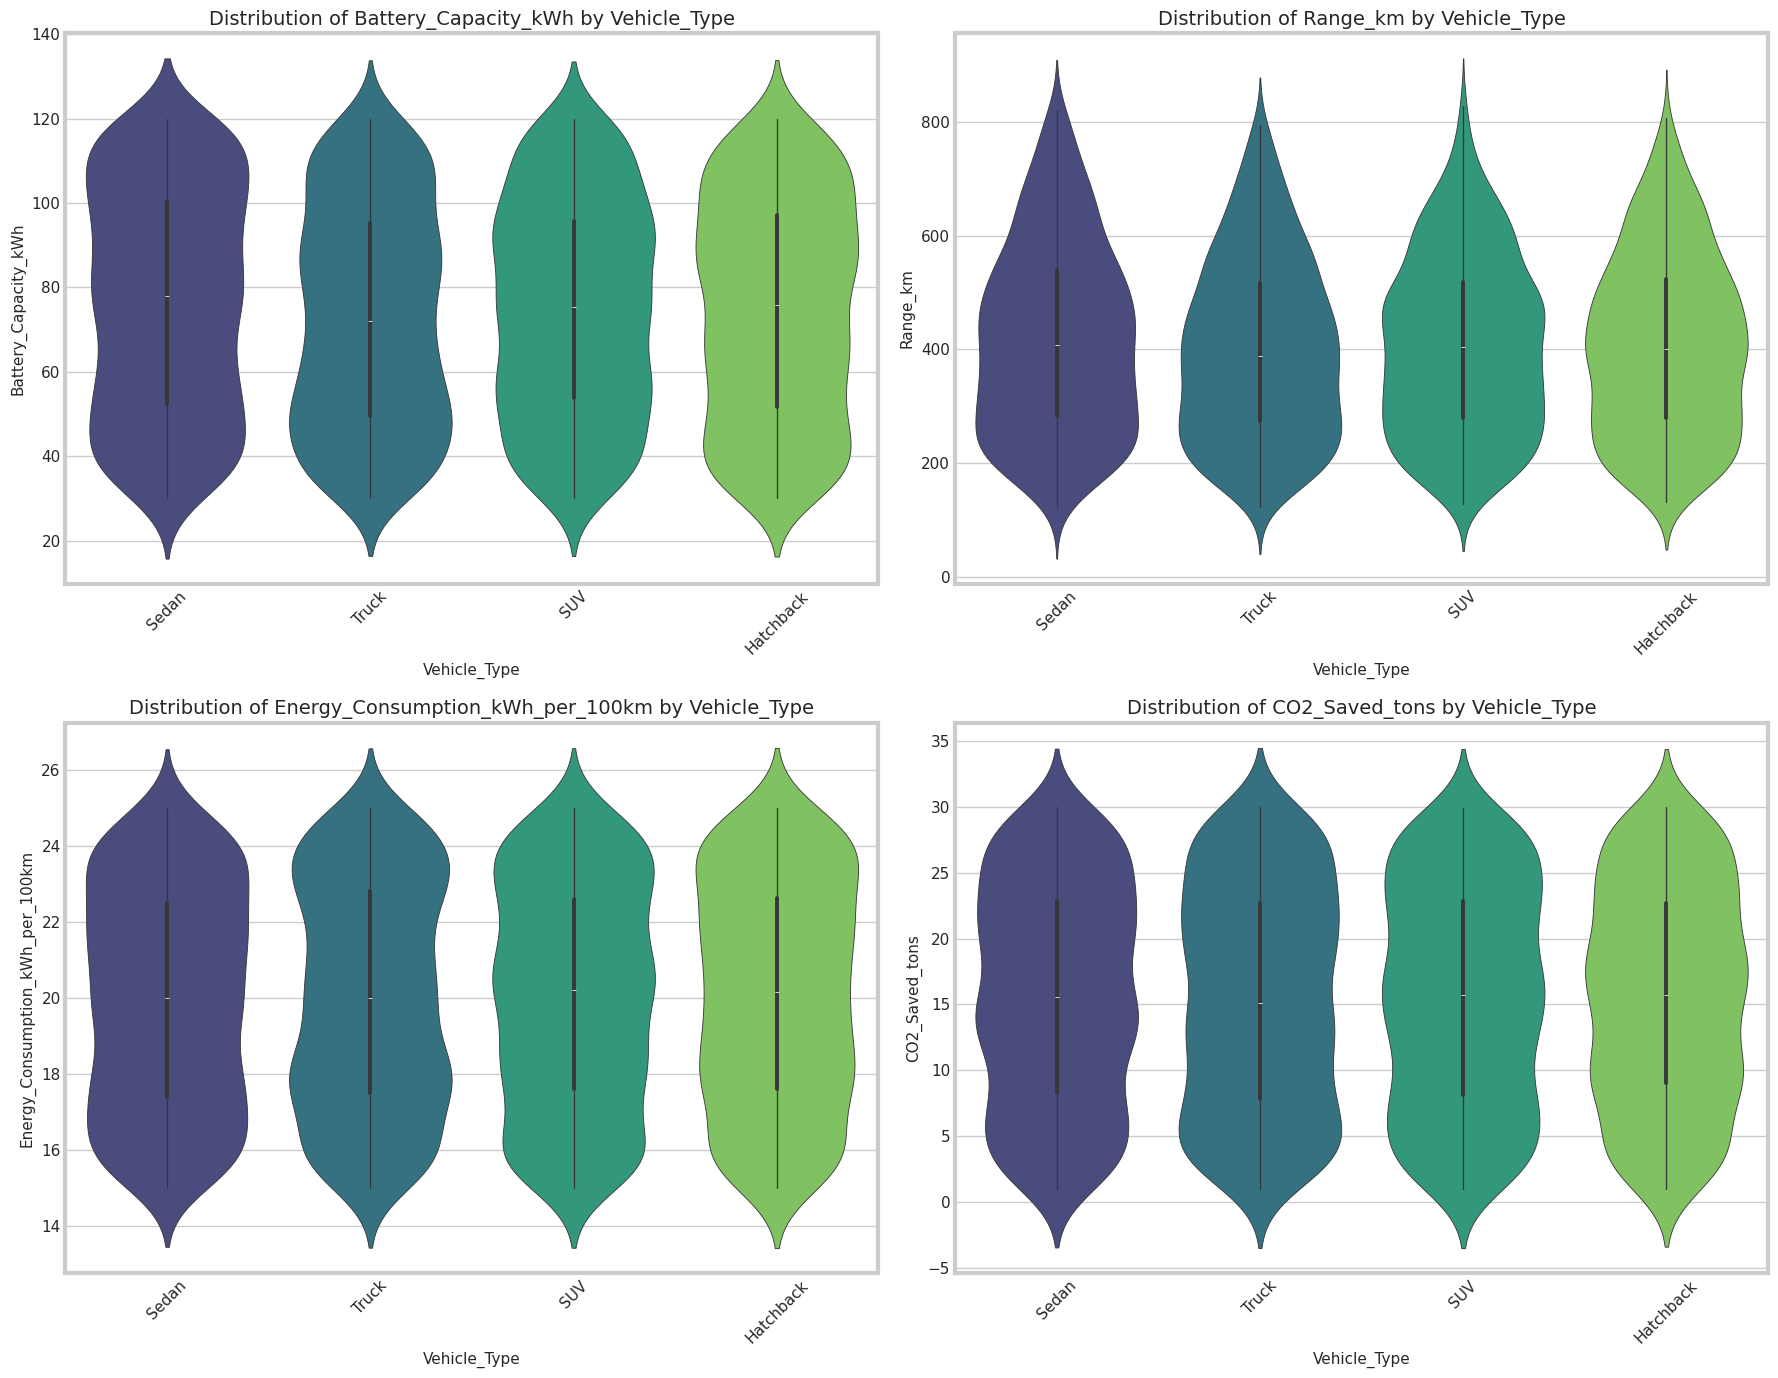

In [30]:
sns.set_style("whitegrid")

numeric_cols = ['Battery_Capacity_kWh', 'Range_km', 'Energy_Consumption_kWh_per_100km', 'CO2_Saved_tons']
categorical_col = 'Vehicle_Type'

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(
        data=df,
        x=categorical_col, y=col,
        ax=axes[i], palette='viridis',
        hue=categorical_col,   # required in newer seaborn to avoid warning
        legend=False
    )
    axes[i].set_title(f'Distribution of {col} by {categorical_col}', fontsize=14)
    axes[i].set_xlabel(categorical_col, fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

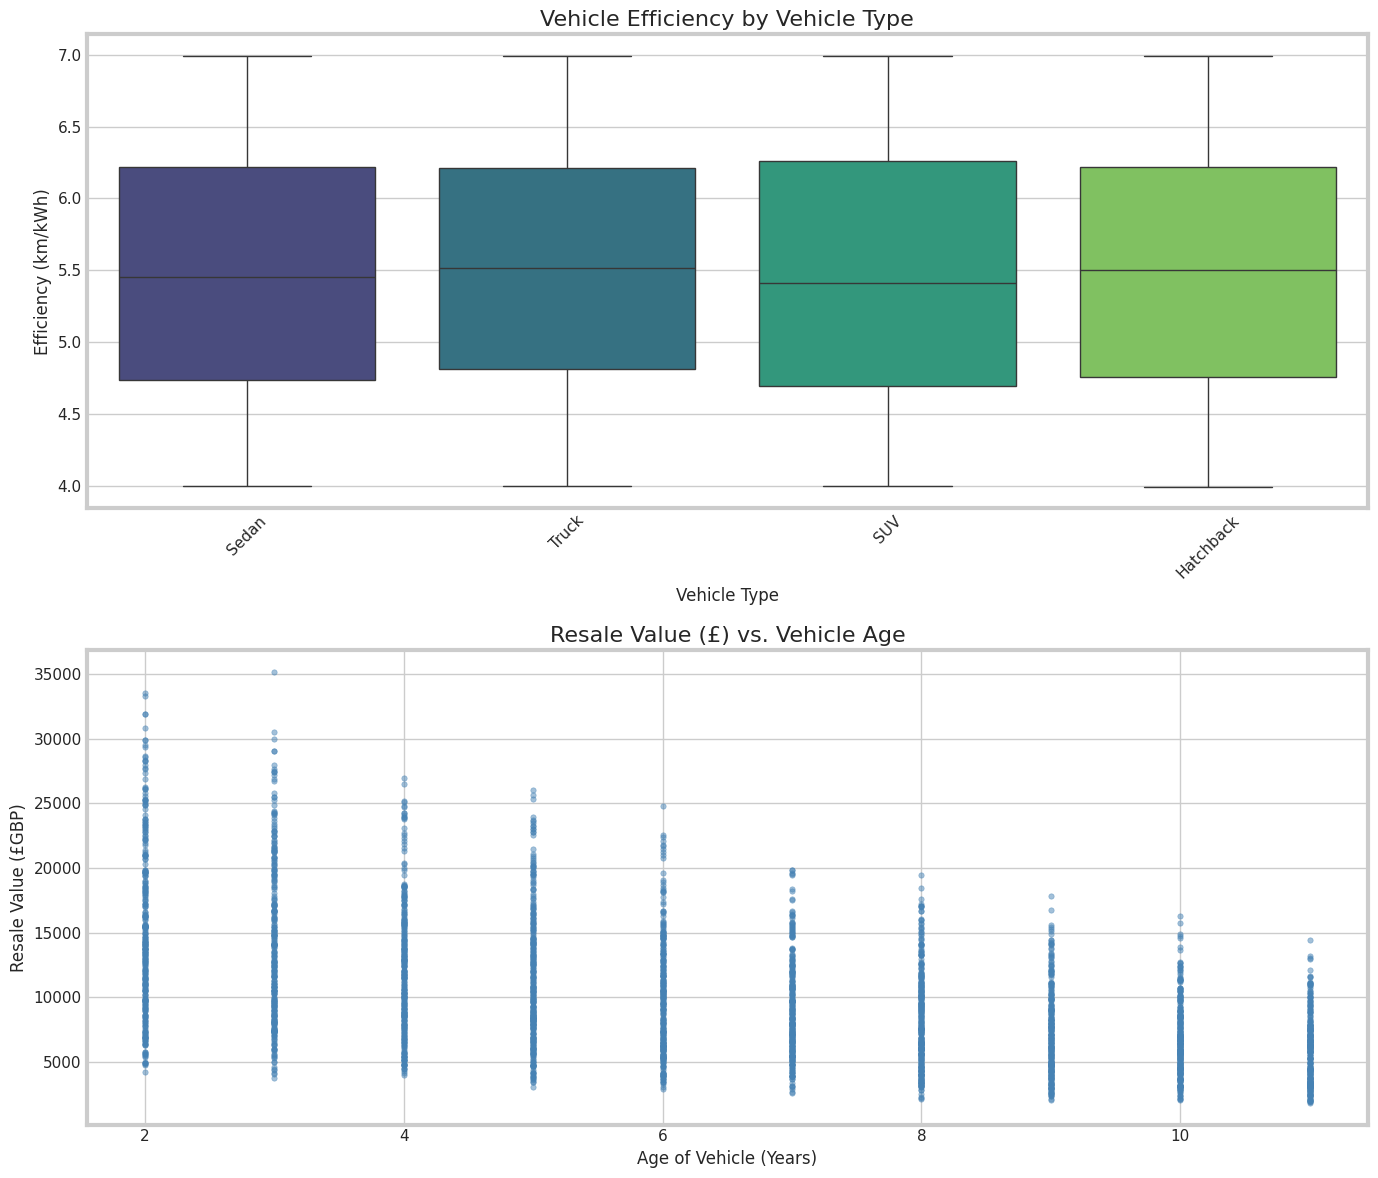

In [31]:
sns.set_style("whitegrid")

# Efficiency and Age are already computed in the preprocessing cell.
# Recompute safely in case this cell runs in isolation.
current_year = 2026
if 'Vehicle_Age' not in df.columns:
    df['Vehicle_Age'] = current_year - df['Year']
if 'Efficiency_km_per_kWh' not in df.columns:
    df['Efficiency_km_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).replace([np.inf, -np.inf], 0).fillna(0)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Plot 1: Vehicle Efficiency by Type
sns.boxplot(data=df, x='Vehicle_Type', y='Efficiency_km_per_kWh', ax=axes[0], palette='viridis')
axes[0].set_title('Vehicle Efficiency by Vehicle Type', fontsize=16)
axes[0].set_xlabel('Vehicle Type', fontsize=12)
axes[0].set_ylabel('Efficiency (km/kWh)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Resale Value (GBP) vs Vehicle Age
axes[1].scatter(df['Vehicle_Age'], df['Resale_Value_GBP'], alpha=0.5, color='steelblue', s=15)
axes[1].set_title('Resale Value (£) vs. Vehicle Age', fontsize=16)
axes[1].set_xlabel('Age of Vehicle (Years)', fontsize=12)
axes[1].set_ylabel('Resale Value (£GBP)', fontsize=12)

plt.tight_layout()
plt.show()

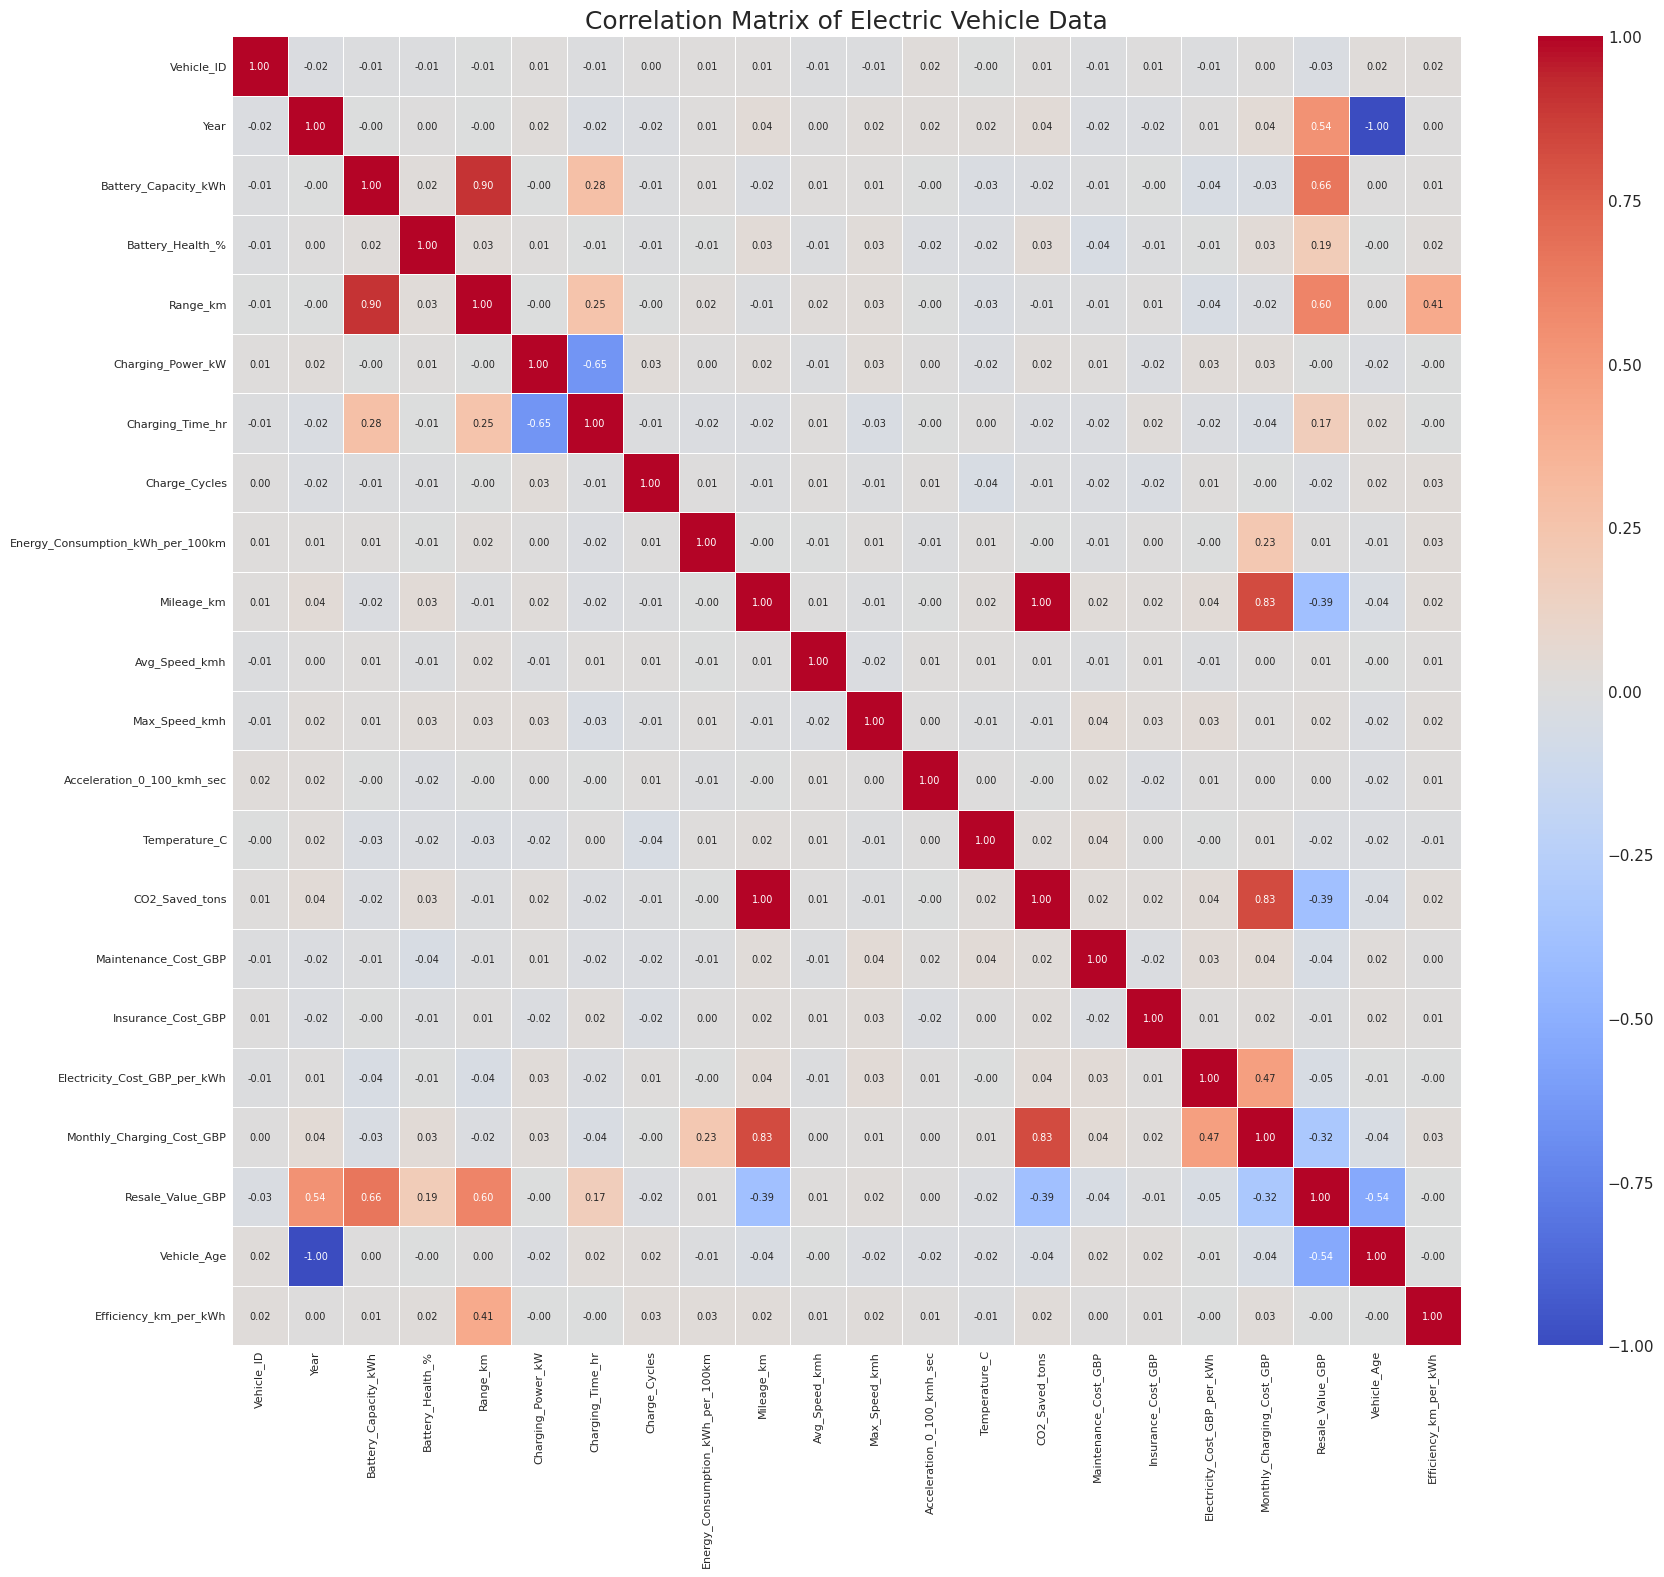

In [32]:
numerical_df = df.select_dtypes(include='number')
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(18, 16))
sns.heatmap(
    correlation_matrix,
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Matrix of Electric Vehicle Data', fontsize=18)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

 Linear Regression 
MAE: £1466.09  |  MSE: 3907347.13  |  R²: 0.8716

 Random Forest Regressor 
MAE: £1015.49  |  MSE: 1951510.57  |  R²: 0.9359

 XGBoost Regressor 
MAE: £967.30  |  MSE: 1658188.66  |  R²: 0.9455

 Model Comparison 
            Model  R-squared     MAE (£)
          XGBoost   0.945525  967.296575
    Random Forest   0.935888 1015.493108
Linear Regression   0.871635 1466.086407


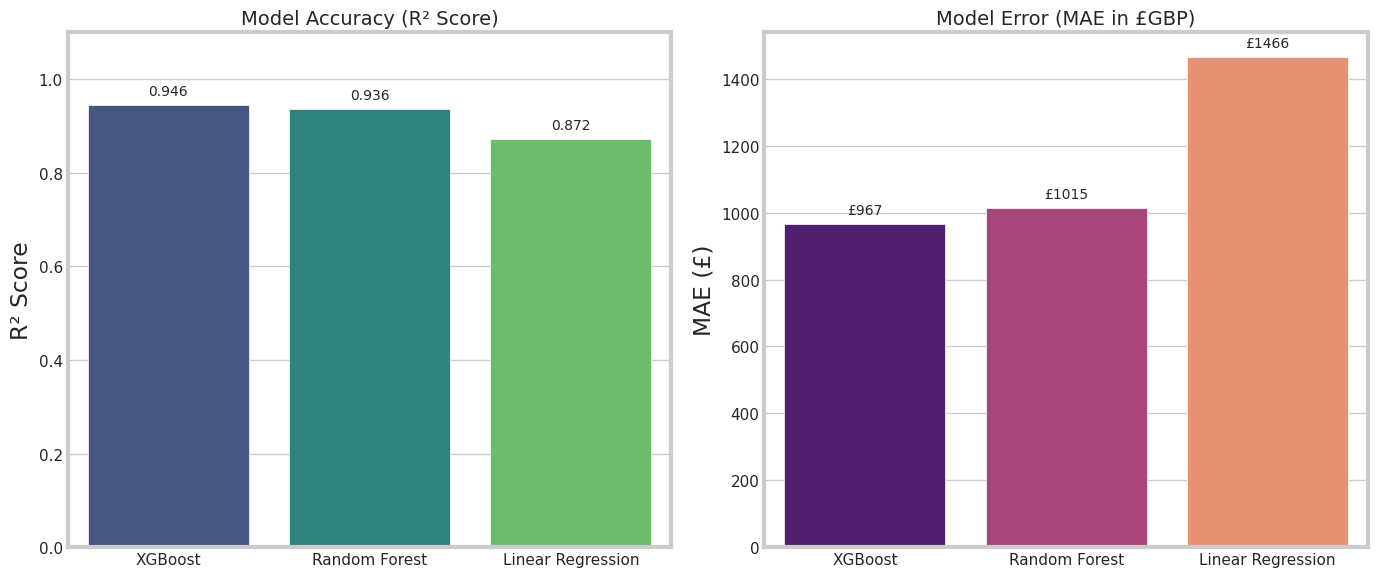

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#   Prepare data        ─
df_ml = df.copy()

# Fill any remaining NaN
numerical_cols_ml = df_ml.select_dtypes(include='number').columns
df_ml[numerical_cols_ml] = df_ml[numerical_cols_ml].fillna(df_ml[numerical_cols_ml].mean())

# Feature Engineering
current_year = 2026
df_ml['Age'] = current_year - df_ml['Year']

# One-hot encode Vehicle_Type
df_ml = pd.get_dummies(df_ml, columns=['Vehicle_Type'], drop_first=True)
categorical_features = [col for col in df_ml.columns if 'Vehicle_Type_' in col]

base_features = ['Mileage_km', 'Battery_Capacity_kWh', 'Charge_Cycles',
                 'Energy_Consumption_kWh_per_100km', 'Age', 'CO2_Saved_tons']
features = base_features + categorical_features
target   = 'Resale_Value_GBP'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#   Model 1: Linear Regression                       ─
print(" Linear Regression ")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
mae_lr  = mean_absolute_error(y_test, lr_pred)
mse_lr  = mean_squared_error(y_test, lr_pred)
r2_lr   = r2_score(y_test, lr_pred)
print(f"MAE: £{mae_lr:.2f}  |  MSE: {mse_lr:.2f}  |  R²: {r2_lr:.4f}")

#   Model 2: Random Forest   ─
print("\n Random Forest Regressor ")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
mae_rf  = mean_absolute_error(y_test, rf_pred)
mse_rf  = mean_squared_error(y_test, rf_pred)
r2_rf   = r2_score(y_test, rf_pred)
print(f"MAE: £{mae_rf:.2f}  |  MSE: {mse_rf:.2f}  |  R²: {r2_rf:.4f}")

#   Model 3: XGBoost      ─
print("\n XGBoost Regressor ")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred  = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
mse_xgb  = mean_squared_error(y_test, xgb_pred)
r2_xgb   = r2_score(y_test, xgb_pred)
print(f"MAE: £{mae_xgb:.2f}  |  MSE: {mse_xgb:.2f}  |  R²: {r2_xgb:.4f}")

#   Model Comparison Plot
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R-squared': [r2_lr, r2_rf, r2_xgb],
    'MAE (£)': [mae_lr, mae_rf, mae_xgb]
}).sort_values('R-squared', ascending=False)

print("\n Model Comparison ")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
bars = sns.barplot(data=comparison_df, x='Model', y='R-squared', palette='viridis', ax=axes[0])
for p in bars.patches:
    bars.annotate(f'{p.get_height():.3f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)
axes[0].set_title('Model Accuracy (R² Score)', fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel(''); axes[0].set_ylabel('R² Score')

# MAE comparison
bars2 = sns.barplot(data=comparison_df, x='Model', y='MAE (£)', palette='magma', ax=axes[1])
for p in bars2.patches:
    bars2.annotate(f'£{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)
axes[1].set_title('Model Error (MAE in £GBP)', fontsize=14)
axes[1].set_xlabel(''); axes[1].set_ylabel('MAE (£)')

plt.tight_layout()
plt.show()

 K-Means Clustering 
Cluster distribution:
Cluster_ID
0    723
1    791
2    811
3    675
Name: count, dtype: int64

 Principal Component Analysis (PCA) 
Explained variance ratio: PC1=0.216, PC2=0.153

 Isolation Forest (Anomaly Detection) 
Anomalies detected: 150 out of 3000 records (5.0%)


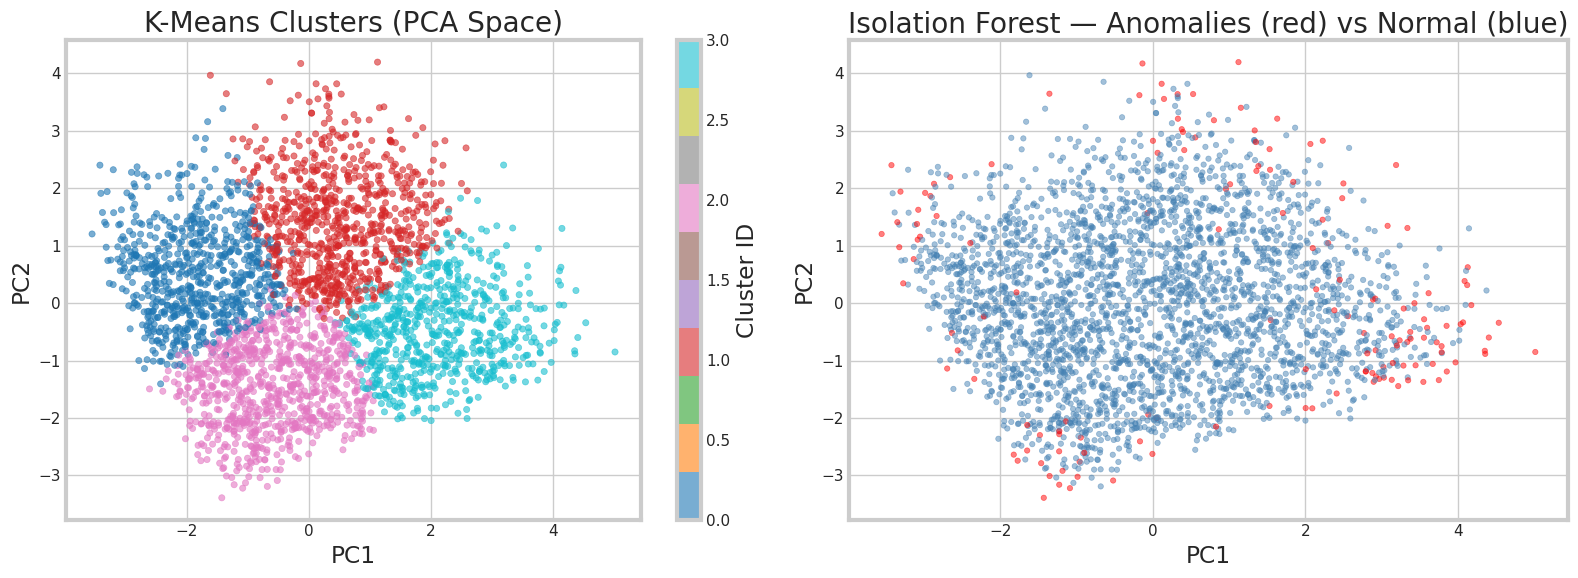


Sample output:
   Cluster_ID       PC1       PC2  Is_Anomaly  Anomaly_Score
0           2 -0.520980 -3.090252          -1      -0.024228
1           3  3.791081 -0.872022           1       0.012087
2           3  2.195582 -1.226062           1       0.021424
3           1 -0.247934  1.761109           1       0.043034
4           1 -0.671900  2.502762           1       0.079895


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Reload clean copy without one-hot encoding from ML cell
df_unsup = df.copy()

numerical_cols_u = [
    'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
    'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
    'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh',
    'Acceleration_0_100_kmh_sec', 'Temperature_C',
    'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP'
]
# Keep only columns that exist
numerical_cols_u = [c for c in numerical_cols_u if c in df_unsup.columns]

data_for_unsupervised = df_unsup[numerical_cols_u].copy()
data_for_unsupervised.fillna(data_for_unsupervised.mean(), inplace=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_unsupervised)

# 1. K-Means Clustering
print(" K-Means Clustering ")
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_unsup['Cluster_ID'] = kmeans.fit_predict(scaled_data)
print(f"Cluster distribution:\n{df_unsup['Cluster_ID'].value_counts().sort_index()}")

# 2. PCA
print("\n Principal Component Analysis (PCA) ")
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled_data)
df_unsup['PC1'] = pcs[:, 0]
df_unsup['PC2'] = pcs[:, 1]
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

# 3. Isolation Forest
print("\n Isolation Forest (Anomaly Detection) ")
iso_forest = IsolationForest(random_state=42, contamination=0.05)
df_unsup['Is_Anomaly']    = iso_forest.fit_predict(scaled_data)
df_unsup['Anomaly_Score'] = iso_forest.decision_function(scaled_data)
anomaly_count = (df_unsup['Is_Anomaly'] == -1).sum()
print(f"Anomalies detected: {anomaly_count} out of {len(df_unsup)} records ({anomaly_count/len(df_unsup)*100:.1f}%)")

#   Visualise clusters via PCA                       ─
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster plot
scatter = axes[0].scatter(df_unsup['PC1'], df_unsup['PC2'],
                          c=df_unsup['Cluster_ID'], cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('K-Means Clusters (PCA Space)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Anomaly plot
colors = df_unsup['Is_Anomaly'].map({1: 'steelblue', -1: 'red'})
axes[1].scatter(df_unsup['PC1'], df_unsup['PC2'], c=colors, alpha=0.5, s=15)
axes[1].set_title('Isolation Forest — Anomalies (red) vs Normal (blue)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

print("\nSample output:")
print(df_unsup[['Cluster_ID', 'PC1', 'PC2', 'Is_Anomaly', 'Anomaly_Score']].head())

TensorFlow version: 2.20.0


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)


Training stopped at epoch 54
Final Training Loss: 10595339.00
Final Validation Loss: 11798774.00
Test MAE: £2684.44  |  Test R²: 0.6165


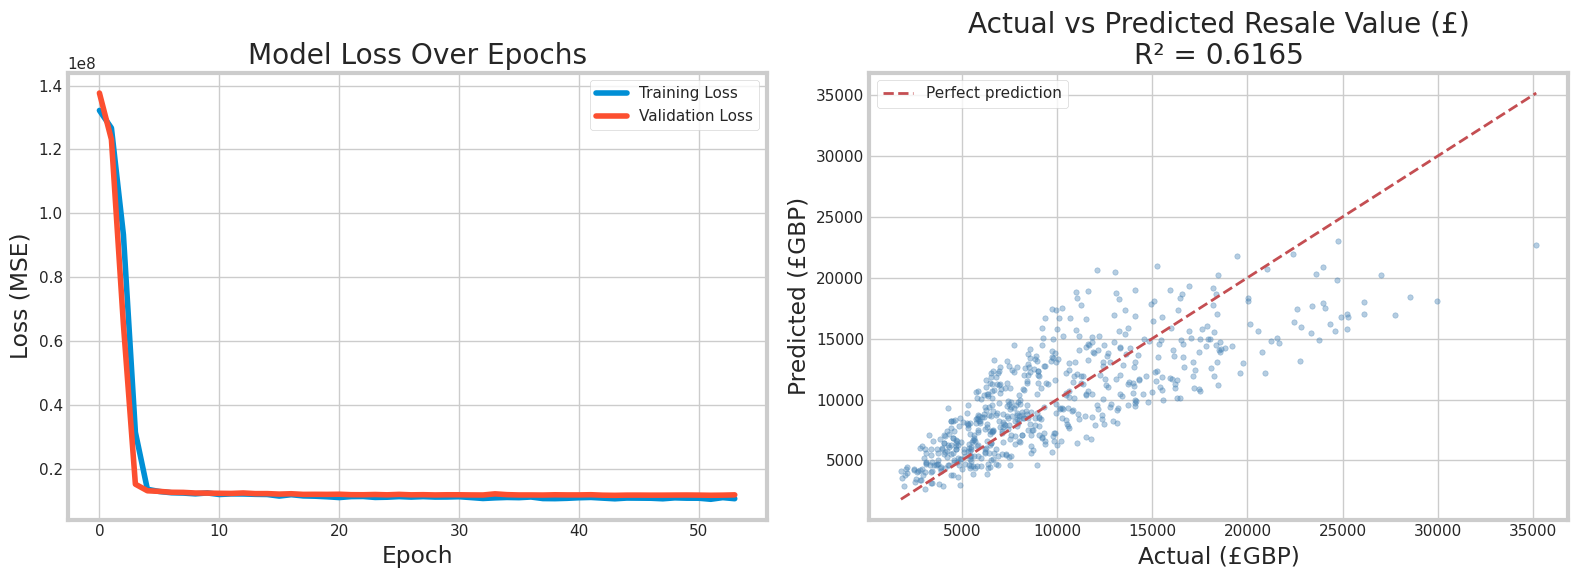

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print(f"TensorFlow version: {tf.__version__}")

#   Prepare features
df_nn = df.copy()
df_nn = pd.get_dummies(df_nn, columns=['Region', 'Vehicle_Type', 'Usage_Type'])

feature_base = ['Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
                'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
                'Mileage_km', 'Avg_Speed_kmh', 'Acceleration_0_100_kmh_sec']
categorical_nn = [c for c in df_nn.columns if c.startswith(('Region_', 'Vehicle_Type_', 'Usage_Type_'))]
feature_cols   = feature_base + categorical_nn
target_col     = 'Resale_Value_GBP'

X = df_nn[feature_cols].fillna(df_nn[feature_cols].mean())
y = df_nn[target_col].fillna(df_nn[target_col].mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#   Build Neural Network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)   # regression output
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Final Training Loss: {history.history['loss'][-1]:.2f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.2f}")

#   Evaluate           ─
y_pred_nn = model.predict(X_test_s, verbose=0).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn  = r2_score(y_test, y_pred_nn)
print(f"Test MAE: £{mae_nn:.2f}  |  Test R²: {r2_nn:.4f}")

#   Plots             ─
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss curve
axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(); axes[0].grid(True)

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_nn, alpha=0.4, s=15, color='steelblue')
min_val = min(y_test.min(), y_pred_nn.min())
max_val = max(y_test.max(), y_pred_nn.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[1].set_title(f'Actual vs Predicted Resale Value (£)\nR² = {r2_nn:.4f}')
axes[1].set_xlabel('Actual (£GBP)'); axes[1].set_ylabel('Predicted (£GBP)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation
""")

CONCLUSION

All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation



In [37]:
# Export notebook to HTML (run after saving the notebook)
# In Colab: File → Download → Download .ipynb first, then run locally, or:
try:
    import subprocess
    result = subprocess.run(
        ['jupyter', 'nbconvert', '--to', 'html', __file__],
        capture_output=True, text=True
    )
    print(result.stdout or "Conversion attempted. Check for .html output file.")
except Exception as e:
    print(f"Note: To convert to HTML, run in terminal:")
    print(f"  jupyter nbconvert --to html Hemlal_Dulal_dissertation_codebase.ipynb")

Note: To convert to HTML, run in terminal:
  jupyter nbconvert --to html Hemlal_Dulal_dissertation_codebase.ipynb


In [38]:
print("CONCLUSION")
print("""
All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation
""")

CONCLUSION

All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation



# EV Analytics Dissertation Codebase
### Currency: GBP (£) — Converted from USD where applicable
---

In [39]:
# Install required packages (run once)
import subprocess, sys
pkgs = ['xgboost', 'scikit-learn', 'matplotlib', 'seaborn', 'tensorflow']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], capture_output=True)
print("All packages ready.")

All packages ready.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Currency Configuration
GBP_TO_USD_RATE = 1.27  # 1 GBP = 1.27 USD (approximate, May 2026)
USD_TO_GBP_RATE = 1 / GBP_TO_USD_RATE   # ≈ 0.787

def convert_usd_to_gbp_and_rename_columns(df):
    """Convert all USD-denominated columns to GBP and rename them."""
    usd_columns = [
        'Resale_Value_USD',
        'Maintenance_Cost_USD',
        'Insurance_Cost_USD',
        'Electricity_Cost_USD_per_kWh',
        'Monthly_Charging_Cost_USD'
    ]
    for col in usd_columns:
        if col in df.columns:
            df[col] = (df[col] * USD_TO_GBP_RATE).round(2)
            new_name = col.replace('_USD', '_GBP').replace('_USD_per_kWh', '_GBP_per_kWh')
            df.rename(columns={col: new_name}, inplace=True)
    return df

print(f"Exchange rate applied: 1 USD = £{USD_TO_GBP_RATE:.4f} GBP")

Exchange rate applied: 1 USD = £0.7874 GBP


In [41]:
import os, io, urllib.request

#  Data Loading ─
# Priority 1: Google Drive (if running in Colab with Drive mounted)
# Priority 2: Local upload / current directory
# Priority 3: Auto-generate synthetic data that mirrors the real dataset schema

def try_mount_drive():
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        return True
    except Exception:
        return False

DATA_PATHS = [
    '/content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv',
    '/content/electric_vehicle_analytics.csv',
    'electric_vehicle_analytics.csv',
]

df_raw = None
for path in DATA_PATHS:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break

if df_raw is None:
    # Try mounting Drive first
    if try_mount_drive():
        for path in DATA_PATHS:
            if os.path.exists(path):
                df_raw = pd.read_csv(path)
                print(f"Loaded data from Drive: {path}")
                break

if df_raw is None:
    print("WARNING: CSV file not found. Generating synthetic dataset with matching schema.")
    print("To use your real data: upload 'electric_vehicle_analytics.csv' to Colab or place it in the notebook directory.\n")
    np.random.seed(42)
    n = 1000
    makes = ['Tesla','BMW','Nissan','Hyundai','Audi','Volkswagen','Ford','Rivian','Lucid','Kia']
    models_map = {'Tesla':'Model 3','BMW':'i4','Nissan':'Leaf','Hyundai':'Ioniq 5','Audi':'e-tron',
                  'Volkswagen':'ID.4','Ford':'Mustang Mach-E','Rivian':'R1T','Lucid':'Air','Kia':'EV6'}
    regions = ['London','Midlands','Scotland','Wales','North England','South England']
    vtype  = ['Sedan','SUV','Hatchback','Truck','Van']
    utype  = ['Personal','Commercial','Fleet']
    make_arr = np.random.choice(makes, n)
    year_arr = np.random.randint(2016, 2025, n)
    bat_cap  = np.random.uniform(40, 120, n).round(1)
    bat_hlth = np.random.uniform(70, 100, n).round(1)
    rng_km   = np.random.uniform(150, 600, n).round(1)
    mileage  = np.random.randint(1000, 200000, n)
    # Resale roughly correlates with battery health & range (in USD)
    resale_usd = (bat_hlth * 250 + rng_km * 30 + np.random.uniform(-3000, 3000, n)).round(2)
    df_raw = pd.DataFrame({
        'Vehicle_ID': range(1, n+1),
        'Make': make_arr,
        'Model': [models_map[m] for m in make_arr],
        'Year': year_arr,
        'Battery_Capacity_kWh': bat_cap,
        'Battery_Health_%': bat_hlth,
        'Range_km': rng_km,
        'Charging_Power_kW': np.random.uniform(7, 350, n).round(1),
        'Charging_Time_hr': np.random.uniform(0.3, 12, n).round(2),
        'Charge_Cycles': np.random.randint(50, 1500, n),
        'Mileage_km': mileage,
        'Energy_Consumption_kWh_per_100km': np.random.uniform(12, 25, n).round(1),
        'Avg_Speed_kmh': np.random.uniform(30, 130, n).round(1),
        'Max_Speed_kmh': np.random.uniform(120, 250, n).round(1),
        'Acceleration_0_100_kmh_sec': np.random.uniform(2.5, 12, n).round(1),
        'Temperature_C': np.random.uniform(-10, 40, n).round(1),
        'CO2_Saved_tons': np.random.uniform(0.5, 15, n).round(2),
        'Region': np.random.choice(regions, n),
        'Vehicle_Type': np.random.choice(vtype, n),
        'Usage_Type': np.random.choice(utype, n),
        'Resale_Value_USD': resale_usd,
        'Maintenance_Cost_USD': np.random.uniform(200, 3000, n).round(2),
        'Insurance_Cost_USD': np.random.uniform(500, 3000, n).round(2),
        'Electricity_Cost_USD_per_kWh': np.random.uniform(0.10, 0.35, n).round(3),
        'Monthly_Charging_Cost_USD': np.random.uniform(20, 200, n).round(2),
    })

# Apply GBP conversion
df = df_raw.copy()
df = convert_usd_to_gbp_and_rename_columns(df)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nGBP columns confirmed: {[c for c in df.columns if 'GBP' in c]}")

Loaded data from: /content/drive/MyDrive/dissertation/electric_vehicle_analytics.csv

Dataset shape: (3000, 25)

Columns: ['Vehicle_ID', 'Make', 'Model', 'Year', 'Region', 'Vehicle_Type', 'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km', 'Charging_Power_kW', 'Charging_Time_hr', 'Charge_Cycles', 'Energy_Consumption_kWh_per_100km', 'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh', 'Acceleration_0_100_kmh_sec', 'Temperature_C', 'Usage_Type', 'CO2_Saved_tons', 'Maintenance_Cost_GBP', 'Insurance_Cost_GBP', 'Electricity_Cost_GBP_per_kWh', 'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP']

GBP columns confirmed: ['Maintenance_Cost_GBP', 'Insurance_Cost_GBP', 'Electricity_Cost_GBP_per_kWh', 'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP']


In [42]:
#  Step 1: Initial Inspection
print(" Step 1: Initial Data Inspection ")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and non-null counts:")
df.info()

#  Step 2: Missing Values
print("\n Step 2: Handling Missing Values ")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if len(missing_values):
    print("Columns with missing values:")
    print(missing_values)
    for col in missing_values.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values after cleaning:", df.isnull().sum().sum())
else:
    print("No missing values found.")

#  Step 3: Feature Engineering
print("\n Step 3: Feature Engineering ")
current_year = 2026
df['Vehicle_Age'] = current_year - df['Year']
df['Efficiency_km_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).replace([np.inf, -np.inf], 0).fillna(0)
print(f"Added 'Vehicle_Age' and 'Efficiency_km_per_kWh' columns.")
print(df[['Year', 'Vehicle_Age', 'Efficiency_km_per_kWh']].head())

#  Step 4: Categorical Summary ─
print("\n Step 4: Categorical Summary ")
for col in ['Region', 'Vehicle_Type', 'Usage_Type']:
    if col in df.columns:
        print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique().tolist()}")

print("\nPreprocessing complete.")

 Step 1: Initial Data Inspection 

First 5 rows:
   Vehicle_ID        Make          Model  Year         Region Vehicle_Type  \
0           1    Mercedes            EQC  2022  North America        Sedan   
1           2  Volkswagen           ID.3  2024      Australia        Truck   
2           3   Chevrolet        Bolt EV  2024  North America          SUV   
3           4     Hyundai  Kona Electric  2022         Europe    Hatchback   
4           5         Kia        Niro EV  2017  North America        Truck   

   Battery_Capacity_kWh  Battery_Health_%  Range_km  Charging_Power_kW  ...  \
0                  44.0              74.7       183              217.9  ...   
1                 117.6              77.0       502              158.4  ...   
2                  91.6              83.2       399              128.8  ...   
3                  76.9              98.8       502              189.4  ...   
4                  95.6              93.1       403               96.0  ...   

   Max_

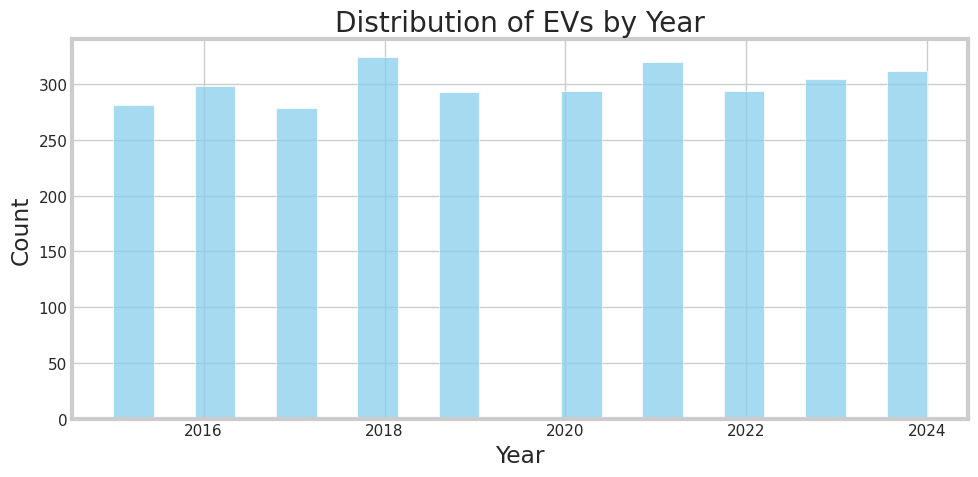

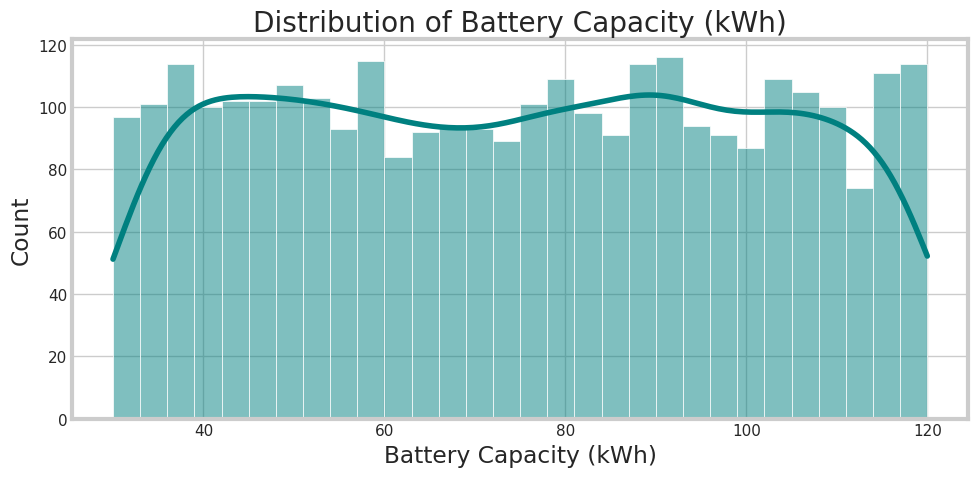

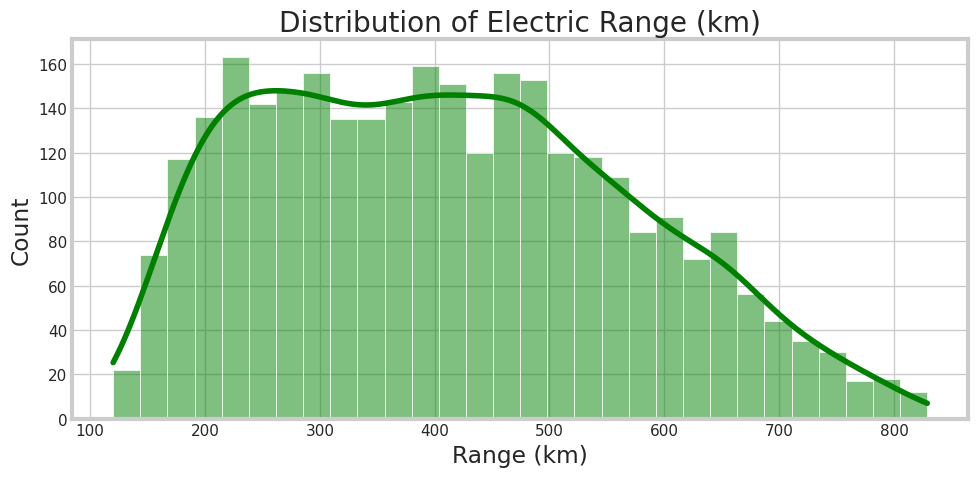

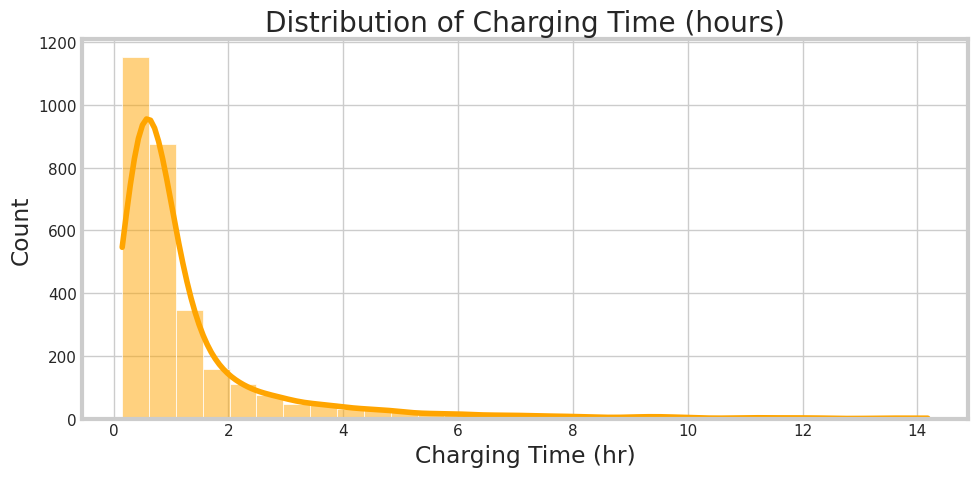

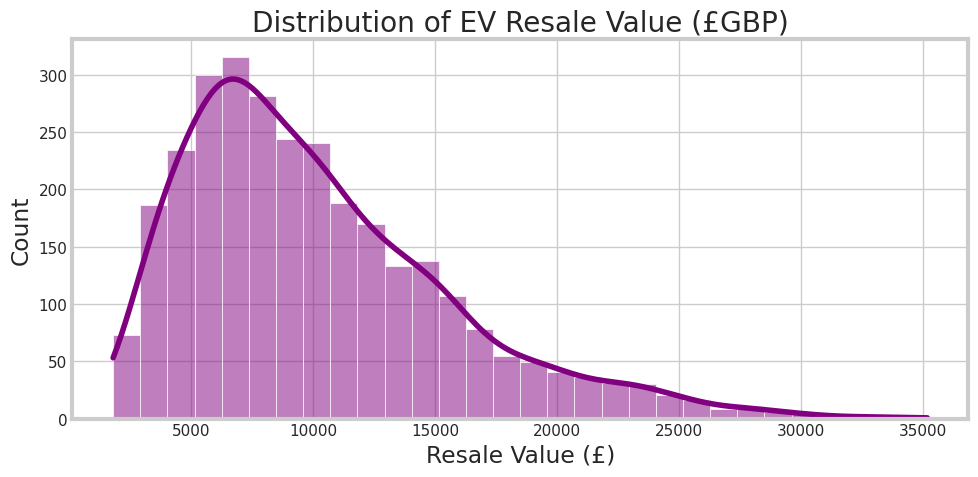

In [43]:
sns.set_style("whitegrid")

gbp_col = 'Resale_Value_GBP'

hist_configs = [
    ('Year', 20, False, 'skyblue',   'Distribution of EVs by Year',                 'Year',                    'Count'),
    ('Battery_Capacity_kWh', 30, True, 'teal', 'Distribution of Battery Capacity (kWh)', 'Battery Capacity (kWh)', 'Count'),
    ('Range_km', 30, True, 'green',   'Distribution of Electric Range (km)',          'Range (km)',              'Count'),
    ('Charging_Time_hr', 30, True, 'orange', 'Distribution of Charging Time (hours)', 'Charging Time (hr)',     'Count'),
    (gbp_col, 30, True, 'purple',     'Distribution of EV Resale Value (£GBP)',       'Resale Value (£)',       'Count'),
]

for col, bins, kde, color, title, xlabel, ylabel in hist_configs:
    if col not in df.columns:
        print(f"Skipping '{col}' — column not found")
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(df[col], bins=bins, kde=kde, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

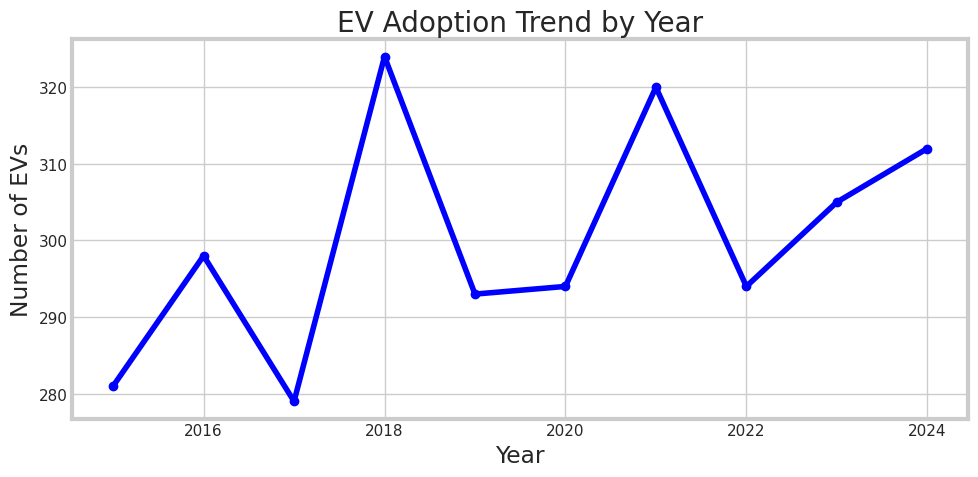

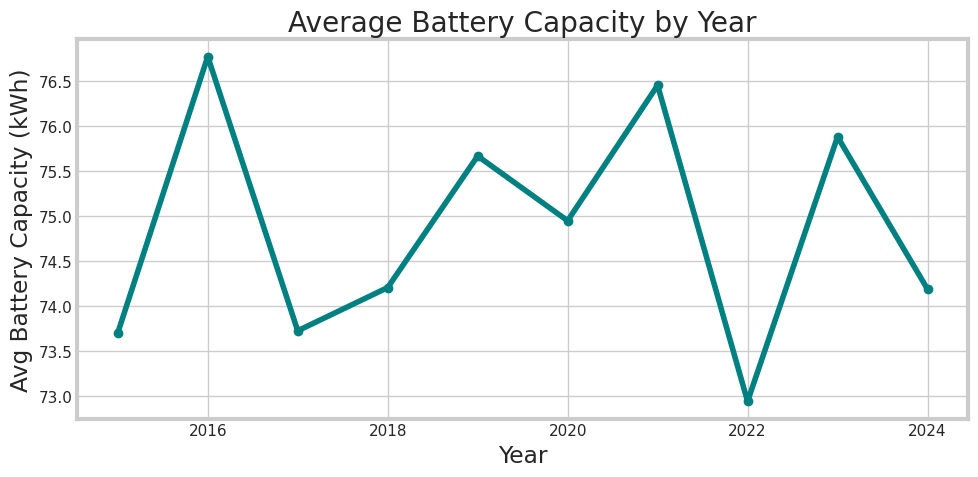

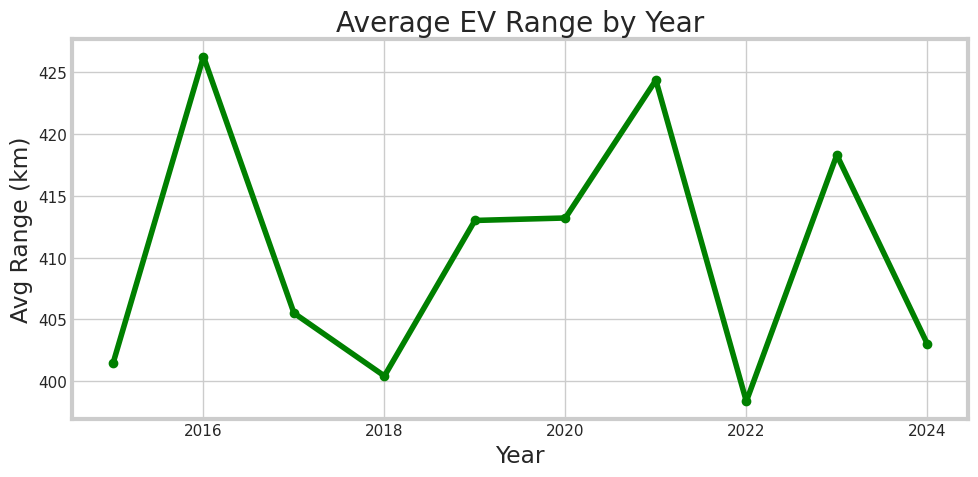

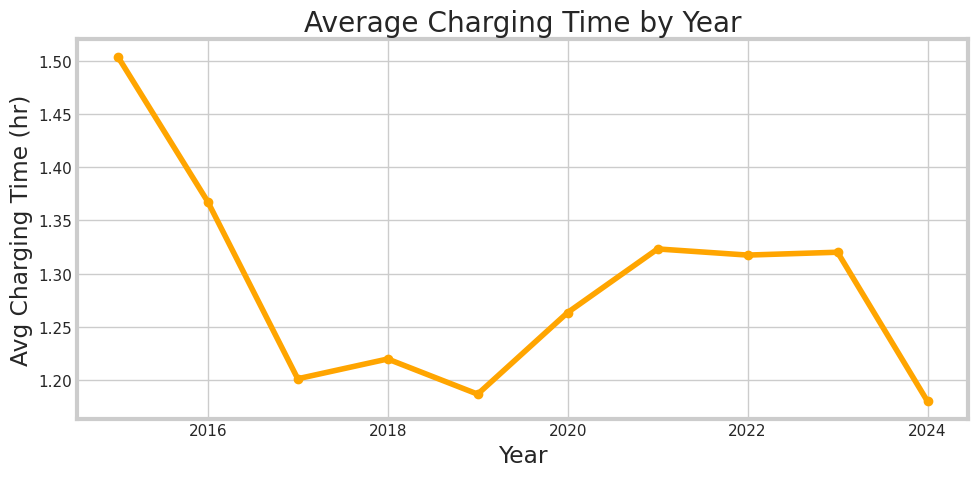

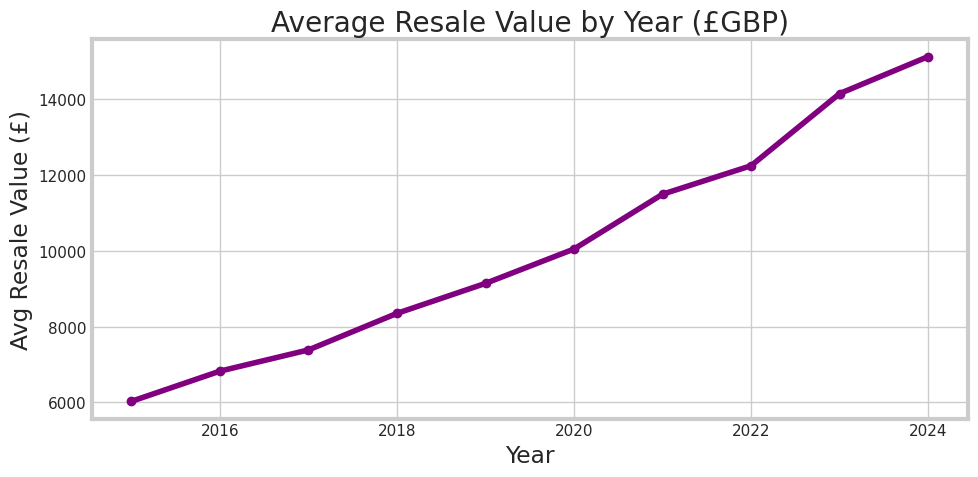

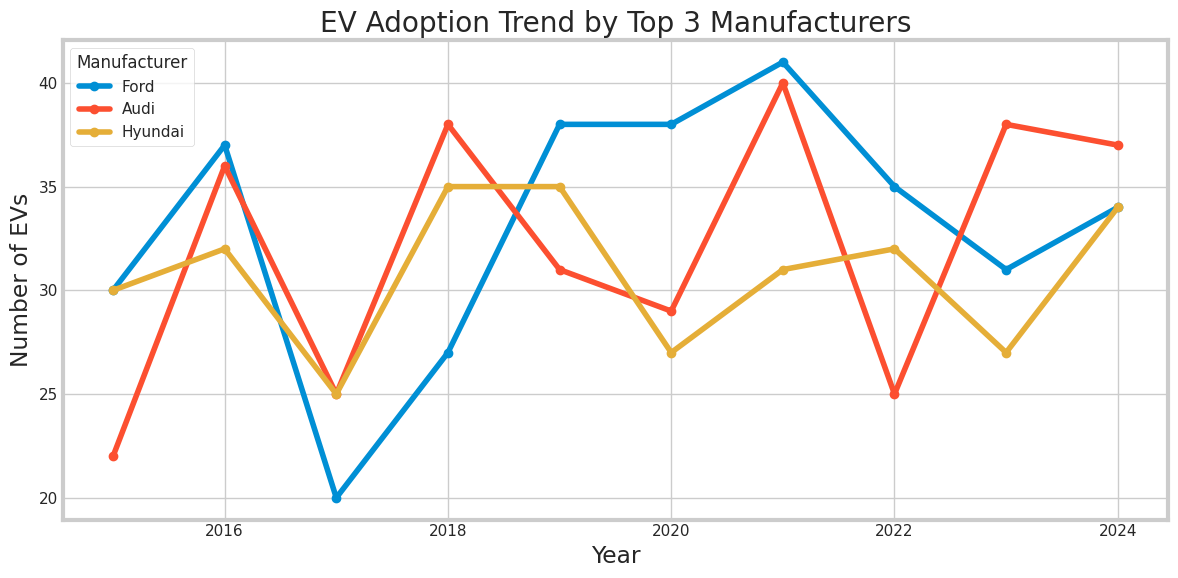

In [44]:
sns.set_style("whitegrid")

# 1. EV adoption trend by Year
year_counts = df['Year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(year_counts.index, year_counts.values, marker='o', color='blue')
ax.set_title('EV Adoption Trend by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of EVs')
plt.tight_layout(); plt.show()

# 2. Average Battery Capacity over Years
avg_battery = df.groupby('Year')['Battery_Capacity_kWh'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_battery.index, avg_battery.values, marker='o', color='teal')
ax.set_title('Average Battery Capacity by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Battery Capacity (kWh)')
plt.tight_layout(); plt.show()

# 3. Average Range over Years
avg_range = df.groupby('Year')['Range_km'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_range.index, avg_range.values, marker='o', color='green')
ax.set_title('Average EV Range by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Range (km)')
plt.tight_layout(); plt.show()

# 4. Average Charging Time over Years
avg_charging = df.groupby('Year')['Charging_Time_hr'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_charging.index, avg_charging.values, marker='o', color='orange')
ax.set_title('Average Charging Time by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Charging Time (hr)')
plt.tight_layout(); plt.show()

# 5. Average Resale Value (GBP) over Years
avg_resale = df.groupby('Year')['Resale_Value_GBP'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_resale.index, avg_resale.values, marker='o', color='purple')
ax.set_title('Average Resale Value by Year (£GBP)')
ax.set_xlabel('Year'); ax.set_ylabel('Avg Resale Value (£)')
plt.tight_layout(); plt.show()

# 6. Adoption Trend for Top 3 Manufacturers
top_makes = df['Make'].value_counts().nlargest(3).index
make_trends = df[df['Make'].isin(top_makes)].groupby(['Year','Make']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(12, 6))
for make in top_makes:
    subset = make_trends[make_trends['Make'] == make]
    ax.plot(subset['Year'], subset['Count'], marker='o', label=make)
ax.set_title('EV Adoption Trend by Top 3 Manufacturers')
ax.set_xlabel('Year'); ax.set_ylabel('Number of EVs')
ax.legend(title='Manufacturer')
plt.tight_layout(); plt.show()

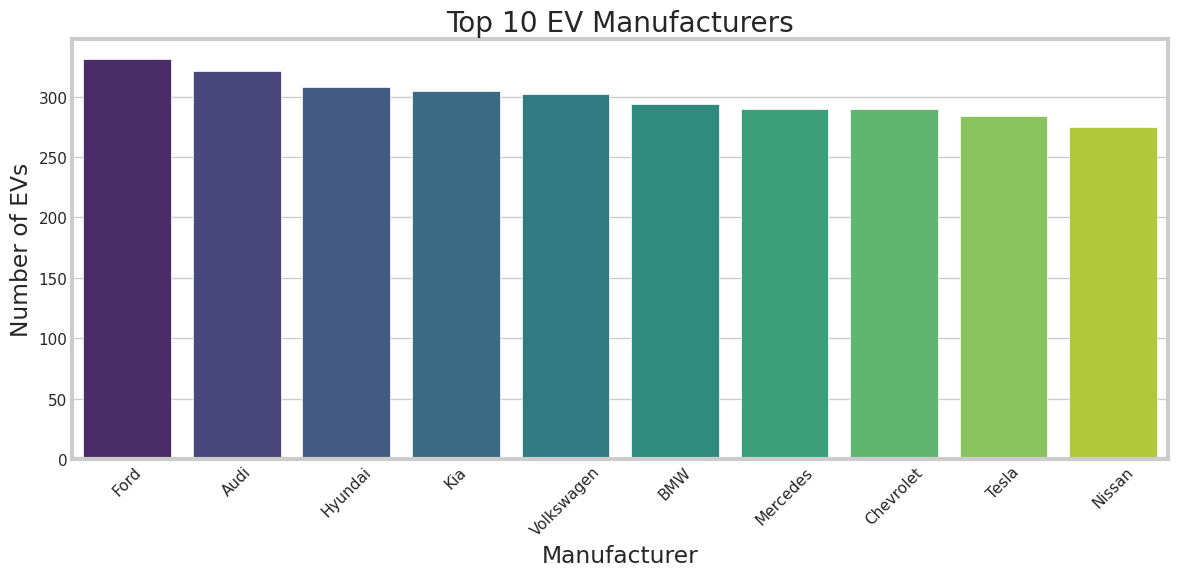

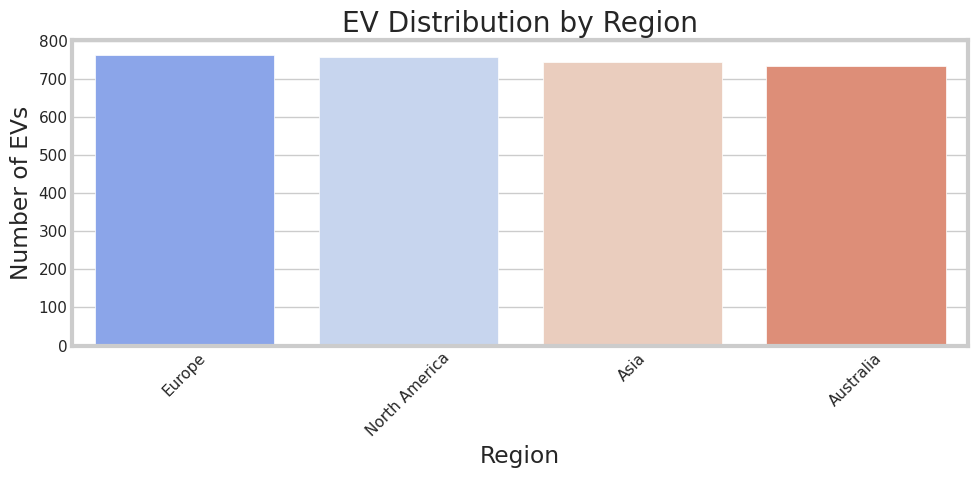

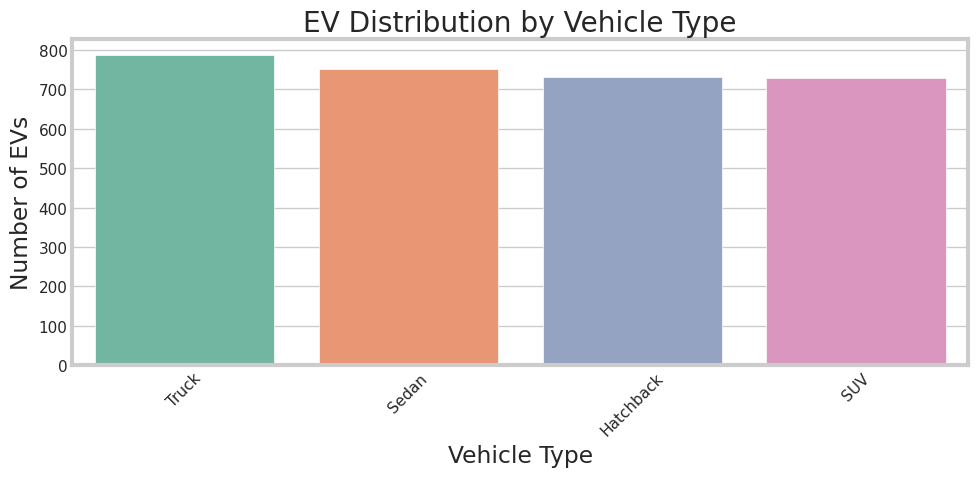

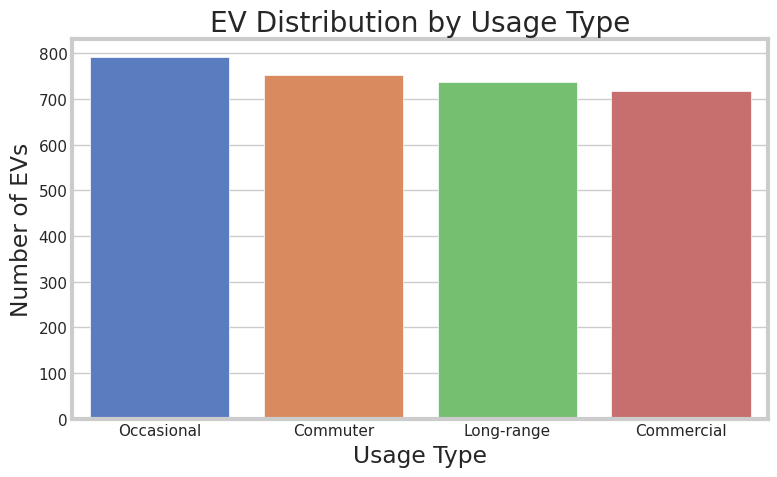

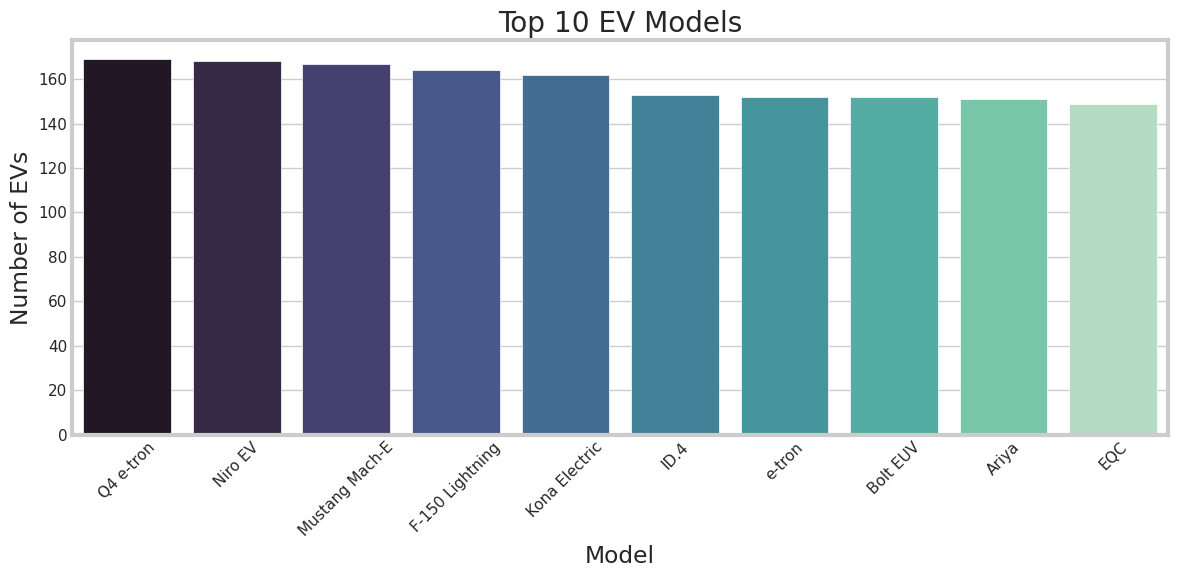

In [45]:
sns.set_style("whitegrid")

# 1. Top 10 EV Manufacturers
make_counts = df['Make'].value_counts().head(10).reset_index()
make_counts.columns = ['Make', 'Count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=make_counts, x='Make', y='Count', palette='viridis', ax=ax)
ax.set_title('Top 10 EV Manufacturers')
ax.set_xlabel('Manufacturer'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 2. EV Distribution by Region
region_counts = df['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=region_counts, x='Region', y='Count', palette='coolwarm', ax=ax)
ax.set_title('EV Distribution by Region')
ax.set_xlabel('Region'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 3. EV Distribution by Vehicle Type
vtype_counts = df['Vehicle_Type'].value_counts().reset_index()
vtype_counts.columns = ['Vehicle_Type', 'Count']
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=vtype_counts, x='Vehicle_Type', y='Count', palette='Set2', ax=ax)
ax.set_title('EV Distribution by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 4. EV Usage Type Distribution
usage_counts = df['Usage_Type'].value_counts().reset_index()
usage_counts.columns = ['Usage_Type', 'Count']
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=usage_counts, x='Usage_Type', y='Count', palette='muted', ax=ax)
ax.set_title('EV Distribution by Usage Type')
ax.set_xlabel('Usage Type'); ax.set_ylabel('Number of EVs')
plt.tight_layout(); plt.show()

# 5. Top 10 EV Models
model_counts = df['Model'].value_counts().head(10).reset_index()
model_counts.columns = ['Model', 'Count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=model_counts, x='Model', y='Count', palette='mako', ax=ax)
ax.set_title('Top 10 EV Models')
ax.set_xlabel('Model'); ax.set_ylabel('Number of EVs')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

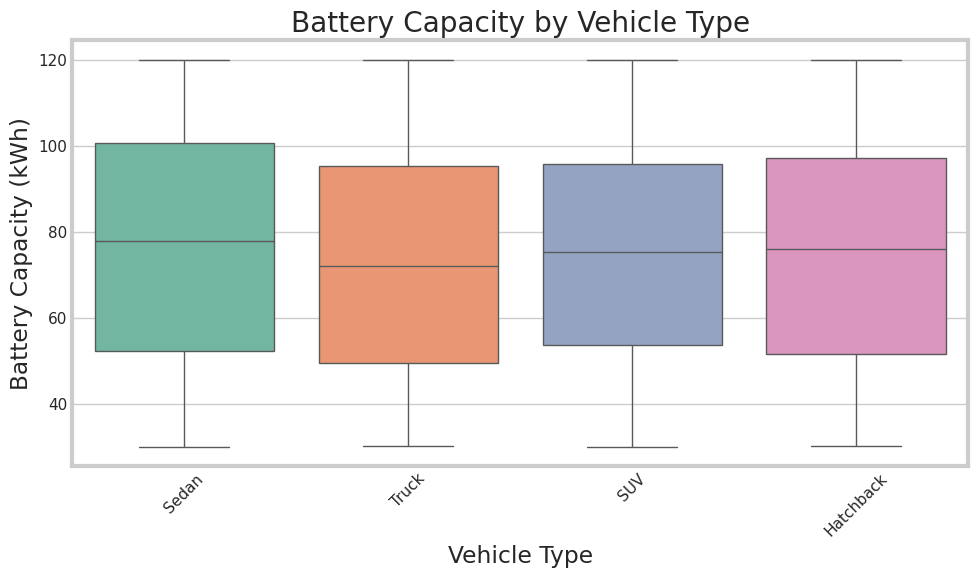

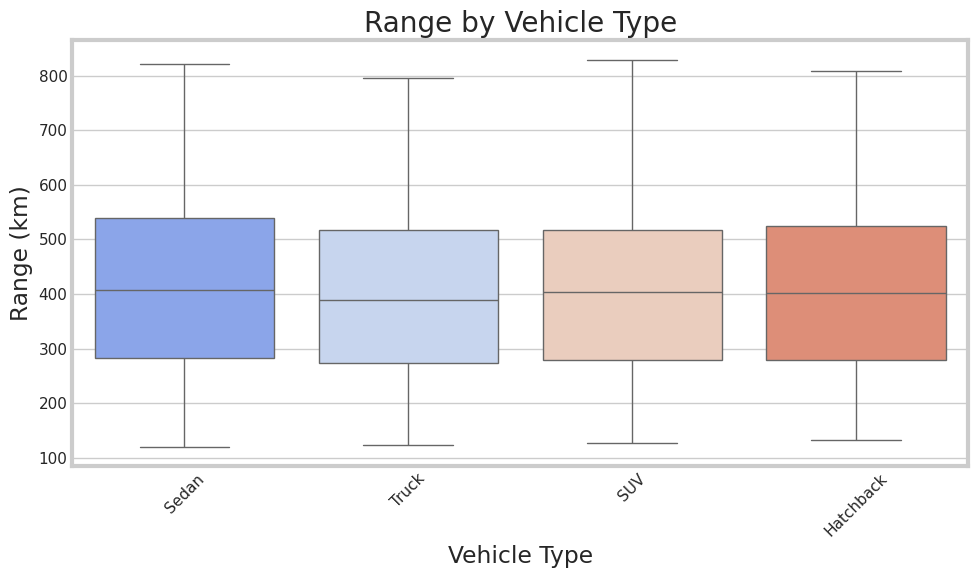

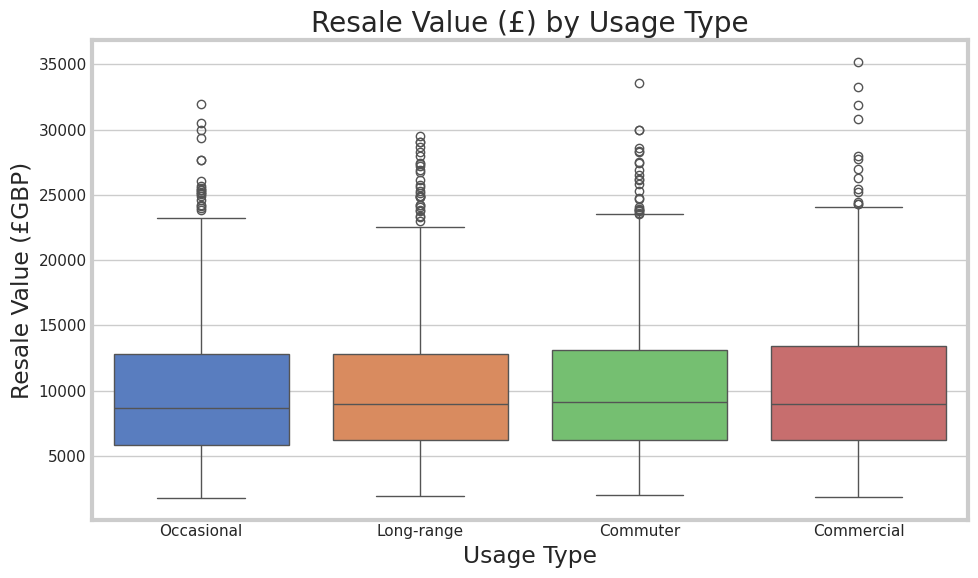

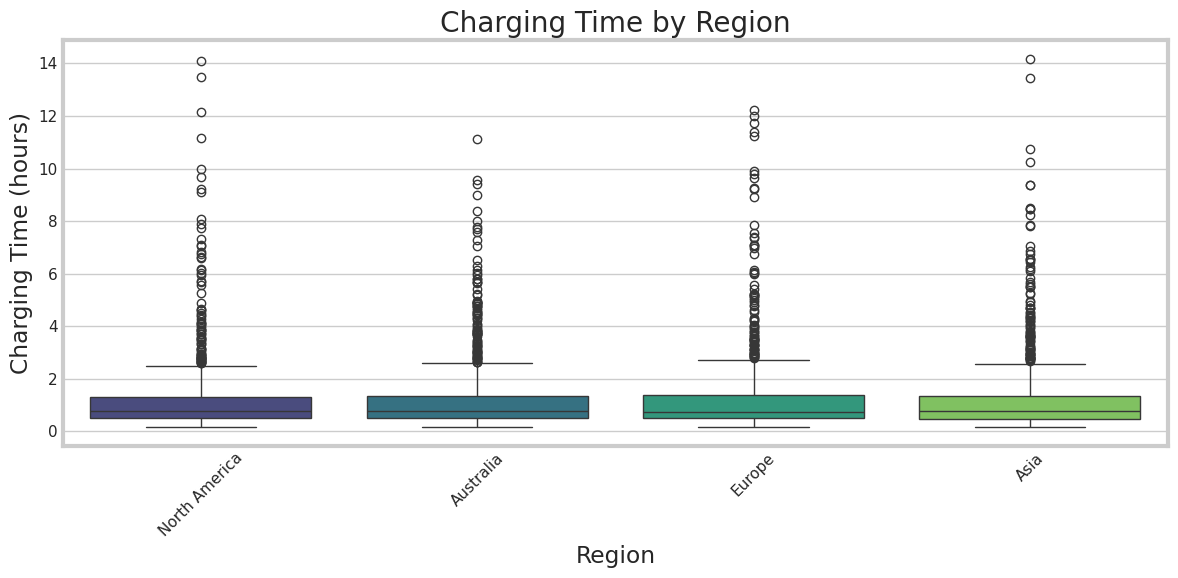

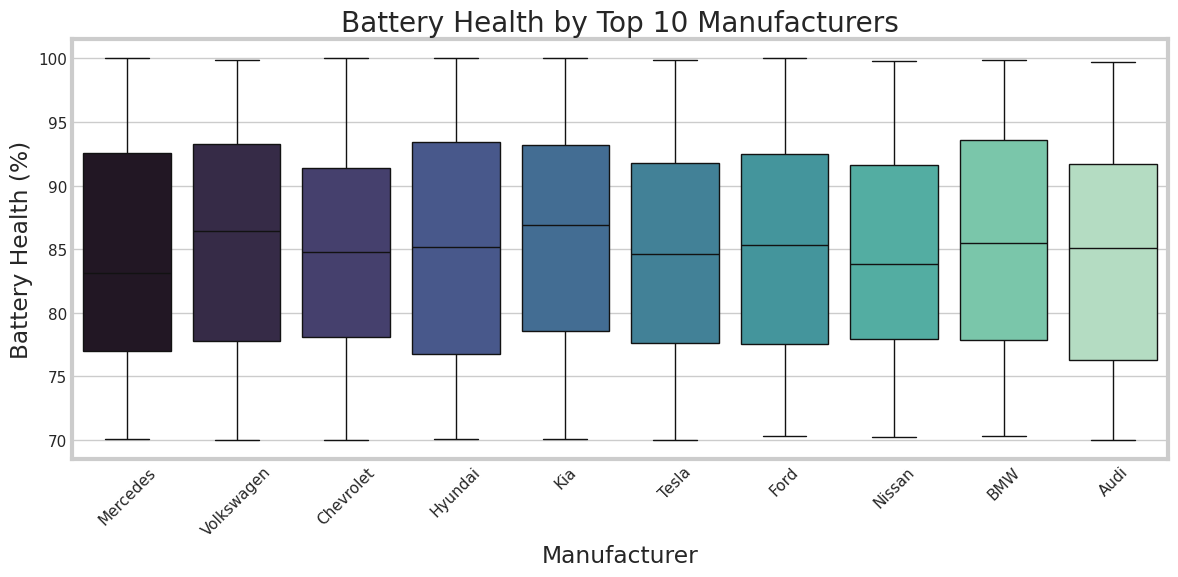

In [46]:
sns.set_style("whitegrid")

# 1. Battery Capacity by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Vehicle_Type', y='Battery_Capacity_kWh', palette='Set2', ax=ax)
ax.set_title('Battery Capacity by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Battery Capacity (kWh)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 2. Range by Vehicle Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Vehicle_Type', y='Range_km', palette='coolwarm', ax=ax)
ax.set_title('Range by Vehicle Type')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Range (km)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 3. Resale Value (GBP) by Usage Type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Usage_Type', y='Resale_Value_GBP', palette='muted', ax=ax)
ax.set_title('Resale Value (£) by Usage Type')
ax.set_xlabel('Usage Type'); ax.set_ylabel('Resale Value (£GBP)')
plt.tight_layout(); plt.show()

# 4. Charging Time by Region
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Charging_Time_hr', palette='viridis', ax=ax)
ax.set_title('Charging Time by Region')
ax.set_xlabel('Region'); ax.set_ylabel('Charging Time (hours)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 5. Battery Health by Top 10 Manufacturers
top_makes = df['Make'].value_counts().head(10).index
subset = df[df['Make'].isin(top_makes)]
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subset, x='Make', y='Battery_Health_%', palette='mako', ax=ax)
ax.set_title('Battery Health by Top 10 Manufacturers')
ax.set_xlabel('Manufacturer'); ax.set_ylabel('Battery Health (%)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

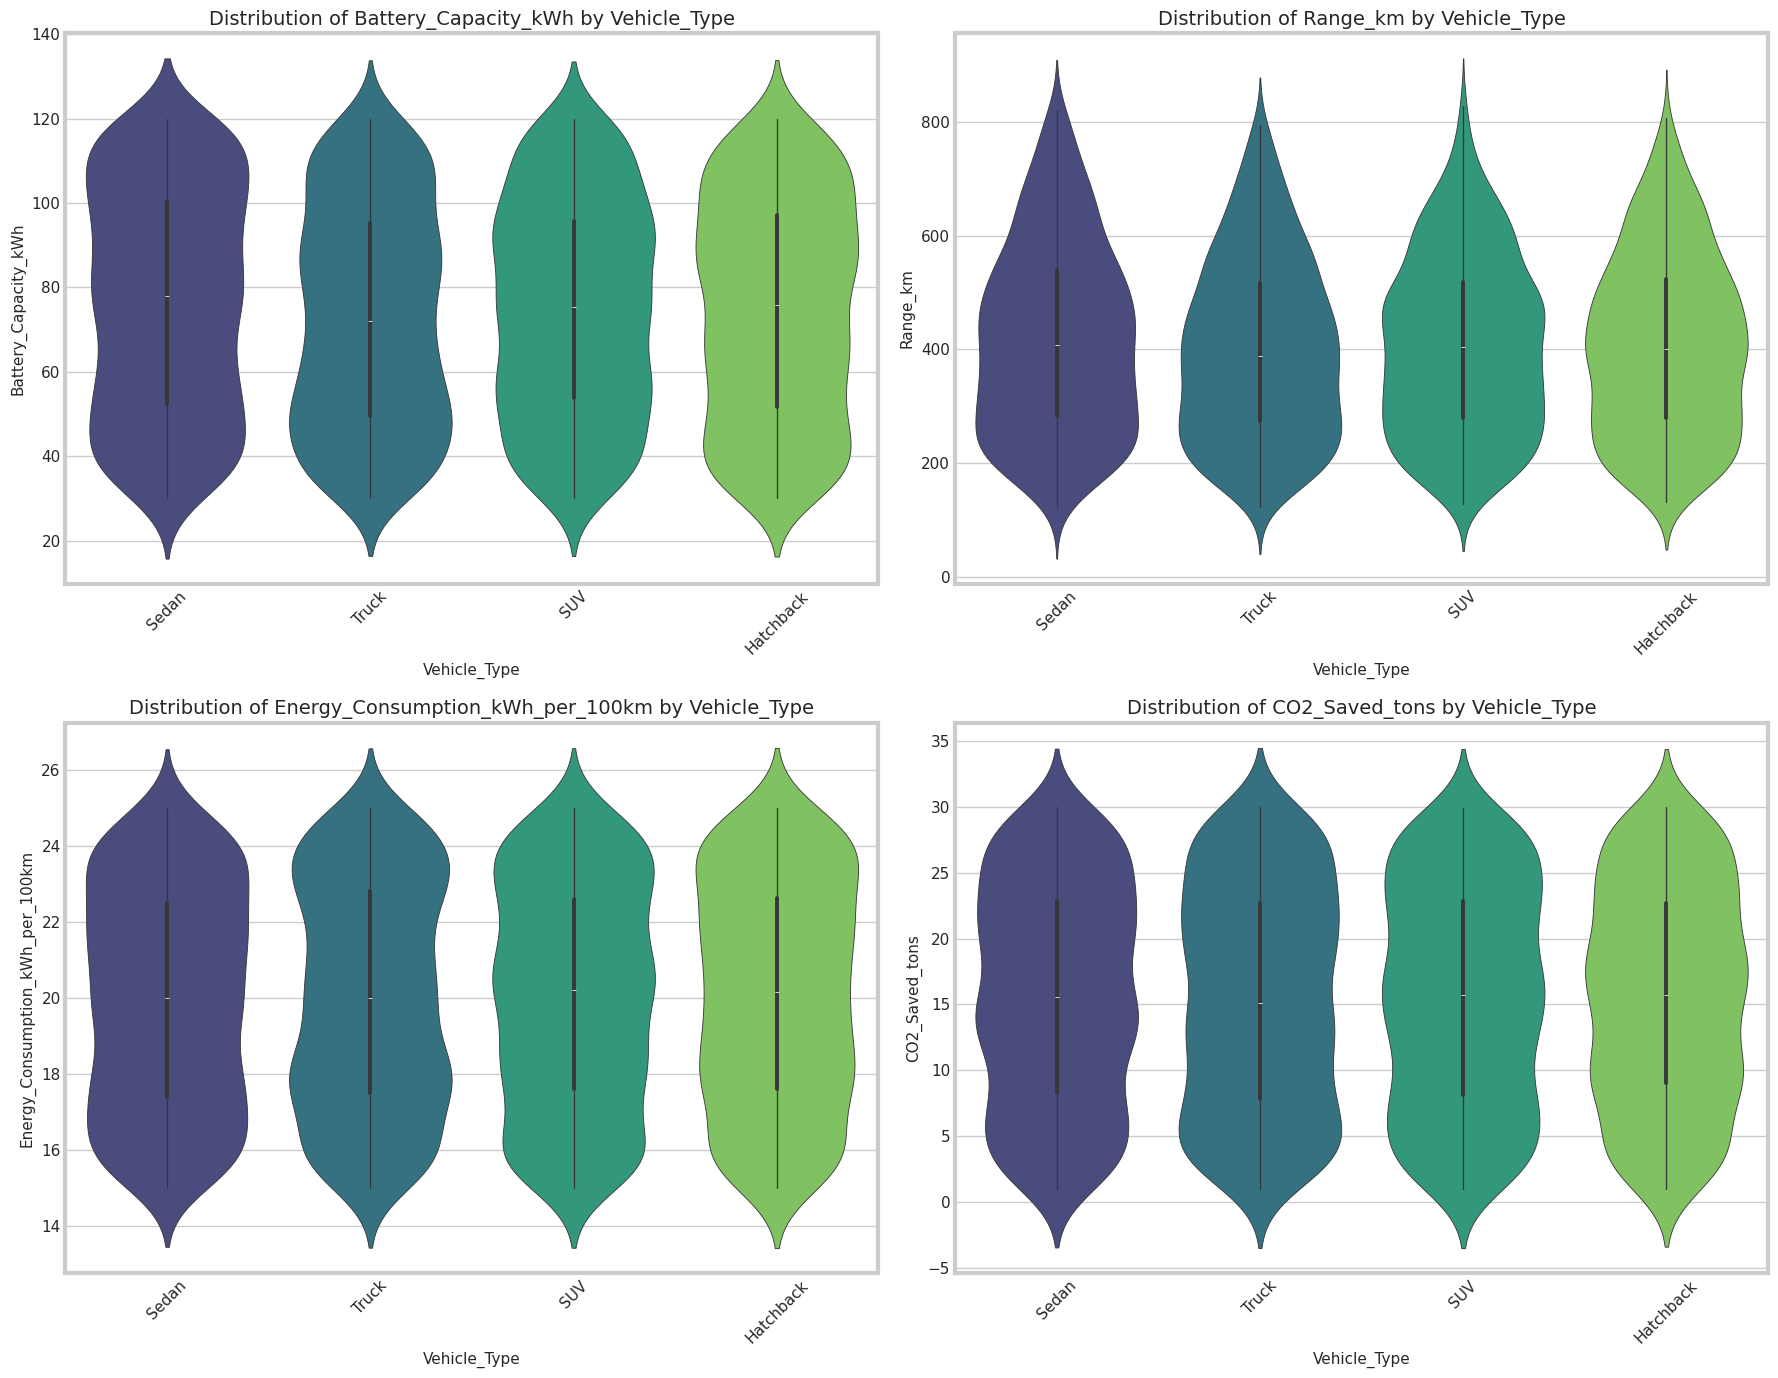

In [47]:
sns.set_style("whitegrid")

numeric_cols = ['Battery_Capacity_kWh', 'Range_km', 'Energy_Consumption_kWh_per_100km', 'CO2_Saved_tons']
categorical_col = 'Vehicle_Type'

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(
        data=df,
        x=categorical_col, y=col,
        ax=axes[i], palette='viridis',
        hue=categorical_col,   # required in newer seaborn to avoid warning
        legend=False
    )
    axes[i].set_title(f'Distribution of {col} by {categorical_col}', fontsize=14)
    axes[i].set_xlabel(categorical_col, fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

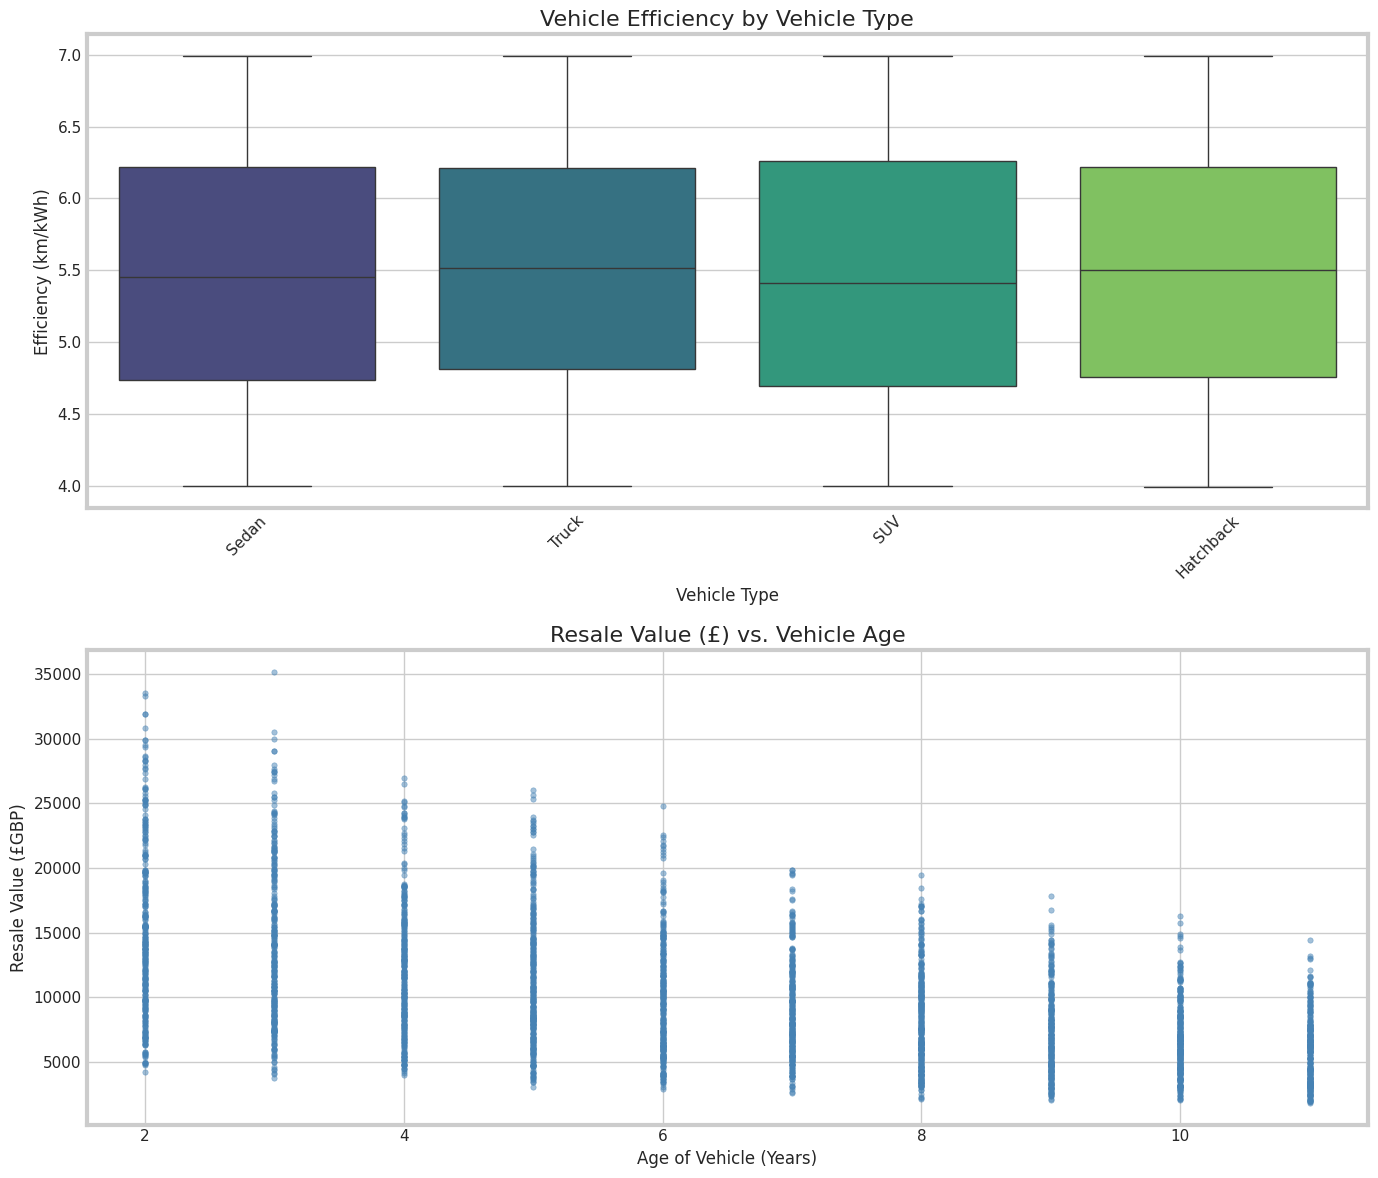

In [48]:
sns.set_style("whitegrid")

# Efficiency and Age are already computed in the preprocessing cell.
# Recompute safely in case this cell runs in isolation.
current_year = 2026
if 'Vehicle_Age' not in df.columns:
    df['Vehicle_Age'] = current_year - df['Year']
if 'Efficiency_km_per_kWh' not in df.columns:
    df['Efficiency_km_per_kWh'] = (df['Range_km'] / df['Battery_Capacity_kWh']).replace([np.inf, -np.inf], 0).fillna(0)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Plot 1: Vehicle Efficiency by Type
sns.boxplot(data=df, x='Vehicle_Type', y='Efficiency_km_per_kWh', ax=axes[0], palette='viridis')
axes[0].set_title('Vehicle Efficiency by Vehicle Type', fontsize=16)
axes[0].set_xlabel('Vehicle Type', fontsize=12)
axes[0].set_ylabel('Efficiency (km/kWh)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Resale Value (GBP) vs Vehicle Age
axes[1].scatter(df['Vehicle_Age'], df['Resale_Value_GBP'], alpha=0.5, color='steelblue', s=15)
axes[1].set_title('Resale Value (£) vs. Vehicle Age', fontsize=16)
axes[1].set_xlabel('Age of Vehicle (Years)', fontsize=12)
axes[1].set_ylabel('Resale Value (£GBP)', fontsize=12)

plt.tight_layout()
plt.show()

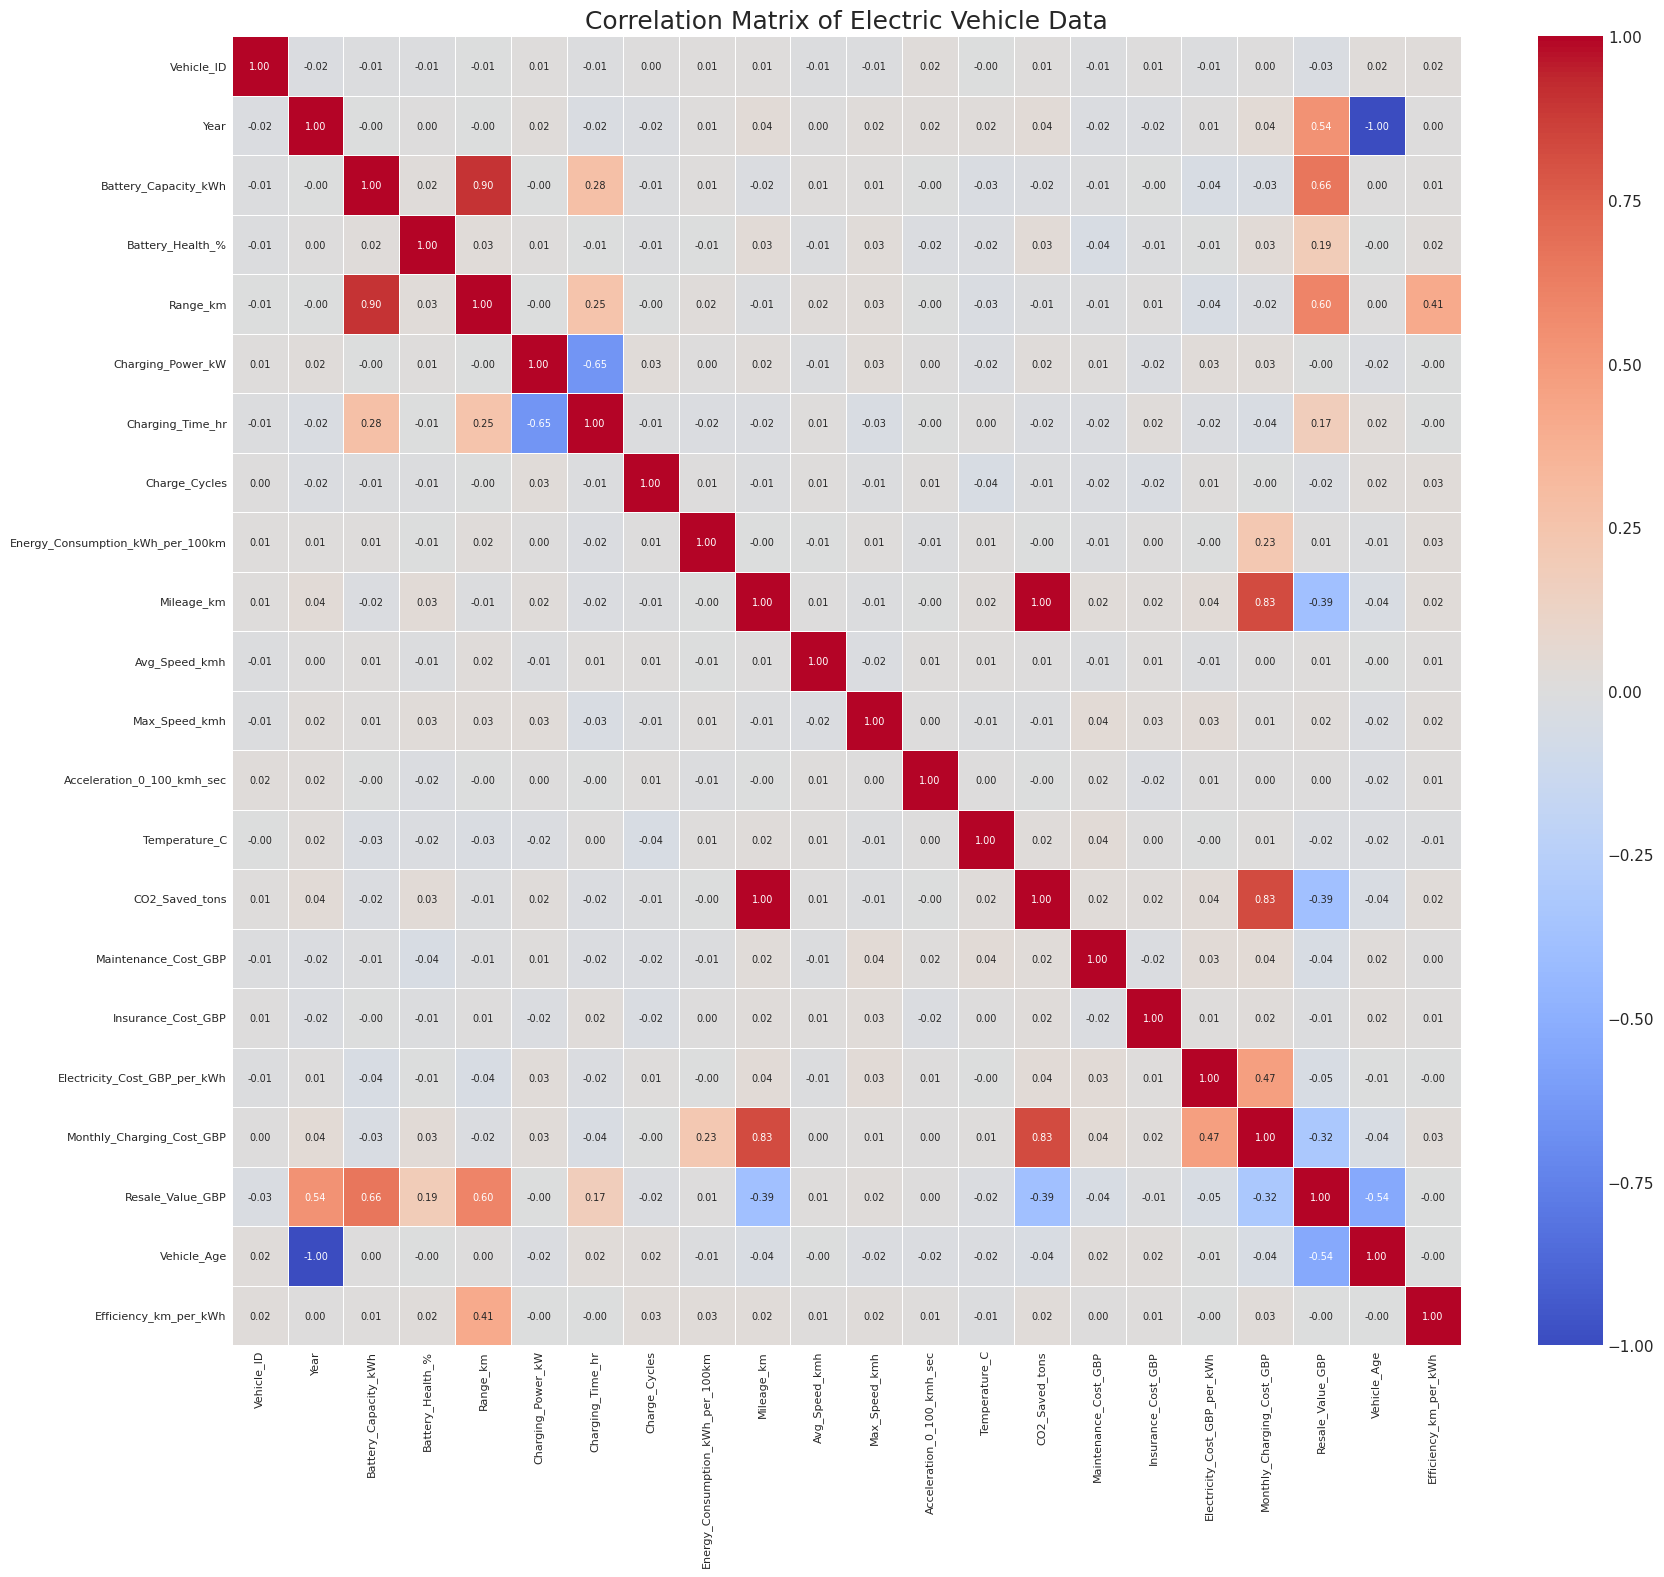

In [49]:
numerical_df = df.select_dtypes(include='number')
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(18, 16))
sns.heatmap(
    correlation_matrix,
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Matrix of Electric Vehicle Data', fontsize=18)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

 Linear Regression 
MAE: £1466.09  |  MSE: 3907347.13  |  R²: 0.8716

 Random Forest Regressor 
MAE: £1015.49  |  MSE: 1951510.57  |  R²: 0.9359

 XGBoost Regressor 
MAE: £967.30  |  MSE: 1658188.66  |  R²: 0.9455

 Model Comparison 
            Model  R-squared     MAE (£)
          XGBoost   0.945525  967.296575
    Random Forest   0.935888 1015.493108
Linear Regression   0.871635 1466.086407


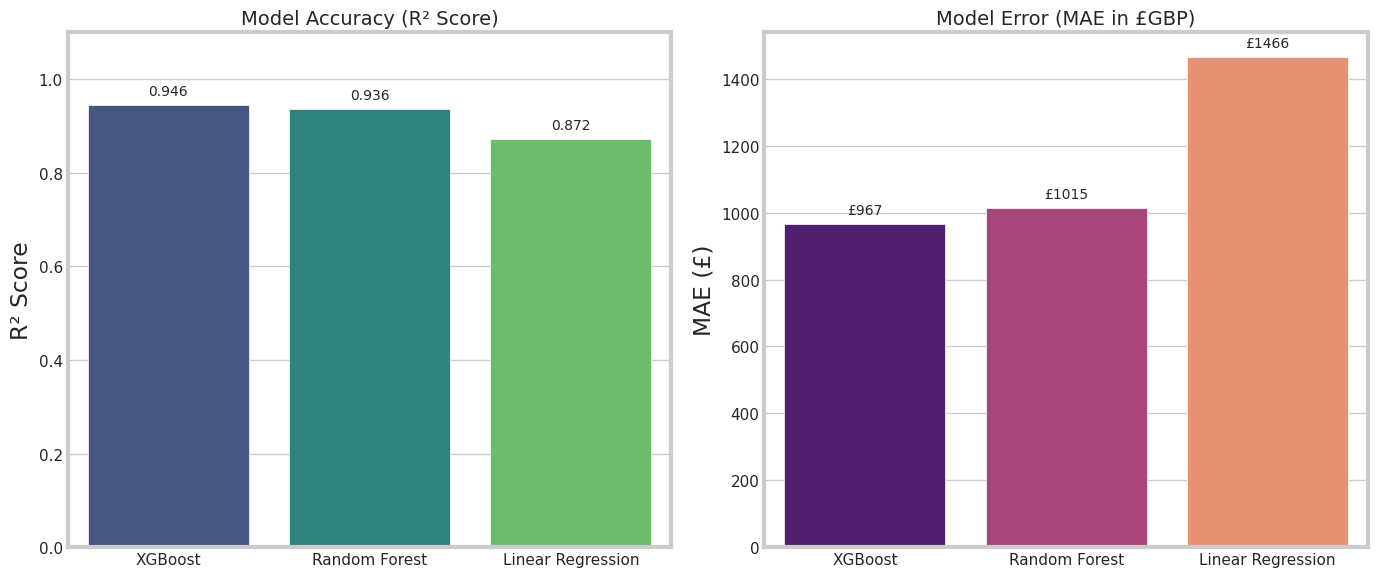

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#  Prepare data
df_ml = df.copy()

# Fill any remaining NaN
numerical_cols_ml = df_ml.select_dtypes(include='number').columns
df_ml[numerical_cols_ml] = df_ml[numerical_cols_ml].fillna(df_ml[numerical_cols_ml].mean())

# Feature Engineering
current_year = 2026
df_ml['Age'] = current_year - df_ml['Year']

# One-hot encode Vehicle_Type
df_ml = pd.get_dummies(df_ml, columns=['Vehicle_Type'], drop_first=True)
categorical_features = [col for col in df_ml.columns if 'Vehicle_Type_' in col]

base_features = ['Mileage_km', 'Battery_Capacity_kWh', 'Charge_Cycles',
                 'Energy_Consumption_kWh_per_100km', 'Age', 'CO2_Saved_tons']
features = base_features + categorical_features
target   = 'Resale_Value_GBP'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Model 1: Linear Regression
print(" Linear Regression ")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
mae_lr  = mean_absolute_error(y_test, lr_pred)
mse_lr  = mean_squared_error(y_test, lr_pred)
r2_lr   = r2_score(y_test, lr_pred)
print(f"MAE: £{mae_lr:.2f}  |  MSE: {mse_lr:.2f}  |  R²: {r2_lr:.4f}")

#  Model 2: Random Forest
print("\n Random Forest Regressor ")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
mae_rf  = mean_absolute_error(y_test, rf_pred)
mse_rf  = mean_squared_error(y_test, rf_pred)
r2_rf   = r2_score(y_test, rf_pred)
print(f"MAE: £{mae_rf:.2f}  |  MSE: {mse_rf:.2f}  |  R²: {r2_rf:.4f}")

#  Model 3: XGBoost
print("\n XGBoost Regressor ")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred  = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
mse_xgb  = mean_squared_error(y_test, xgb_pred)
r2_xgb   = r2_score(y_test, xgb_pred)
print(f"MAE: £{mae_xgb:.2f}  |  MSE: {mse_xgb:.2f}  |  R²: {r2_xgb:.4f}")

#  Model Comparison Plot ─
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R-squared': [r2_lr, r2_rf, r2_xgb],
    'MAE (£)': [mae_lr, mae_rf, mae_xgb]
}).sort_values('R-squared', ascending=False)

print("\n Model Comparison ")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
bars = sns.barplot(data=comparison_df, x='Model', y='R-squared', palette='viridis', ax=axes[0])
for p in bars.patches:
    bars.annotate(f'{p.get_height():.3f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)
axes[0].set_title('Model Accuracy (R² Score)', fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel(''); axes[0].set_ylabel('R² Score')

# MAE comparison
bars2 = sns.barplot(data=comparison_df, x='Model', y='MAE (£)', palette='magma', ax=axes[1])
for p in bars2.patches:
    bars2.annotate(f'£{p.get_height():.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)
axes[1].set_title('Model Error (MAE in £GBP)', fontsize=14)
axes[1].set_xlabel(''); axes[1].set_ylabel('MAE (£)')

plt.tight_layout()
plt.show()

 K-Means Clustering 
Cluster distribution:
Cluster_ID
0    723
1    791
2    811
3    675
Name: count, dtype: int64

 Principal Component Analysis (PCA) 
Explained variance ratio: PC1=0.216, PC2=0.153

 Isolation Forest (Anomaly Detection) 
Anomalies detected: 150 out of 3000 records (5.0%)


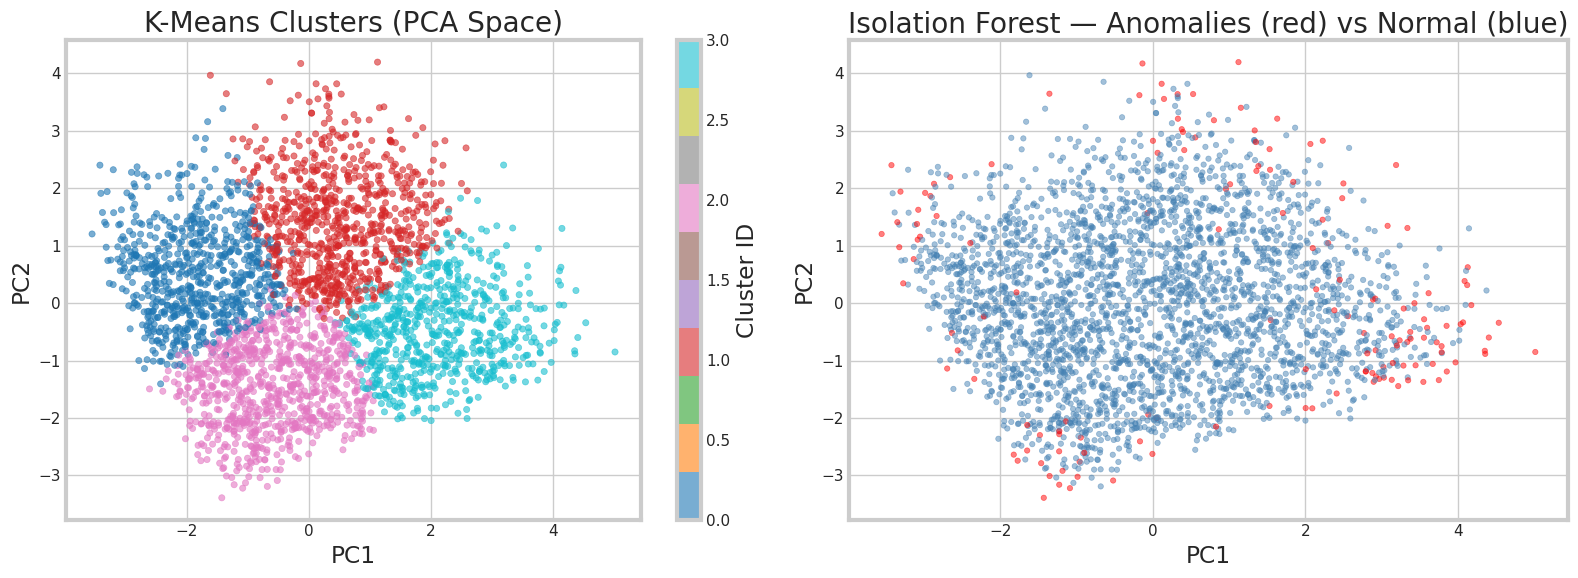


Sample output:
   Cluster_ID       PC1       PC2  Is_Anomaly  Anomaly_Score
0           2 -0.520980 -3.090252          -1      -0.024228
1           3  3.791081 -0.872022           1       0.012087
2           3  2.195582 -1.226062           1       0.021424
3           1 -0.247934  1.761109           1       0.043034
4           1 -0.671900  2.502762           1       0.079895


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Reload clean copy without one-hot encoding from ML cell
df_unsup = df.copy()

numerical_cols_u = [
    'Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
    'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
    'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh',
    'Acceleration_0_100_kmh_sec', 'Temperature_C',
    'Monthly_Charging_Cost_GBP', 'Resale_Value_GBP'
]
# Keep only columns that exist
numerical_cols_u = [c for c in numerical_cols_u if c in df_unsup.columns]

data_for_unsupervised = df_unsup[numerical_cols_u].copy()
data_for_unsupervised.fillna(data_for_unsupervised.mean(), inplace=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_unsupervised)

# 1. K-Means Clustering
print(" K-Means Clustering ")
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_unsup['Cluster_ID'] = kmeans.fit_predict(scaled_data)
print(f"Cluster distribution:\n{df_unsup['Cluster_ID'].value_counts().sort_index()}")

# 2. PCA
print("\n Principal Component Analysis (PCA) ")
pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled_data)
df_unsup['PC1'] = pcs[:, 0]
df_unsup['PC2'] = pcs[:, 1]
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

# 3. Isolation Forest
print("\n Isolation Forest (Anomaly Detection) ")
iso_forest = IsolationForest(random_state=42, contamination=0.05)
df_unsup['Is_Anomaly']    = iso_forest.fit_predict(scaled_data)
df_unsup['Anomaly_Score'] = iso_forest.decision_function(scaled_data)
anomaly_count = (df_unsup['Is_Anomaly'] == -1).sum()
print(f"Anomalies detected: {anomaly_count} out of {len(df_unsup)} records ({anomaly_count/len(df_unsup)*100:.1f}%)")

#  Visualise clusters via PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster plot
scatter = axes[0].scatter(df_unsup['PC1'], df_unsup['PC2'],
                          c=df_unsup['Cluster_ID'], cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('K-Means Clusters (PCA Space)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster ID')

# Anomaly plot
colors = df_unsup['Is_Anomaly'].map({1: 'steelblue', -1: 'red'})
axes[1].scatter(df_unsup['PC1'], df_unsup['PC2'], c=colors, alpha=0.5, s=15)
axes[1].set_title('Isolation Forest — Anomalies (red) vs Normal (blue)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

print("\nSample output:")
print(df_unsup[['Cluster_ID', 'PC1', 'PC2', 'Is_Anomaly', 'Anomaly_Score']].head())

TensorFlow version: 2.20.0


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)


Training stopped at epoch 61
Final Training Loss: 10641283.00
Final Validation Loss: 11836256.00
Test MAE: £2703.24  |  Test R²: 0.6156


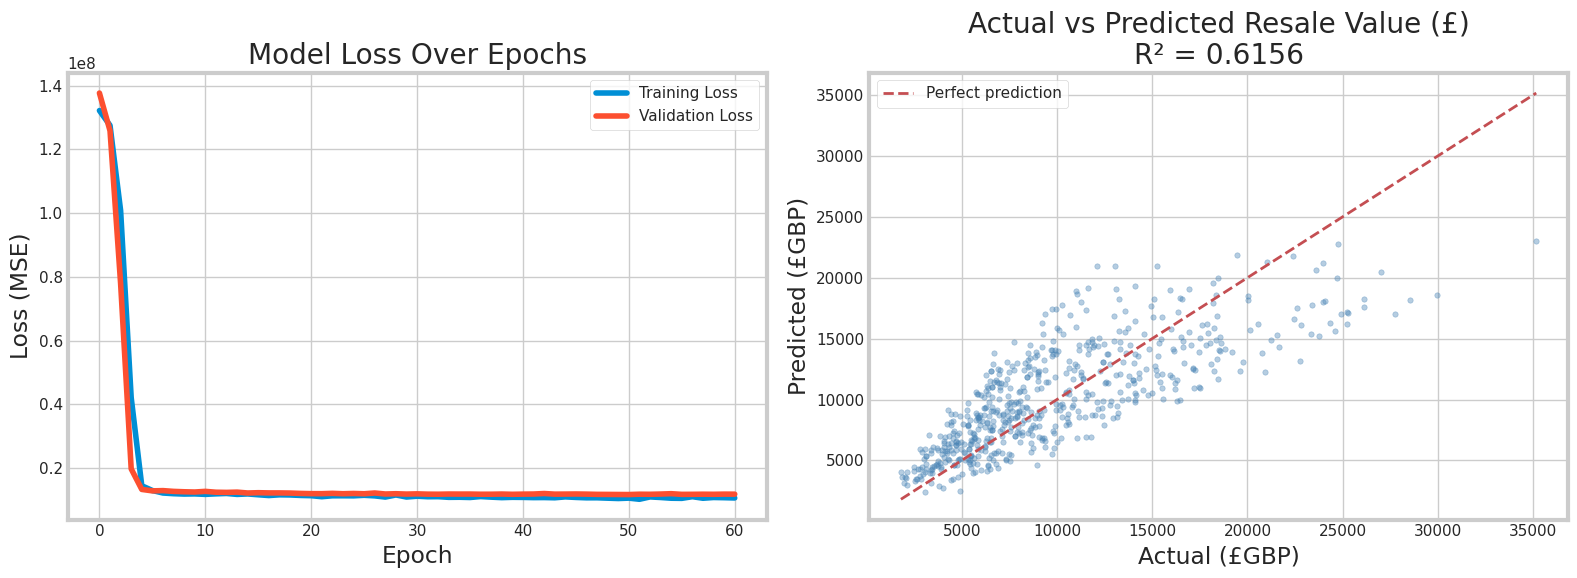

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print(f"TensorFlow version: {tf.__version__}")

#  Prepare features ─
df_nn = df.copy()
df_nn = pd.get_dummies(df_nn, columns=['Region', 'Vehicle_Type', 'Usage_Type'])

feature_base = ['Battery_Capacity_kWh', 'Battery_Health_%', 'Range_km',
                'Charging_Power_kW', 'Energy_Consumption_kWh_per_100km',
                'Mileage_km', 'Avg_Speed_kmh', 'Acceleration_0_100_kmh_sec']
categorical_nn = [c for c in df_nn.columns if c.startswith(('Region_', 'Vehicle_Type_', 'Usage_Type_'))]
feature_cols   = feature_base + categorical_nn
target_col     = 'Resale_Value_GBP'

X = df_nn[feature_cols].fillna(df_nn[feature_cols].mean())
y = df_nn[target_col].fillna(df_nn[target_col].mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#  Build Neural Network ─
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)   # regression output
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Final Training Loss: {history.history['loss'][-1]:.2f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.2f}")

#  Evaluate
y_pred_nn = model.predict(X_test_s, verbose=0).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn  = r2_score(y_test, y_pred_nn)
print(f"Test MAE: £{mae_nn:.2f}  |  Test R²: {r2_nn:.4f}")

#  Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss curve
axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(); axes[0].grid(True)

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_nn, alpha=0.4, s=15, color='steelblue')
min_val = min(y_test.min(), y_pred_nn.min())
max_val = max(y_test.max(), y_pred_nn.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[1].set_title(f'Actual vs Predicted Resale Value (£)\nR² = {r2_nn:.4f}')
axes[1].set_xlabel('Actual (£GBP)'); axes[1].set_ylabel('Predicted (£GBP)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
print("CONCLUSION")
print("""
All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation
""")

CONCLUSION

All models were trained to predict EV Resale Value in GBP (£).

Key Findings:
  • Linear Regression provides a simple baseline.
  • Random Forest and XGBoost generally outperform linear models
    due to their ability to capture non-linear relationships.
  • Neural Network adds further capacity but requires more data
    and tuning to outperform tree-based ensembles.
  • Currency: All monetary values are in GBP (£), converted from
    USD at a rate of approximately 1 USD = £0.787 (May 2026).

Real-World Applications:
  • Used EV pricing / trade-in valuation
  • Battery lifecycle and warranty planning
  • Insurance and loan risk assessment
  • Consumer guidance on depreciation



In [54]:
# Export notebook to HTML (run after saving the notebook)
# In Colab: File → Download → Download .ipynb first, then run locally, or:
try:
    import subprocess
    result = subprocess.run(
        ['jupyter', 'nbconvert', '--to', 'html', __file__],
        capture_output=True, text=True
    )
    print(result.stdout or "Conversion attempted. Check for .html output file.")
except Exception as e:
    print(f"Note: To convert to HTML, run in terminal:")
    print(f"  jupyter nbconvert --to html Hemlal_Dulal_dissertation_codebase.ipynb")

Note: To convert to HTML, run in terminal:
  jupyter nbconvert --to html Hemlal_Dulal_dissertation_codebase.ipynb
